# Deep Learning-Based Video Engagement and Drop-off Prediction System

**Course:** Deep Learning

**Semester:** 6th

**Academic Year:** 2025–26

---

## Team Members
| Name | PRN |
|------|-----|
| Parimal Ahire | 202301040067 |
| Atharva Suryawanshi | 202301040283 |
| Rajveersinh Kher | 202301040233 |
| Mohit Patil | 202301040272 |

**Guide:** Dr. Sunita Barve  
**Industry Partner:** BeMotion

---

### Three-Branch
| Branch | Feature Extractor | Input | Trainable |
|--------|------------------|-------|-----------|
| A | ResNet50 (ImageNet pretrained) | 4096-dim cached features | BiLSTM+Transformer only |
| B | CLIP ViT-B/32 (OpenAI pretrained) | 1024-dim cached features | BiLSTM+Transformer only |
| C | Custom CNN from scratch | Raw frames — end-to-end | CNN + BiLSTM+Transformer jointly |

## Step 1: Environment Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow opencv-python-headless tqdm matplotlib scikit-learn scipy -q
!pip install git+https://github.com/openai/CLIP.git -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00


## Step 2: Import Libraries

In [ ]:
import os, gc, cv2, clip, torch, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm
from PIL import Image

# Mixed precision — ~2x speed/memory on L4, still beneficial on T4
# FIX 7: set policy explicitly here so this cell is self-contained
mixed_precision.set_global_policy('mixed_float16')
print(f"Mixed precision policy: {mixed_precision.global_policy().name}")

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow device : {'GPU' if gpus else 'CPU'}")
torch_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch device    : {torch_device}")

Mixed precision policy: mixed_float16
TensorFlow device : GPU
PyTorch device    : cuda


## Step 3: Path Configuration

In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/VideoInsight'
LOCAL_BASE = '/content/VideoInsight_local'

# ── Drive paths (persistent across sessions) ──────────────────────────────
# Extraction steps WRITE here so work is never lost on disconnect
VIDEO_PATH      = os.path.join(DRIVE_PATH, 'videos')
ANNO_PATH       = os.path.join(DRIVE_PATH, 'ydata-tvsum50-anno.tsv')
INFO_PATH       = os.path.join(DRIVE_PATH, 'ydata-tvsum50-info.tsv')
FRAMES_DIR      = os.path.join(DRIVE_PATH, 'frames')
FEATURES_RESNET = os.path.join(DRIVE_PATH, 'features_resnet')
FEATURES_CLIP   = os.path.join(DRIVE_PATH, 'features_clip')
MODELS_DIR      = os.path.join(DRIVE_PATH, 'models')

# ── Local SSD paths (fast I/O, used during training each session) ─────────
# Training reads from here to avoid Drive quota errors during the hot loop
LOCAL_FRAMES          = os.path.join(LOCAL_BASE, 'frames')
LOCAL_FEATURES_RESNET = os.path.join(LOCAL_BASE, 'features_resnet')
LOCAL_FEATURES_CLIP   = os.path.join(LOCAL_BASE, 'features_clip')
LOCAL_MODELS_DIR      = os.path.join(LOCAL_BASE, 'models')
PLOTS_DIR             = os.path.join(LOCAL_BASE, 'plots')
INFERENCE_DIR         = os.path.join(LOCAL_BASE, 'inference_results')

for d in [LOCAL_BASE, LOCAL_FRAMES, LOCAL_FEATURES_RESNET,
          LOCAL_FEATURES_CLIP, LOCAL_MODELS_DIR, PLOTS_DIR, INFERENCE_DIR]:
    os.makedirs(d, exist_ok=True)

# Drive output dirs (for persistence)
for d in [FRAMES_DIR, FEATURES_RESNET, FEATURES_CLIP, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Checking Drive source paths:")
for label, path in [('Videos', VIDEO_PATH), ('Anno', ANNO_PATH), ('Info', INFO_PATH)]:
    print(f"  {label}: {'OK' if os.path.exists(path) else 'MISSING'} — {path}")

videos = [f for f in os.listdir(VIDEO_PATH) if f.endswith('.mp4')]
print(f"\nVideos found on Drive: {len(videos)}/50")

Checking Drive source paths:
  Videos: OK — /content/drive/MyDrive/VideoInsight/videos
  Anno: OK — /content/drive/MyDrive/VideoInsight/ydata-tvsum50-anno.tsv
  Info: OK — /content/drive/MyDrive/VideoInsight/ydata-tvsum50-info.tsv

Videos found on Drive: 50/50


## Step 3B: Session Cache Setup — Drive → Local SSD

Run once per session. Copies already-extracted frames and features from Drive
to local SSD so training reads are fast and never hit Drive quota limits.
Extraction steps (5, 6A, 6B) still write to Drive for persistence.

In [ ]:
import shutil

print("=" * 60)
print("Setting up local SSD cache for this session")
print("=" * 60)

for dir_name, drive_dir, local_dir in [
    ('frames',          FRAMES_DIR,      LOCAL_FRAMES),
    ('features_resnet', FEATURES_RESNET, LOCAL_FEATURES_RESNET),
    ('features_clip',   FEATURES_CLIP,   LOCAL_FEATURES_CLIP),
]:
    if os.path.exists(drive_dir) and len(os.listdir(drive_dir)) > 0:
        local_count = len(os.listdir(local_dir)) if os.path.exists(local_dir) else 0
        drive_count = len(os.listdir(drive_dir))
        if local_count < drive_count:
            print(f"\nCopying {dir_name} from Drive → local SSD "
                  f"({drive_count} items)...")
            shutil.copytree(drive_dir, local_dir, dirs_exist_ok=True)
            print(f"  Done.")
        else:
            print(f"  {dir_name} already cached locally ({local_count} items), skipping.")
    else:
        print(f"  {dir_name} not on Drive yet — will be extracted in Step 5/6.")

print("\n" + "=" * 60)
print("Local SSD ready.")
print("  Extraction will still write to Drive (persistent).")
print("  Training will read from local SSD (fast).")
print("=" * 60)

Setting up local SSD cache for this session

Copying frames from Drive → local SSD (50 items)...
  Done.

Copying features_resnet from Drive → local SSD (50 items)...
  Done.

Copying features_clip from Drive → local SSD (50 items)...
  Done.

Local SSD ready.
  Extraction will still write to Drive (persistent).
  Training will read from local SSD (fast).


## Step 4: Data Loading and Label Processing

- **Gaussian smoothing** replaces moving average — more natural, preserves transitions better
- **Annotator weighting** — down-weights annotators who consistently disagree with the group

In [ ]:
anno_df = pd.read_csv(ANNO_PATH, sep='\t', header=None,
                      names=['video_id', 'category', 'scores'])
info_df = pd.read_csv(INFO_PATH, sep='\t', header=0)
print(f"Annotations : {anno_df.shape}")
print(f"Info        : {info_df.shape}")
print(f"Categories  : {sorted(info_df['category'].unique())}")

Annotations : (1000, 3)
Info        : (50, 5)
Categories  : ['BK', 'BT', 'DS', 'FM', 'GA', 'MS', 'PK', 'PR', 'VT', 'VU']


### Gaussian Label Smoothing

In [ ]:
def smooth_labels_gaussian(scores: np.ndarray, sigma: float = 3.0) -> np.ndarray:
    smoothed = gaussian_filter1d(scores.astype(np.float64), sigma=sigma)
    mn, mx = smoothed.min(), smoothed.max()
    if mx > mn:
        return (smoothed - mn) / (mx - mn)
    return np.zeros_like(smoothed)

### Annotator Weighting

In [ ]:
def compute_annotator_weights(all_scores: list) -> np.ndarray:
    scores_arr = np.array(all_scores, dtype=np.float64)
    group_mean = scores_arr.mean(axis=0)
    maes       = np.mean(np.abs(scores_arr - group_mean), axis=1)
    weights    = 1.0 / (maes + 1e-6)
    return weights / weights.sum()

### Processing Engagement Scores

In [ ]:
SMOOTH_SIGMA = 3.0
video_scores = {}

for video_id, group in anno_df.groupby('video_id'):
    all_scores = []
    for _, row in group.iterrows():
        scores = list(map(int, str(row['scores']).strip().split(',')))
        all_scores.append(np.array(scores, dtype=np.float64))

    weights      = compute_annotator_weights(all_scores)
    weighted_avg = np.average(np.array(all_scores), axis=0, weights=weights)
    norm_scores  = smooth_labels_gaussian(weighted_avg, sigma=SMOOTH_SIGMA)
    video_scores[video_id] = {'gtscore': norm_scores, 'dropoff': 1 - norm_scores}

print(f"Processed labels for {len(video_scores)} videos")
lengths = [len(v['gtscore']) for v in video_scores.values()]
print(f"Frame-level scores — Min:{min(lengths)} Max:{max(lengths)} Mean:{np.mean(lengths):.0f}")

Processed labels for 50 videos
Frame-level scores — Min:2500 Max:19406 Mean:7047


### Label Smoothing Comparison (Gaussian vs Moving Average)

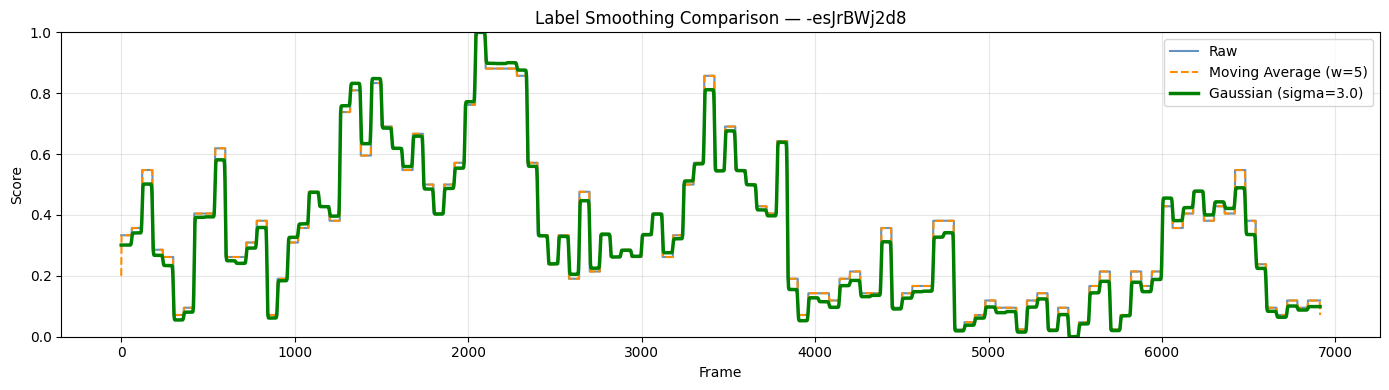

In [ ]:
sample_id  = list(video_scores.keys())[0]
sample_raw = []
for _, row in anno_df[anno_df['video_id'] == sample_id].iterrows():
    sample_raw.append(list(map(int, str(row['scores']).strip().split(','))))

raw_avg   = np.mean(sample_raw, axis=0)
raw_norm  = (raw_avg - raw_avg.min()) / (raw_avg.max() - raw_avg.min() + 1e-8)
ma_smooth = np.convolve(raw_norm, np.ones(5)/5, mode='same')
gauss_sm  = video_scores[sample_id]['gtscore']

plt.figure(figsize=(14, 4))
plt.plot(raw_norm,  lw=1.5, alpha=0.85, label='Raw', color='steelblue')
plt.plot(ma_smooth, lw=1.5, linestyle='--', label='Moving Average (w=5)', color='darkorange')
plt.plot(gauss_sm,  lw=2.5, label=f'Gaussian (sigma={SMOOTH_SIGMA})', color='green')
plt.title(f'Label Smoothing Comparison — {sample_id}')
plt.xlabel('Frame'); plt.ylabel('Score'); plt.ylim(0, 1)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'label_smoothing_comparison.png'), dpi=150)
plt.show()

## Step 5: Frame Extraction at 2 FPS

In [ ]:
FPS_TARGET = 2

def extract_frames(video_path: str, video_id: str, fps_target: int = 2) -> int:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open: {video_id}"); return 0

    video_fps       = cap.get(cv2.CAP_PROP_FPS)
    frame_interval  = max(1, int(video_fps / fps_target))
    video_frame_dir = os.path.join(FRAMES_DIR, video_id)
    os.makedirs(video_frame_dir, exist_ok=True)

    saved, frame_idx = 0, 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if frame_idx % frame_interval == 0:
            cv2.imwrite(
                os.path.join(video_frame_dir, f"frame_{saved:05d}.jpg"),
                cv2.resize(frame, (224, 224))
            )
            saved += 1
        frame_idx += 1
    cap.release()
    return saved

print(f"Starting frame extraction at {FPS_TARGET} FPS...\n")
video_files     = [f for f in os.listdir(VIDEO_PATH) if f.endswith('.mp4')]
video_ids       = [f.replace('.mp4', '') for f in video_files]
total_extracted = 0

for video_file in tqdm(video_files, desc="Extracting frames"):
    video_id        = video_file.replace('.mp4', '')
    video_frame_dir = os.path.join(FRAMES_DIR, video_id)
    if os.path.exists(video_frame_dir) and len(os.listdir(video_frame_dir)) > 0:
        total_extracted += len(os.listdir(video_frame_dir)); continue
    total_extracted += extract_frames(os.path.join(VIDEO_PATH, video_file), video_id, FPS_TARGET)

print(f"Frame extraction complete! Total frames: {total_extracted}")

# Sync newly extracted frames to local SSD for this session
print("\nSyncing frames to local SSD...")
shutil.copytree(FRAMES_DIR, LOCAL_FRAMES, dirs_exist_ok=True)
print(f"  Synced to {LOCAL_FRAMES}")

Starting frame extraction at 2 FPS...



Extracting frames: 100%|██████████| 50/50 [00:00<00:00, 122.21it/s]


Frame extraction complete! Total frames: 26634

Syncing frames to local SSD...
  Synced to /content/VideoInsight_local/frames


## Step 6A: ResNet50 Feature Extraction

ResNet50 pretrained on ImageNet — features cached to disk.

In [ ]:
base_resnet = keras.applications.ResNet50(
    weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3)
)
base_resnet.trainable = False
print(f"ResNet50 loaded | Output: {base_resnet.output_shape}")

def preprocess_resnet(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return keras.applications.resnet50.preprocess_input(
        cv2.resize(rgb, (224, 224)).astype(np.float32))

def extract_resnet_features(video_id: str):
    video_frame_dir = os.path.join(FRAMES_DIR, video_id)
    frame_files     = sorted(os.listdir(video_frame_dir)) if os.path.exists(video_frame_dir) else []
    if not frame_files: return None
    batch      = np.stack([preprocess_resnet(cv2.imread(os.path.join(video_frame_dir, f))) for f in frame_files])
    raw_feats  = base_resnet.predict(batch, verbose=0)
    diff_feats = np.zeros_like(raw_feats)
    diff_feats[1:] = raw_feats[1:] - raw_feats[:-1]
    return np.concatenate([raw_feats, diff_feats], axis=1).astype(np.float32)  # (T, 4096)

print("\nExtracting ResNet50 features...")
for video_id in tqdm(video_ids, desc="ResNet50"):
    feat_path = os.path.join(FEATURES_RESNET, f"{video_id}.npy")
    if os.path.exists(feat_path): continue
    feats = extract_resnet_features(video_id)
    if feats is not None: np.save(feat_path, feats)
print(f"Done! Saved to: {FEATURES_RESNET}")

# Sync ResNet features to local SSD
print("\nSyncing ResNet features to local SSD...")
shutil.copytree(FEATURES_RESNET, LOCAL_FEATURES_RESNET, dirs_exist_ok=True)
print(f"  Synced to {LOCAL_FEATURES_RESNET}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 loaded | Output: (None, 2048)

Extracting ResNet50 features...


ResNet50: 100%|██████████| 50/50 [00:00<00:00, 7918.86it/s]

Done! Saved to: /content/drive/MyDrive/VideoInsight/features_resnet

Syncing ResNet features to local SSD...


  Synced to /content/VideoInsight_local/features_resnet


## Step 6B: CLIP ViT Feature Extraction

OpenAI CLIP ViT-B/32 — features cached to disk.

In [ ]:
clip_model, clip_preprocess = clip.load("ViT-B/32", device=torch_device)
clip_model.eval()
print(f"CLIP ViT-B/32 loaded on {torch_device}")

def extract_clip_features(video_id: str):
    video_frame_dir = os.path.join(FRAMES_DIR, video_id)
    frame_files     = sorted(os.listdir(video_frame_dir)) if os.path.exists(video_frame_dir) else []
    if not frame_files: return None
    raw_feats = []
    for frame_file in frame_files:
        img = Image.open(os.path.join(video_frame_dir, frame_file)).convert("RGB")
        inp = clip_preprocess(img).unsqueeze(0).to(torch_device)
        with torch.no_grad():
            feat = clip_model.encode_image(inp).cpu().numpy().squeeze(0)
        raw_feats.append(feat)
    raw_feats  = np.array(raw_feats, dtype=np.float32)
    diff_feats = np.zeros_like(raw_feats)
    diff_feats[1:] = raw_feats[1:] - raw_feats[:-1]
    return np.concatenate([raw_feats, diff_feats], axis=1).astype(np.float32)  # (T, 1024)

print("\nExtracting CLIP features...")
for video_id in tqdm(video_ids, desc="CLIP"):
    feat_path = os.path.join(FEATURES_CLIP, f"{video_id}.npy")
    if os.path.exists(feat_path): continue
    feats = extract_clip_features(video_id)
    if feats is not None: np.save(feat_path, feats)
print(f"Done! Saved to: {FEATURES_CLIP}")

# Sync CLIP features to local SSD
print("\nSyncing CLIP features to local SSD...")
shutil.copytree(FEATURES_CLIP, LOCAL_FEATURES_CLIP, dirs_exist_ok=True)
print(f"  Synced to {LOCAL_FEATURES_CLIP}")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 289MiB/s]


CLIP ViT-B/32 loaded on cuda

Extracting CLIP features...


CLIP: 100%|██████████| 50/50 [00:00<00:00, 7980.64it/s]

Done! Saved to: /content/drive/MyDrive/VideoInsight/features_clip

Syncing CLIP features to local SSD...


  Synced to /content/VideoInsight_local/features_clip


## Step 7: Dataset Preparation

- **Stratified split** — all 10 TVSum50 categories represented in both train and val
- **MAX_SEQ_LEN at p75** — consistent across all three branches
- **Temporal augmentation** — jitter (A/B only), sequence reversal, score dropout

In [ ]:
def stratified_split(valid_video_ids, info_df, val_per_category=1, random_state=42):
    rng        = np.random.default_rng(random_state)
    id_to_cat  = dict(zip(info_df['video_id'], info_df['category']))
    cat_to_ids = {}
    for vid in valid_video_ids:
        cat = id_to_cat.get(vid, 'UNKNOWN')
        cat_to_ids.setdefault(cat, []).append(vid)
    train_ids, val_ids = [], []
    print("Stratified split by category:")
    for cat, ids in sorted(cat_to_ids.items()):
        ids_arr = np.array(ids)
        rng.shuffle(ids_arr)
        n_val = min(val_per_category, len(ids_arr) - 1)
        val_ids.extend(ids_arr[:n_val].tolist())
        train_ids.extend(ids_arr[n_val:].tolist())
        print(f"  {cat}: {len(ids_arr)} total -> {len(ids_arr)-n_val} train | {n_val} val")
    print(f"\nTotal -> Train: {len(train_ids)} | Val: {len(val_ids)}")
    return train_ids, val_ids

def compute_max_seq_len(valid_video_ids, features_dir, percentile=75):
    seq_lengths = [len(np.load(os.path.join(features_dir, f"{v}.npy")))
                   for v in valid_video_ids
                   if os.path.exists(os.path.join(features_dir, f"{v}.npy"))]
    max_len = int(np.percentile(seq_lengths, percentile))
    print(f"  Seq lengths: min={min(seq_lengths)} max={max(seq_lengths)} p{percentile}={max_len}")
    return max_len

def compute_max_seq_len_from_frames(valid_video_ids, percentile=75):
    """For CNN end-to-end — count frames directly from disk instead of .npy files."""
    seq_lengths = []
    for v in valid_video_ids:
        d = os.path.join(FRAMES_DIR, v)
        if os.path.exists(d):
            seq_lengths.append(len(os.listdir(d)))
    max_len = int(np.percentile(seq_lengths, percentile))
    print(f"  Frame counts: min={min(seq_lengths)} max={max(seq_lengths)} p{percentile}={max_len}")
    return max_len

### Temporal Augmentation

In [ ]:
AUG_TYPES = ['none', 'jitter', 'reversal', 'score_dropout']

def augment_sequence(features: np.ndarray, labels: np.ndarray,
                     mask: np.ndarray, aug_type: str):
    """
    FIX 1 (original): mask is passed in and returned so score_dropout can zero it.
    Jitter is included for feature-based branches (A & B) — it shifts frame
    indices within the cached feature array, which is fast. It is intentionally
    excluded from the CNN frame-loader (Branch C) because that branch would need
    to reload different JPEG files from disk, which is slow and complicates the
    generator. See make_dataset_frames for Branch C augmentation choices.
    """
    T = len(features)
    if aug_type == 'jitter':
        shift = np.random.randint(-5, 6)
        idx   = np.clip(np.arange(T) + shift, 0, T - 1)
        return features[idx], labels[idx], mask[idx]
    elif aug_type == 'reversal':
        return features[::-1].copy(), labels[::-1].copy(), mask[::-1].copy()
    elif aug_type == 'score_dropout':
        aug_feat   = features.copy()
        aug_labels = labels.copy()
        aug_mask   = mask.copy()
        win   = max(1, int(T * 0.10))
        start = np.random.randint(0, T - win)
        aug_feat[start:start+win]   = 0.0
        aug_labels[start:start+win] = 0.0
        aug_mask[start:start+win]   = 0.0
        return aug_feat, aug_labels, aug_mask
    return features, labels, mask

### tf.data Dataset Generator (Branches A & B — feature vectors)

In [ ]:
def make_dataset(video_ids, video_scores, features_dir,
                 max_seq_len, feat_dim, batch_size,
                 shuffle=False, augment=False):

    def generator():
        for video_id in video_ids:
            feat_path = os.path.join(features_dir, f"{video_id}.npy")
            if not os.path.exists(feat_path): continue
            features       = np.load(feat_path).astype(np.float32)
            labels         = video_scores[video_id]['gtscore']
            label_idx      = np.linspace(0, len(labels)-1, len(features), dtype=int)
            labels_aligned = labels[label_idx].astype(np.float32)
            T = len(features)
            if T >= max_seq_len:
                features, labels_aligned = features[:max_seq_len], labels_aligned[:max_seq_len]
                mask = np.ones(max_seq_len, dtype=np.float32)
            else:
                pad            = max_seq_len - T
                features       = np.vstack([features, np.zeros((pad, feat_dim), np.float32)])
                labels_aligned = np.concatenate([labels_aligned, np.zeros(pad, np.float32)])
                mask           = np.array([1.]*T + [0.]*pad, dtype=np.float32)
            if augment:
                aug = np.random.choice(AUG_TYPES)
                features, labels_aligned, mask = augment_sequence(
                    features, labels_aligned, mask, aug)
            yield features, labels_aligned, mask

    sig = (
        tf.TensorSpec(shape=(max_seq_len, feat_dim), dtype=tf.float32),
        tf.TensorSpec(shape=(max_seq_len,),           dtype=tf.float32),
        tf.TensorSpec(shape=(max_seq_len,),           dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(generator, output_signature=sig)
    if shuffle:
        ds = ds.shuffle(len(video_ids), seed=42)
        # NEW 1: repeat x4 so each video is seen 4x per epoch with different
        # augmentation — increases steps/epoch from ~10 to ~40 without the
        # gradient instability of reducing batch size
        ds = ds.repeat(4)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

### tf.data Dataset Generator (Branch C — sliding window over raw frames)

> **Sliding window replaces fixed truncation.**
> Instead of cutting each video at p75 frames and losing the rest, a window
> of fixed size (`WINDOW_SIZE=96`) slides across the full video with 50% overlap
> (`WINDOW_STRIDE=48`). Each window is a GPU-safe fixed-size chunk.
>
> A 300-frame video produces ~5 windows instead of 1 truncated sequence,
> so the model sees the full temporal arc of every video.
>
> `'jitter'` augmentation is excluded — it would require reloading different
> JPEG files per window position, which is slow. Reversal and score_dropout apply.

In [ ]:
WINDOW_SIZE   = 96   # GPU-safe fixed chunk size
WINDOW_STRIDE = 48   # 50% overlap — preserves boundary context

def make_dataset_frames_sliding(video_ids, video_scores, frames_dir,
                                 window_size, stride, batch_size,
                                 shuffle=False, augment=False):
    """
    Sliding window dataset generator for Branch C (CNN end-to-end).

    Covers the FULL video by sliding a fixed-size window across all frames.
    GPU memory stays safe because each window is always exactly window_size frames.
    Steps per epoch ~= sum(ceil(T / stride)) across all training videos,
    which is 5-10x more than the old truncation approach.
    """
    IMG_SIZE_CNN = 64

    def generator():
        ids = list(video_ids)
        if shuffle:
            np.random.shuffle(ids)

        for video_id in ids:
            video_frame_dir = os.path.join(frames_dir, video_id)
            if not os.path.exists(video_frame_dir):
                continue

            frame_files = sorted(os.listdir(video_frame_dir))
            if not frame_files:
                continue

            # Load ALL frames for this video into memory
            frames = []
            for ff in frame_files:
                bgr = cv2.imread(os.path.join(video_frame_dir, ff))
                if bgr is None:
                    continue
                rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
                rgb = cv2.resize(rgb, (IMG_SIZE_CNN, IMG_SIZE_CNN))
                frames.append(rgb.astype(np.float32) / 255.0)

            if len(frames) == 0:
                continue

            frames = np.stack(frames)  # (T, 64, 64, 3)
            T = len(frames)

            # Align ground-truth labels to frame count
            labels    = video_scores[video_id]['gtscore']
            label_idx = np.linspace(0, len(labels)-1, T, dtype=int)
            labels_aligned = labels[label_idx].astype(np.float32)

            # Build list of window start positions covering the full video
            starts = list(range(0, max(1, T - window_size + 1), stride))

            # Always ensure the last frames are covered
            if len(starts) == 0 or starts[-1] + window_size < T:
                starts.append(max(0, T - window_size))

            for start in starts:
                end        = start + window_size
                win_frames = frames[start:end]
                win_labels = labels_aligned[start:end]

                # Pad only if video is shorter than window_size
                actual_len = len(win_frames)
                if actual_len < window_size:
                    pad = window_size - actual_len
                    win_frames = np.concatenate([
                        win_frames,
                        np.zeros((pad, IMG_SIZE_CNN, IMG_SIZE_CNN, 3), np.float32)
                    ], axis=0)
                    win_labels = np.concatenate([win_labels, np.zeros(pad, np.float32)])
                    mask = np.array([1.]*actual_len + [0.]*pad, dtype=np.float32)
                else:
                    mask = np.ones(window_size, dtype=np.float32)

                if augment:
                    # 'jitter' excluded — would require reloading different JPEGs per
                    # window position, which is slow and complicates the generator
                    aug = np.random.choice(['none', 'reversal', 'score_dropout'])
                    if aug == 'reversal':
                        win_frames = win_frames[::-1].copy()
                        win_labels = win_labels[::-1].copy()
                        mask       = mask[::-1].copy()
                    elif aug == 'score_dropout':
                        win_len    = max(1, int(window_size * 0.10))
                        start_drop = np.random.randint(0, max(1, window_size - win_len))
                        win_frames[start_drop:start_drop+win_len] = 0.0
                        win_labels[start_drop:start_drop+win_len] = 0.0
                        mask[start_drop:start_drop+win_len]       = 0.0

                yield win_frames, win_labels, mask

    sig = (
        tf.TensorSpec(shape=(window_size, IMG_SIZE_CNN, IMG_SIZE_CNN, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(window_size,), dtype=tf.float32),
        tf.TensorSpec(shape=(window_size,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=sig)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

### Build Datasets for All Three Branches

In [ ]:
BATCH_SIZE_R = 4
BATCH_SIZE_C = 4
BATCH_SIZE_N = 2

# ResNet50 — train from LOCAL SSD, validate from LOCAL SSD
resnet_valid_ids = [v for v in video_scores
                    if os.path.exists(os.path.join(LOCAL_FEATURES_RESNET, f"{v}.npy"))]
print("=== ResNet50 ===")
train_ids_r, val_ids_r = stratified_split(resnet_valid_ids, info_df)
MAX_SEQ_LEN_R = compute_max_seq_len(resnet_valid_ids, LOCAL_FEATURES_RESNET, percentile=75)
FEAT_DIM_R    = 4096
train_ds_r = make_dataset(train_ids_r, video_scores, LOCAL_FEATURES_RESNET,
                           MAX_SEQ_LEN_R, FEAT_DIM_R, BATCH_SIZE_R, shuffle=True, augment=True)
val_ds_r   = make_dataset(val_ids_r, video_scores, LOCAL_FEATURES_RESNET,
                           MAX_SEQ_LEN_R, FEAT_DIM_R, BATCH_SIZE_R, shuffle=False, augment=False)

# CLIP — train from LOCAL SSD
clip_valid_ids = [v for v in video_scores
                  if os.path.exists(os.path.join(LOCAL_FEATURES_CLIP, f"{v}.npy"))]
print("\n=== CLIP ViT ===")
train_ids_c, val_ids_c = stratified_split(clip_valid_ids, info_df)
MAX_SEQ_LEN_C = compute_max_seq_len(clip_valid_ids, LOCAL_FEATURES_CLIP, percentile=75)
FEAT_DIM_C    = 1024
train_ds_c = make_dataset(train_ids_c, video_scores, LOCAL_FEATURES_CLIP,
                           MAX_SEQ_LEN_C, FEAT_DIM_C, BATCH_SIZE_C, shuffle=True, augment=True)
val_ds_c   = make_dataset(val_ids_c, video_scores, LOCAL_FEATURES_CLIP,
                           MAX_SEQ_LEN_C, FEAT_DIM_C, BATCH_SIZE_C, shuffle=False, augment=False)

# CNN end-to-end — sliding window over LOCAL SSD frames
cnn_valid_ids = [v for v in video_scores
                 if os.path.exists(os.path.join(LOCAL_FRAMES, v))
                 and len(os.listdir(os.path.join(LOCAL_FRAMES, v))) > 0]
print("\n=== CNN Scratch end-to-end (sliding window) ===")
train_ids_n, val_ids_n = stratified_split(cnn_valid_ids, info_df)

# Count total windows to understand real dataset size
total_train_windows = 0
for v in train_ids_n:
    d = os.path.join(LOCAL_FRAMES, v)
    if os.path.exists(d):
        T = len(os.listdir(d))
        starts = list(range(0, max(1, T - WINDOW_SIZE + 1), WINDOW_STRIDE))
        if len(starts) == 0 or (starts[-1] + WINDOW_SIZE < T):
            starts.append(max(0, T - WINDOW_SIZE))
        total_train_windows += len(starts)

print(f"  Window size    : {WINDOW_SIZE} frames")
print(f"  Window stride  : {WINDOW_STRIDE} frames (50% overlap)")
print(f"  Training videos: {len(train_ids_n)}")
print(f"  Total train windows: {total_train_windows}")
print(f"  Avg windows/video  : {total_train_windows/max(1,len(train_ids_n)):.1f}")

train_ds_n = make_dataset_frames_sliding(
    train_ids_n, video_scores, LOCAL_FRAMES,
    WINDOW_SIZE, WINDOW_STRIDE, BATCH_SIZE_N,
    shuffle=True, augment=True
)
val_ds_n = make_dataset_frames_sliding(
    val_ids_n, video_scores, LOCAL_FRAMES,
    WINDOW_SIZE, WINDOW_STRIDE, BATCH_SIZE_N,
    shuffle=False, augment=False
)

print("\nDatasets ready — all reading from local SSD!")
print(f"  ResNet50 seq len : {MAX_SEQ_LEN_R} | feat dim: {FEAT_DIM_R} | steps/epoch ~{4*len(train_ids_r)//BATCH_SIZE_R}")
print(f"  CLIP ViT seq len : {MAX_SEQ_LEN_C} | feat dim: {FEAT_DIM_C} | steps/epoch ~{4*len(train_ids_c)//BATCH_SIZE_C}")
print(f"  CNN window size  : {WINDOW_SIZE} | stride: {WINDOW_STRIDE} | total windows: {total_train_windows}")

=== ResNet50 ===
Stratified split by category:
  BK: 5 total -> 4 train | 1 val
  BT: 5 total -> 4 train | 1 val
  DS: 5 total -> 4 train | 1 val
  FM: 5 total -> 4 train | 1 val
  GA: 5 total -> 4 train | 1 val
  MS: 5 total -> 4 train | 1 val
  PK: 5 total -> 4 train | 1 val
  PR: 5 total -> 4 train | 1 val
  VT: 5 total -> 4 train | 1 val
  VU: 5 total -> 4 train | 1 val

Total -> Train: 40 | Val: 10
  Seq lengths: min=211 max=1387 p75=668

=== CLIP ViT ===
Stratified split by category:
  BK: 5 total -> 4 train | 1 val
  BT: 5 total -> 4 train | 1 val
  DS: 5 total -> 4 train | 1 val
  FM: 5 total -> 4 train | 1 val
  GA: 5 total -> 4 train | 1 val
  MS: 5 total -> 4 train | 1 val
  PK: 5 total -> 4 train | 1 val
  PR: 5 total -> 4 train | 1 val
  VT: 5 total -> 4 train | 1 val
  VU: 5 total -> 4 train | 1 val

Total -> Train: 40 | Val: 10
  Seq lengths: min=211 max=1387 p75=668

=== CNN Scratch end-to-end (sliding window) ===
Stratified split by category:
  BK: 5 total -> 4 train |

## Step 8: Model Architectures

### Branches A & B — BiLSTM + Transformer (takes pre-extracted feature vectors)

In [ ]:
# FIX 7: set policy explicitly so this cell is self-contained
mixed_precision.set_global_policy('mixed_float16')

def build_bilstm_transformer(input_size, hidden_size=512, num_lstm_layers=2,
                              dropout=0.3, num_heads=4, ff_dim=512,
                              max_seq_len=None, name='EngagementModel'):
    inputs = keras.Input(shape=(max_seq_len, input_size), name='frame_features')
    x = inputs
    for i in range(num_lstm_layers):
        x = layers.Bidirectional(
            layers.LSTM(hidden_size, return_sequences=True,
                        dropout=dropout, recurrent_dropout=0.0),
            name=f'bilstm_{i+1}'
        )(x)
        x = layers.Dropout(dropout, name=f'dropout_lstm_{i+1}')(x)
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=(hidden_size * 2) // num_heads,
        dropout=dropout, name='mha'
    )(x, x)
    x = layers.Add(name='residual_1')([x, attn_out])
    x = layers.LayerNormalization(name='layernorm_1')(x)
    ff = layers.Dense(ff_dim, activation='relu', name='ff_1')(x)
    ff = layers.Dropout(dropout, name='dropout_ff')(ff)
    ff = layers.Dense(hidden_size * 2, name='ff_2')(ff)
    x  = layers.Add(name='residual_2')([x, ff])
    x  = layers.LayerNormalization(name='layernorm_2')(x)
    out = layers.Dense(1, activation='sigmoid', name='engagement')(x)
    out = layers.Reshape((-1,), name='squeeze')(out)
    return keras.Model(inputs, out, name=name)

HIDDEN_SIZE     = 512
NUM_LSTM_LAYERS = 2
DROPOUT         = 0.3
NUM_HEADS       = 4
FF_DIM          = 512

model_resnet = build_bilstm_transformer(
    input_size=FEAT_DIM_R, hidden_size=HIDDEN_SIZE,
    num_lstm_layers=NUM_LSTM_LAYERS, dropout=DROPOUT,
    num_heads=NUM_HEADS, ff_dim=FF_DIM,
    max_seq_len=MAX_SEQ_LEN_R, name='ResNet50_BiLSTM_Transformer')

model_clip = build_bilstm_transformer(
    input_size=FEAT_DIM_C, hidden_size=HIDDEN_SIZE,
    num_lstm_layers=NUM_LSTM_LAYERS, dropout=DROPOUT,
    num_heads=NUM_HEADS, ff_dim=FF_DIM,
    max_seq_len=MAX_SEQ_LEN_C, name='CLIP_BiLSTM_Transformer')

print("ResNet50 + BiLSTM + Transformer:"); model_resnet.summary()
print("\nCLIP ViT + BiLSTM + Transformer:");    model_clip.summary()

ResNet50 + BiLSTM + Transformer:


Model: "ResNet50_BiLSTM_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frame_features      │ (None, 668, 4096) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 668, 1024) │ 18,878,464 │ frame_features[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm_1      │ (None, 668, 1024) │          0 │ bilstm_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 668, 1024) │  6,295,552 │ dropout_lstm_1[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm_2      │ (None, 668, 1024) │          0 │ bilstm_2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 668, 1024) │  4,198,400 │ dropout_lstm_2[0… │
│ (MultiHeadAttentio… │                   │            │ dropout_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_1 (Add)    │ (None, 668, 1024) │          0 │ dropout_lstm_2[0… │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_1         │ (None, 668, 1024) │      2,048 │ residual_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_1 (Dense)        │ (None, 668, 512)  │    524,800 │ layernorm_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_ff          │ (None, 668, 512)  │          0 │ ff_1[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_2 (Dense)        │ (None, 668, 1024) │    525,312 │ dropout_ff[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_2 (Add)    │ (None, 668, 1024) │          0 │ layernorm_1[0][0… │
│                     │                   │            │ ff_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_2         │ (None, 668, 1024) │      2,048 │ residual_2[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement (Dense)  │ (None, 668, 1)    │      1,025 │ layernorm_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squeeze (Reshape)   │ (None, 668)       │          0 │ engagement[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,427,649 (116.07 MB)

 Trainable params: 30,427,649 (116.07 MB)

...

Model: "CLIP_BiLSTM_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frame_features      │ (None, 668, 1024) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 668, 1024) │  6,295,552 │ frame_features[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm_1      │ (None, 668, 1024) │          0 │ bilstm_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 668, 1024) │  6,295,552 │ dropout_lstm_1[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm_2      │ (None, 668, 1024) │          0 │ bilstm_2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 668, 1024) │  4,198,400 │ dropout_lstm_2[0… │
│ (MultiHeadAttentio… │                   │            │ dropout_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_1 (Add)    │ (None, 668, 1024) │          0 │ dropout_lstm_2[0… │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_1         │ (None, 668, 1024) │      2,048 │ residual_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_1 (Dense)        │ (None, 668, 512)  │    524,800 │ layernorm_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_ff          │ (None, 668, 512)  │          0 │ ff_1[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_2 (Dense)        │ (None, 668, 1024) │    525,312 │ dropout_ff[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_2 (Add)    │ (None, 668, 1024) │          0 │ layernorm_1[0][0… │
│                     │                   │            │ ff_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_2         │ (None, 668, 1024) │      2,048 │ residual_2[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement (Dense)  │ (None, 668, 1)    │      1,025 │ layernorm_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squeeze (Reshape)   │ (None, 668)       │          0 │ engagement[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,844,737 (68.07 MB)

 Trainable params: 17,844,737 (68.07 MB)

 Non-trainable params: 0 (0.00 B)

### Branch C — CNN (scratch) + BiLSTM + Transformer (end-to-end)

> **Design:** A lightweight CNN is wrapped in a chunked TimeDistributed-style layer so it
> processes each frame independently. The resulting per-frame embeddings are then passed
> into the same BiLSTM + Transformer head. Because everything is one `keras.Model`, the
> CNN weights receive gradients during training.
>
> **Architecture:**
> - CNN: 4 × (Conv2D → GroupNorm → ReLU) + GlobalAvgPool → Dense(128)
> - GroupNorm replaces BatchNorm — BatchNorm is unreliable at batch size 2
> - 1 × BiLSTM(128) → Multi-head Attention(2 heads) → Feedforward → Sigmoid output
> - hidden size 128 (vs 512 for A/B) to keep GPU memory reasonable with raw frame inputs
> - Frame size: **64×64** (reduced from 112 to fit memory budget)

In [ ]:
# FIX 7: explicitly switch to float32 for CNN branch
# mixed_float16 causes NaN gradients in randomly initialised CNNs due to float16 underflow
mixed_precision.set_global_policy('float32')
print("Switched to float32 for CNN branch stability")

def build_cnn_encoder(input_shape=(64, 64, 3), feat_dim=128, name='CNN_Encoder'):
    inp = keras.Input(shape=input_shape, name='frame')
    x = inp

    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.GroupNormalization(groups=4)(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.GroupNormalization(groups=4)(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.GroupNormalization(groups=4)(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.GroupNormalization(groups=4)(x)
    x = layers.Activation('relu')(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(feat_dim, activation='relu')(x)

    return keras.Model(inp, x, name=name)


class ChunkedCNNLayer(keras.layers.Layer):
    def __init__(self, cnn_encoder, chunk_size=4, feat_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.cnn_encoder = cnn_encoder
        self.chunk_size  = chunk_size
        self.feat_dim    = feat_dim

    def call(self, frames, training=False):
        b        = tf.shape(frames)[0]
        seq_len  = frames.shape[1]
        h, w, c  = frames.shape[2], frames.shape[3], frames.shape[4]

        remainder = seq_len % self.chunk_size
        if remainder != 0:
            pad_len = self.chunk_size - remainder
            padding = tf.zeros((b, pad_len, h, w, c), dtype=frames.dtype)
            frames  = tf.concat([frames, padding], axis=1)
            padded_seq_len = seq_len + pad_len
        else:
            padded_seq_len = seq_len

        n_chunks = padded_seq_len // self.chunk_size
        chunks   = tf.split(frames, num_or_size_splits=n_chunks, axis=1)

        recompute_cnn = tf.recompute_grad(self.cnn_encoder)

        embeddings = []
        for chunk in chunks:
            chunk_flat = tf.reshape(chunk, (-1, h, w, c))
            feats      = recompute_cnn(chunk_flat, training=training)
            feats      = tf.reshape(feats, (b, -1, self.feat_dim))
            embeddings.append(feats)

        result = tf.concat(embeddings, axis=1)
        return result[:, :seq_len, :]

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], self.feat_dim)

    def get_config(self):
        config = super().get_config()
        config.update({'chunk_size': self.chunk_size, 'feat_dim': self.feat_dim})
        return config


class RecomputedBiLSTM(keras.layers.Layer):
    def __init__(self, units, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.bilstm = layers.Bidirectional(
            layers.LSTM(units, return_sequences=True, dropout=dropout, recurrent_dropout=0.0)
        )

    def call(self, x, training=False):
        recompute_fn = tf.recompute_grad(
            lambda inp: self.bilstm(inp, training=training)
        )
        return recompute_fn(x)

    def get_config(self):
        return super().get_config()


class RecomputedMHA(keras.layers.Layer):
    def __init__(self, num_heads, key_dim, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim, dropout=dropout
        )

    def call(self, x, training=False):
        recompute_fn = tf.recompute_grad(
            lambda inp: self.mha(inp, inp, training=training)
        )
        return recompute_fn(x)

    def get_config(self):
        return super().get_config()


def build_cnn_bilstm_transformer(max_seq_len, frame_shape=(64, 64, 3),
                                  cnn_feat_dim=128, hidden_size=128,
                                  num_lstm_layers=1, dropout=0.3,
                                  num_heads=2, ff_dim=128, name='CNN_E2E'):

    cnn_encoder = build_cnn_encoder(input_shape=frame_shape, feat_dim=cnn_feat_dim, name='CNN_Encoder')

    inputs = keras.Input(shape=(max_seq_len,) + frame_shape, name='raw_frames')

    x = ChunkedCNNLayer(cnn_encoder, chunk_size=4, feat_dim=cnn_feat_dim, name='chunked_cnn')(inputs)

    for i in range(num_lstm_layers):
        x = RecomputedBiLSTM(hidden_size, dropout=dropout, name=f'bilstm_{i+1}')(x)
        x = layers.Dropout(dropout, name=f'dropout_lstm_{i+1}')(x)

    attn_out = RecomputedMHA(num_heads=num_heads, key_dim=(hidden_size * 2) // num_heads,
                              dropout=dropout, name='mha')(x)

    x = layers.Add(name='residual_1')([x, attn_out])
    x = layers.LayerNormalization(name='layernorm_1')(x)

    ff = layers.Dense(ff_dim, activation='relu', name='ff_1')(x)
    ff = layers.Dropout(dropout, name='dropout_ff')(ff)
    ff = layers.Dense(hidden_size * 2, name='ff_2')(ff)

    x = layers.Add(name='residual_2')([x, ff])
    x = layers.LayerNormalization(name='layernorm_2')(x)

    out = layers.Dense(1, activation='sigmoid', dtype='float32', name='engagement')(x)
    out = layers.Reshape((-1,), name='squeeze')(out)

    return keras.Model(inputs, out, name=name)


CNN_FEAT_DIM    = 128
CNN_HIDDEN_SIZE = 128
DROPOUT         = 0.3

model_cnn = build_cnn_bilstm_transformer(
    max_seq_len=WINDOW_SIZE,  # sliding window size
    frame_shape=(64, 64, 3),
    cnn_feat_dim=CNN_FEAT_DIM,
    hidden_size=CNN_HIDDEN_SIZE,
    num_lstm_layers=1,
    dropout=DROPOUT,
    num_heads=2,
    ff_dim=128,
    name='CNN_Scratch_E2E'
)

print("CNN Scratch + BiLSTM + Transformer:")
model_cnn.summary()
print(f"\nTotal trainable params: {model_cnn.count_params():,}")

Switched to float32 for CNN branch stability
CNN Scratch + BiLSTM + Transformer:


Model: "CNN_Scratch_E2E"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_frames          │ (None, 96, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chunked_cnn         │ (None, 96, 128)   │    114,192 │ raw_frames[0][0]  │
│ (ChunkedCNNLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 96, 256)   │    263,168 │ chunked_cnn[0][0] │
│ (RecomputedBiLSTM)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm_1      │ (None, 96, 256)   │          0 │ bilstm_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha (RecomputedMHA) │ (None, 96, 256)   │    263,168 │ dropout_lstm_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_1 (Add)    │ (None, 96, 256)   │          0 │ dropout_lstm_1[0… │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_1         │ (None, 96, 256)   │        512 │ residual_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_1 (Dense)        │ (None, 96, 128)   │     32,896 │ layernorm_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_ff          │ (None, 96, 128)   │          0 │ ff_1[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_2 (Dense)        │ (None, 96, 256)   │     33,024 │ dropout_ff[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_2 (Add)    │ (None, 96, 256)   │          0 │ layernorm_1[0][0… │
│                     │                   │            │ ff_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_2         │ (None, 96, 256)   │        512 │ residual_2[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engagement (Dense)  │ (None, 96, 1)     │        257 │ layernorm_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squeeze (Reshape)   │ (None, 96)        │          0 │ engagement[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 707,729 (2.70 MB)

 Trainable params: 707,729 (2.70 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable params: 707,729


## Step 9: Custom Loss Function — MSE + Trend Loss

In [ ]:
def combined_engagement_loss(trend_lambda=0.5):
    """
    Returns a scalar loss for one batch.
    Masking is applied internally — the training loop must NOT re-apply
    mask weighting on top of this value (that would double-count the mask).
    """
    def loss_fn(y_true, y_pred):
        y_pred  = tf.cast(y_pred,  tf.float32)
        y_true  = tf.cast(y_true,  tf.float32)

        labels = y_true[:, :, 0]
        mask   = y_true[:, :, 1]

        mse_per  = tf.square(y_pred - labels)
        mse_loss = tf.reduce_sum(mse_per * mask) / tf.maximum(tf.reduce_sum(mask), 1.0)

        pred_diff   = y_pred[:, 1:] - y_pred[:, :-1]
        target_diff = labels[:, 1:] - labels[:, :-1]
        mask_diff   = mask[:, 1:] * mask[:, :-1]
        trend_loss  = tf.reduce_sum(tf.square(pred_diff - target_diff) * mask_diff) / \
                      tf.maximum(tf.reduce_sum(mask_diff), 1.0)

        return mse_loss + trend_lambda * trend_loss
    return loss_fn

def make_y_true(labels, mask):
    labels = tf.cast(labels, tf.float32)
    mask   = tf.cast(mask,   tf.float32)
    return tf.stack([labels, mask], axis=-1)

loss_fn = combined_engagement_loss(trend_lambda=0.5)
print("Loss: MSE + 0.5 x Trend Loss (masking handled inside loss_fn)")

Loss: MSE + 0.5 x Trend Loss (masking handled inside loss_fn)


## Step 10: Training Setup

In [ ]:
EPOCHS     = 100
EPOCHS_CNN = 50

LR         = 1e-4
PATIENCE   = 15
PATIENCE_CNN = 15

BEST_MODEL_RESNET = os.path.join(LOCAL_MODELS_DIR, 'resnet_best.keras')
BEST_MODEL_CLIP   = os.path.join(LOCAL_MODELS_DIR, 'clip_best.keras')
BEST_MODEL_CNN    = os.path.join(LOCAL_MODELS_DIR, 'cnn_e2e_best.keras')

optimizer_r = keras.optimizers.Adam(learning_rate=LR)
optimizer_c = keras.optimizers.Adam(learning_rate=LR)
optimizer_n = keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0)

print("=" * 60)
print("Training config")
print("=" * 60)
print(f"  Epochs (A & B) : {EPOCHS} | Patience: {PATIENCE}")
print(f"  Epochs (C)     : {EPOCHS_CNN} | Patience: {PATIENCE_CNN}")
print(f"  LR (A & B)     : {LR}")
print(f"  LR (C)         : 1e-5")
print(f"  Loss           : MSE + 0.5 x TrendLoss (mask inside loss_fn)")
print(f"  Patience (A&B) : {PATIENCE}")
print(f"  Patience (C)   : {PATIENCE_CNN}")
print(f"  Batch size (ResNet): {BATCH_SIZE_R}")
print(f"  Batch size (CLIP)  : {BATCH_SIZE_C}")
print(f"  Batch size (CNN)   : {BATCH_SIZE_N}")
# FIX 7: policy is set per-branch; show current state
print(f"  Mixed precision    : {mixed_precision.global_policy().name}")
print("=" * 60)
print("\nInput configuration:")
print(f"  ResNet50      : (batch, {MAX_SEQ_LEN_R}, 4096)")
print(f"  CLIP ViT      : (batch, {MAX_SEQ_LEN_C}, 1024)")
# FIX 2: corrected from 112x112 to 64x64
print(f"  CNN (scratch) : (batch, {WINDOW_SIZE}, 64, 64, 3)  [sliding window]")
print("\nCNN end-to-end note:")
print("  CNN trains jointly with BiLSTM + Transformer")
print("  CNN weights are updated via backprop (chunked + recompute_grad)")

Training config
  Epochs (A & B) : 100 | Patience: 15
  Epochs (C)     : 50 | Patience: 15
  LR (A & B)     : 0.0001
  LR (C)         : 1e-5
  Loss           : MSE + 0.5 x TrendLoss (mask inside loss_fn)
  Patience (A&B) : 15
  Patience (C)   : 15
  Batch size (ResNet): 4
  Batch size (CLIP)  : 4
  Batch size (CNN)   : 2
  Mixed precision    : float32

Input configuration:
  ResNet50      : (batch, 668, 4096)
  CLIP ViT      : (batch, 668, 1024)
  CNN (scratch) : (batch, 96, 64, 64, 3)  [sliding window]

CNN end-to-end note:
  CNN trains jointly with BiLSTM + Transformer
  CNN weights are updated via backprop (chunked + recompute_grad)


## Step 11: Training Loop — All Three Branches

In [ ]:
import gc

# Frames are already on local SSD from Step 3B (or Step 5 sync).
# Rebuild CNN sliding window datasets pointing to local SSD.
gc.collect()

train_ds_n = make_dataset_frames_sliding(
    train_ids_n, video_scores, LOCAL_FRAMES,
    WINDOW_SIZE, WINDOW_STRIDE, BATCH_SIZE_N,
    shuffle=True, augment=True
)
val_ds_n = make_dataset_frames_sliding(
    val_ids_n, video_scores, LOCAL_FRAMES,
    WINDOW_SIZE, WINDOW_STRIDE, BATCH_SIZE_N,
    shuffle=False, augment=False
)

print("=" * 60)
print("CNN datasets confirmed — sliding window, reading from local SSD")
print(f"  Source      : {LOCAL_FRAMES}")
print(f"  Window size : {WINDOW_SIZE} | Stride: {WINDOW_STRIDE}")
print(f"  Batch size  : {BATCH_SIZE_N}")
print("=" * 60)

CNN datasets confirmed — sliding window, reading from local SSD
  Source      : /content/VideoInsight_local/frames
  Window size : 96 | Stride: 48
  Batch size  : 2


In [ ]:
for x, y, m in train_ds_n.take(1):
    print("Frames shape :", x.shape, " — (batch, window, H, W, C)")
    print("Labels shape :", y.shape)
    print("Mask shape   :", m.shape)

Frames shape : (2, 96, 64, 64, 3)  — (batch, window, H, W, C)
Labels shape : (2, 96)
Mask shape   : (2, 96)


In [ ]:
ACCUM_STEPS = 4

def train_branch(model, train_ds, val_ds, optimizer,
                 best_model_path, branch_name, epochs=50, patience=7,
                 use_grad_accum=False, accum_steps=4):

    history          = {'train_loss': [], 'val_loss': []}
    best_val_loss    = float('inf')
    patience_counter = 0
    total_start      = time.time()

    print(f"\n{'='*55}")
    print(f"Training: {branch_name}")
    if use_grad_accum:
        print(f"Gradient accumulation: {accum_steps} steps "
              f"(effective batch = {accum_steps * BATCH_SIZE_N})")
    print(f"{'='*55}")

    for epoch in range(1, epochs + 1):
        epoch_start  = time.time()
        train_losses = []

        if use_grad_accum:
            accumulated_grads = [tf.zeros_like(v) for v in model.trainable_variables]

            for batch_idx, (features, labels, mask) in enumerate(train_ds):
                y_true = make_y_true(labels, mask)

                with tf.GradientTape() as tape:
                    preds       = model(features, training=True)
                    # FIX 1: loss_fn already applies masking internally.
                    # Do NOT re-apply mask here — that would double-count it.
                    loss        = loss_fn(y_true, preds)
                    scaled_loss = loss / accum_steps

                if tf.math.is_nan(loss):
                    print(f"\nNaN detected at epoch {epoch}, batch {batch_idx}")
                    break

                raw_grads = tape.gradient(scaled_loss, model.trainable_variables)
                raw_grads = [g if g is not None else tf.zeros_like(v)
                             for g, v in zip(raw_grads, model.trainable_variables)]

                accumulated_grads = [ag + g for ag, g in zip(accumulated_grads, raw_grads)]

                if (batch_idx + 1) % accum_steps == 0:
                    clipped_grads, _ = tf.clip_by_global_norm(accumulated_grads, 1.0)
                    optimizer.apply_gradients(zip(clipped_grads, model.trainable_variables))
                    accumulated_grads = [tf.zeros_like(v) for v in model.trainable_variables]
                    train_losses.append(float(loss))

                if batch_idx % 10 == 0:
                    print(f"  epoch {epoch} batch {batch_idx+1} loss: {float(loss):.4f}", end='\r')

        else:
            for batch_idx, (features, labels, mask) in enumerate(train_ds):
                y_true = make_y_true(labels, mask)

                with tf.GradientTape() as tape:
                    preds = model(features, training=True)
                    # FIX 1: loss_fn already applies masking internally.
                    # Do NOT re-apply mask here — that would double-count it.
                    loss  = loss_fn(y_true, preds)

                if tf.math.is_nan(loss):
                    print(f"\nNaN detected at epoch {epoch}, batch {batch_idx}")
                    break

                raw_grads = tape.gradient(loss, model.trainable_variables)
                raw_grads = [g if g is not None else tf.zeros_like(v)
                             for g, v in zip(raw_grads, model.trainable_variables)]

                grads, _ = tf.clip_by_global_norm(raw_grads, 1.0)
                optimizer.apply_gradients(zip(grads, model.trainable_variables))
                train_losses.append(float(loss))

                if batch_idx % 10 == 0:
                    print(f"  epoch {epoch} batch {batch_idx+1} loss: {float(loss):.4f}", end='\r')

        # Validation
        val_losses = []
        for features, labels, mask in val_ds:
            preds    = model(features, training=False)
            # FIX 1: same here — use loss_fn scalar directly, no outer masking
            val_loss = loss_fn(make_y_true(labels, mask), preds)
            val_losses.append(float(val_loss))

        tr_loss = float(np.mean(train_losses)) if train_losses else float('nan')
        vl_loss = float(np.mean(val_losses))

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if vl_loss < best_val_loss:
            best_val_loss    = vl_loss
            model.save(best_model_path)
            patience_counter = 0
            mark = " <- best"
        else:
            patience_counter += 1
            mark = ""

        print(f"Epoch [{epoch:02d}/{epochs}]  "
              f"Train: {tr_loss:.4f}  Val: {vl_loss:.4f}  "
              f"Time: {time.time()-epoch_start:.1f}s{mark}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    print(f"\nDone! Best Val: {best_val_loss:.4f} | "
          f"Total: {time.time()-total_start:.1f}s")
    return history


# FIX 7: restore mixed_float16 before training Branches A & B
mixed_precision.set_global_policy('mixed_float16')
print(f"Policy set to: {mixed_precision.global_policy().name}")

# Branch A — ResNet50
history_resnet = train_branch(
    model_resnet, train_ds_r, val_ds_r, optimizer_r,
    BEST_MODEL_RESNET, "ResNet50 + BiLSTM + Transformer",
    epochs=EPOCHS, patience=PATIENCE, use_grad_accum=False
)

del model_resnet, train_ds_r, val_ds_r, optimizer_r
gc.collect(); tf.keras.backend.clear_session()

Policy set to: mixed_float16

Training: ResNet50 + BiLSTM + Transformer
Epoch [01/100]  Train: 0.1047  Val: 0.0784  Time: 22.2s <- best
Epoch [02/100]  Train: 0.0631  Val: 0.0459  Time: 18.0s <- best
Epoch [03/100]  Train: 0.0411  Val: 0.0565  Time: 17.3s
Epoch [04/100]  Train: 0.0377  Val: 0.0481  Time: 17.5s
Epoch [05/100]  Train: 0.0312  Val: 0.0564  Time: 17.3s
Epoch [06/100]  Train: 0.0285  Val: 0.0648  Time: 17.4s
Epoch [07/100]  Train: 0.0328  Val: 0.0502  Time: 17.4s
Epoch [08/100]  Train: 0.0250  Val: 0.0470  Time: 17.3s
Epoch [09/100]  Train: 0.0229  Val: 0.0472  Time: 17.5s
Epoch [10/100]  Train: 0.0213  Val: 0.0461  Time: 17.4s
Epoch [11/100]  Train: 0.0205  Val: 0.0463  Time: 17.3s
Epoch [12/100]  Train: 0.0190  Val: 0.0492  Time: 17.5s
Epoch [13/100]  Train: 0.0186  Val: 0.0489  Time: 17.3s
Epoch [14/100]  Train: 0.0176  Val: 0.0485  Time: 17.3s
Epoch [15/100]  Train: 0.0174  Val: 0.0466  Time: 17.4s
Epoch [16/100]  Train: 0.0156  Val: 0.0487  Time: 17.4s
Epoch [17/100]  

In [ ]:
  # Branch B — CLIP ViT
history_clip = train_branch(
    model_clip, train_ds_c, val_ds_c, optimizer_c,
    BEST_MODEL_CLIP, "CLIP ViT + BiLSTM + Transformer",
    epochs=EPOCHS, patience=PATIENCE, use_grad_accum=False
)

del model_clip, train_ds_c, val_ds_c, optimizer_c
gc.collect(); tf.keras.backend.clear_session()

# FIX 7: switch to float32 before CNN training
mixed_precision.set_global_policy('float32')
print(f"Policy set to: {mixed_precision.global_policy().name} for CNN branch")


Training: CLIP ViT + BiLSTM + Transformer
Epoch [01/100]  Train: 0.0996  Val: 0.0443  Time: 17.1s <- best
Epoch [02/100]  Train: 0.0554  Val: 0.0512  Time: 16.6s
Epoch [03/100]  Train: 0.0499  Val: 0.0416  Time: 17.0s <- best
Epoch [04/100]  Train: 0.0395  Val: 0.0402  Time: 16.9s <- best
Epoch [05/100]  Train: 0.0377  Val: 0.0439  Time: 16.7s
Epoch [06/100]  Train: 0.0339  Val: 0.0421  Time: 16.8s
Epoch [07/100]  Train: 0.0328  Val: 0.0404  Time: 16.6s
Epoch [08/100]  Train: 0.0308  Val: 0.0397  Time: 17.0s <- best
Epoch [09/100]  Train: 0.0288  Val: 0.0407  Time: 16.8s
Epoch [10/100]  Train: 0.0284  Val: 0.0416  Time: 16.8s
Epoch [11/100]  Train: 0.0276  Val: 0.0410  Time: 16.7s
Epoch [12/100]  Train: 0.0275  Val: 0.0395  Time: 17.0s <- best
Epoch [13/100]  Train: 0.0260  Val: 0.0414  Time: 16.7s
Epoch [14/100]  Train: 0.0252  Val: 0.0404  Time: 16.7s
Epoch [15/100]  Train: 0.0245  Val: 0.0402  Time: 16.8s
Epoch [16/100]  Train: 0.0229  Val: 0.0433  Time: 16.7s
Epoch [17/100]  Train

In [ ]:
# Branch C — CNN scratch
history_cnn = train_branch(
    model_cnn, train_ds_n, val_ds_n, optimizer_n,
    BEST_MODEL_CNN, "CNN (scratch) end-to-end",
    epochs=EPOCHS_CNN, patience=PATIENCE_CNN,
    use_grad_accum=True, accum_steps=ACCUM_STEPS
)

# FIX 7: restore after CNN training
mixed_precision.set_global_policy('mixed_float16')
print(f"Policy restored to: {mixed_precision.global_policy().name}")

import json as _json
_histories = {'resnet': history_resnet, 'clip': history_clip, 'cnn': history_cnn}
with open(os.path.join(LOCAL_MODELS_DIR, 'training_histories.json'), 'w') as _f:
    _json.dump(_histories, _f)
print("Training histories saved to Drive.")


Training: CNN (scratch) end-to-end
Gradient accumulation: 4 steps (effective batch = 8)
Epoch [01/50]  Train: 0.1176  Val: 0.0961  Time: 481.5s <- best
Epoch [02/50]  Train: 0.1154  Val: 0.0927  Time: 477.2s <- best
Epoch [03/50]  Train: 0.0979  Val: 0.0795  Time: 478.2s <- best
Epoch [04/50]  Train: 0.0929  Val: 0.0788  Time: 480.1s <- best
Epoch [05/50]  Train: 0.0927  Val: 0.0695  Time: 478.9s <- best
Epoch [06/50]  Train: 0.0839  Val: 0.0756  Time: 482.2s
Epoch [07/50]  Train: 0.0810  Val: 0.0690  Time: 481.8s <- best
Epoch [08/50]  Train: 0.0790  Val: 0.0643  Time: 480.1s <- best
Epoch [09/50]  Train: 0.0758  Val: 0.0695  Time: 481.8s
Epoch [10/50]  Train: 0.0762  Val: 0.0648  Time: 480.7s
Epoch [11/50]  Train: 0.0742  Val: 0.0650  Time: 480.4s
Epoch [12/50]  Train: 0.0777  Val: 0.0632  Time: 481.9s <- best
Epoch [13/50]  Train: 0.0679  Val: 0.0614  Time: 480.1s <- best
Epoch [14/50]  Train: 0.0707  Val: 0.0597  Time: 480.5s <- best
Epoch [15/50]  Train: 0.0676  Val: 0.0672  Time

## Step 12: Training Curves — All Three Branches

Histories already in memory.


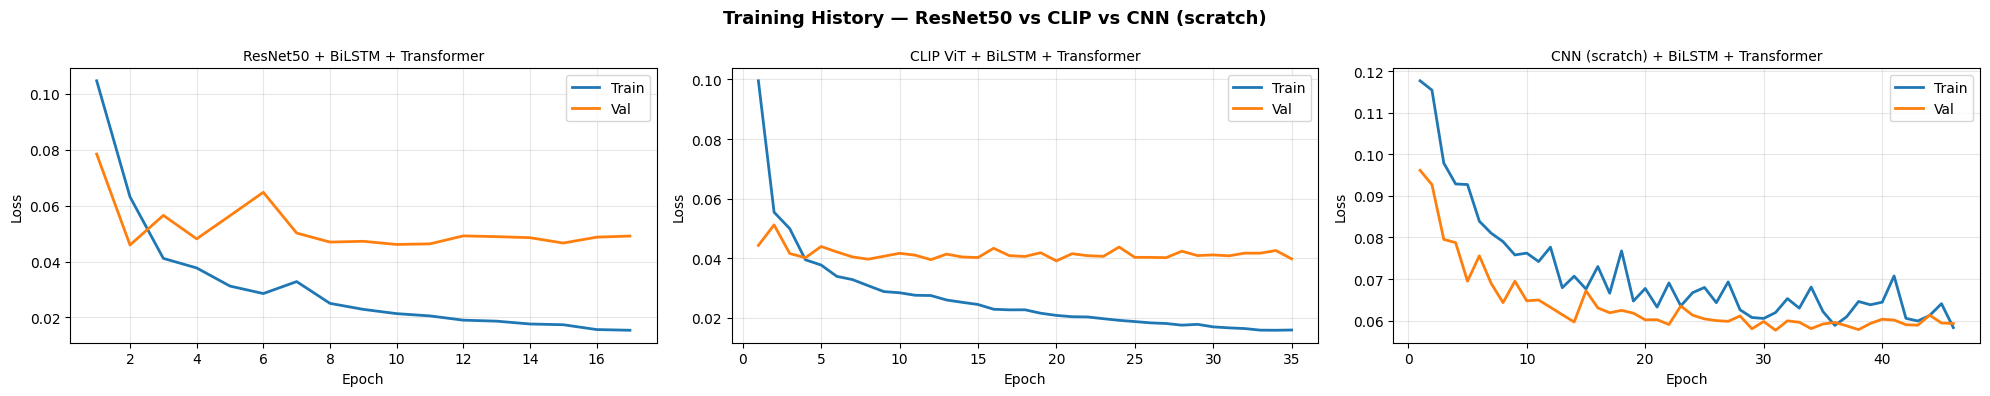

In [ ]:
import json as _json, os as _os

_hist_path = _os.path.join(LOCAL_MODELS_DIR, 'training_histories.json')
try:
    history_resnet; history_clip; history_cnn
    print("Histories already in memory.")
except NameError:
    print("Loading histories from disk...")
    with open(_hist_path) as _f:
        _h = _json.load(_f)
    history_resnet = _h['resnet']
    history_clip   = _h['clip']
    history_cnn    = _h['cnn']
    print("Histories loaded.")

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
for ax, history, title in zip(
    axes,
    [history_resnet, history_clip, history_cnn],
    ['ResNet50 + BiLSTM + Transformer',
     'CLIP ViT + BiLSTM + Transformer',
     'CNN (scratch) + BiLSTM + Transformer']
):
    ep = range(1, len(history['train_loss']) + 1)
    ax.plot(ep, history['train_loss'], lw=2, label='Train')
    ax.plot(ep, history['val_loss'],   lw=2, label='Val')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training History — ResNet50 vs CLIP vs CNN (scratch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'training_curves_all_three.png'), dpi=150)
plt.show()

## Step 13: Evaluation — Spearman Correlation + AUC + MAE

- **Spearman correlation** — ranking quality of frame scores
- **AUC** — high-engagement detection as binary classification
- **MAE / MSE**

In [ ]:
def detect_dropoff_points(engagement: np.ndarray, sensitivity: float = 1.5) -> list:
    diffs = np.diff(engagement)
    negative_diffs = diffs[diffs < 0]
    if len(negative_diffs) == 0:
        return []
    threshold = np.mean(negative_diffs) - sensitivity * np.std(negative_diffs)
    return [i + 1 for i, d in enumerate(diffs) if d < threshold]

def predict_for_video_features(model, video_id, features_dir, max_seq_len, feat_dim):
    feat_path = os.path.join(features_dir, f"{video_id}.npy")
    if not os.path.exists(feat_path):
        return None, None

    features = np.load(feat_path).astype(np.float32)
    labels = video_scores[video_id]['gtscore']
    label_idx = np.linspace(0, len(labels)-1, len(features), dtype=int)
    labels_aligned = labels[label_idx]
    T = len(features)

    if T >= max_seq_len:
        features = features[:max_seq_len]
        labels_aligned = labels_aligned[:max_seq_len]
    else:
        pad = max_seq_len - T
        features = np.vstack([features, np.zeros((pad, feat_dim), np.float32)])
        labels_aligned = np.concatenate([labels_aligned, np.zeros(pad)])

    pred = model(tf.expand_dims(features, 0), training=False).numpy().squeeze(0)
    n = min(T, len(pred))
    return pred[:n], labels_aligned[:n]

def predict_for_video_frames(model, video_id, max_seq_len):
    IMG_SIZE_CNN = 64
    video_frame_dir = os.path.join(FRAMES_DIR, video_id)
    if not os.path.exists(video_frame_dir):
        return None, None

    frame_files = sorted(os.listdir(video_frame_dir))[:max_seq_len]
    if not frame_files:
        return None, None

    frames = []
    for ff in frame_files:
        bgr = cv2.imread(os.path.join(video_frame_dir, ff))
        if bgr is None: continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (IMG_SIZE_CNN, IMG_SIZE_CNN))
        frames.append(rgb.astype(np.float32) / 255.0)

    if len(frames) == 0:
        return None, None

    frames = np.stack(frames)
    labels = video_scores[video_id]['gtscore']
    label_idx = np.linspace(0, len(labels)-1, len(frames), dtype=int)
    labels_aligned = labels[label_idx]
    T = len(frames)

    if T >= max_seq_len:
        frames = frames[:max_seq_len]
        labels_aligned = labels_aligned[:max_seq_len]
    else:
        pad = max_seq_len - T
        frames = np.concatenate([
            frames, np.zeros((pad, IMG_SIZE_CNN, IMG_SIZE_CNN, 3), np.float32)
        ], axis=0)
        labels_aligned = np.concatenate([labels_aligned, np.zeros(pad)])

    pred = model(tf.expand_dims(frames, 0), training=False).numpy().squeeze(0)
    n = min(T, len(pred))
    return pred[:n], labels_aligned[:n]

def evaluate_branch(model, val_ids, branch_name,
                    features_dir=None, max_seq_len=None, feat_dim=None,
                    use_frames=False):

    all_mse, all_mae, all_spear, all_auc = [], [], [], []

    for vid in val_ids:
        if use_frames:
            pred, labels = predict_for_video_frames(model, vid, max_seq_len)
        else:
            pred, labels = predict_for_video_features(
                model, vid, features_dir, max_seq_len, feat_dim)

        if pred is None:
            continue

        mse   = mean_squared_error(labels, pred)
        mae   = mean_absolute_error(labels, pred)
        # FIX 4: use [0] instead of .statistic — compatible with SciPy < 1.9
        spear = spearmanr(labels, pred)[0]

        binary_gt = (labels >= np.median(labels)).astype(int)
        try:
            auc = roc_auc_score(binary_gt, pred)
        except:
            auc = 0.5

        all_mse.append(mse); all_mae.append(mae)
        all_spear.append(spear); all_auc.append(auc)

        print(f"  {vid[:15]:<15} MSE:{mse:.4f} MAE:{mae:.4f} "
              f"Spearman:{spear:.4f} AUC:{auc:.4f}")

    print(f"\n{branch_name} Summary:")
    print(f"  Avg MSE      : {np.mean(all_mse):.4f}")
    print(f"  Avg MAE      : {np.mean(all_mae):.4f}")
    print(f"  Avg Spearman : {np.mean(all_spear):.4f}")
    print(f"  Avg AUC      : {np.mean(all_auc):.4f}")

    return {
        'mse': np.mean(all_mse), 'mae': np.mean(all_mae),
        'spearman': np.mean(all_spear), 'auc': np.mean(all_auc)
    }

best_model_r = keras.models.load_model(BEST_MODEL_RESNET, compile=False)
best_model_c = keras.models.load_model(BEST_MODEL_CLIP, compile=False)

best_model_n = build_cnn_bilstm_transformer(
    max_seq_len=WINDOW_SIZE, frame_shape=(64, 64, 3),
    cnn_feat_dim=128, hidden_size=128, num_lstm_layers=1,
    dropout=0.3, num_heads=2, ff_dim=128, name='CNN_Scratch_E2E'
)
best_model_n.load_weights(BEST_MODEL_CNN)

print("=== ResNet50 + BiLSTM + Transformer ===")
results_r = evaluate_branch(best_model_r, val_ids_r, "ResNet50",
    features_dir=LOCAL_FEATURES_RESNET, max_seq_len=MAX_SEQ_LEN_R, feat_dim=FEAT_DIM_R)

print("\n=== CLIP ViT + BiLSTM + Transformer ===")
results_c = evaluate_branch(best_model_c, val_ids_c, "CLIP",
    features_dir=LOCAL_FEATURES_CLIP, max_seq_len=MAX_SEQ_LEN_C, feat_dim=FEAT_DIM_C)

print("\n=== CNN Scratch end-to-end ===")
results_n = evaluate_branch(best_model_n, val_ids_n, "CNN (scratch)",
    max_seq_len=WINDOW_SIZE, use_frames=True)

=== ResNet50 + BiLSTM + Transformer ===
  uGu_10sucQo     MSE:0.0189 MAE:0.1024 Spearman:0.7458 AUC:0.8533
  iVt07TCkFM0     MSE:0.0564 MAE:0.1989 Spearman:0.6249 AUC:0.8746
  NyBmCxDoHJU     MSE:0.0447 MAE:0.1785 Spearman:0.4297 AUC:0.6566
  _xMr-HKMfVA     MSE:0.0567 MAE:0.1951 Spearman:-0.1498 AUC:0.4530
  0tmA_C6XwfM     MSE:0.0641 MAE:0.2123 Spearman:0.5236 AUC:0.7369
  Yi4Ij2NM7U4     MSE:0.0296 MAE:0.1418 Spearman:0.7393 AUC:0.8957
  GsAD1KT1xo8     MSE:0.0489 MAE:0.1819 Spearman:0.1969 AUC:0.5691
  91IHQYk1IQM     MSE:0.0446 MAE:0.1741 Spearman:0.5555 AUC:0.8375
  AwmHb44_ouw     MSE:0.0430 MAE:0.1706 Spearman:0.4291 AUC:0.7350
  vdmoEJ5YbrQ     MSE:0.0400 MAE:0.1591 Spearman:0.3238 AUC:0.6636

ResNet50 Summary:
  Avg MSE      : 0.0447
  Avg MAE      : 0.1715
  Avg Spearman : 0.4419
  Avg AUC      : 0.7275

=== CLIP ViT + BiLSTM + Transformer ===
  uGu_10sucQo     MSE:0.0286 MAE:0.1343 Spearman:0.6598 AUC:0.8167
  iVt07TCkFM0     MSE:0.0338 MAE:0.1581 Spearman:0.7884 AUC:0.9068

### Final Three-Way Comparison Table


===== ResNet50 vs CLIP vs CNN (scratch) =====
                          ResNet50    CLIP  CNN (scratch)
Metric                                                   
MSE (lower better)          0.0447  0.0378         0.0563
MAE (lower better)          0.1715  0.1537         0.1943
Spearman (higher better)    0.4419  0.5523         0.1134
AUC (higher better)         0.7275  0.7785         0.5572


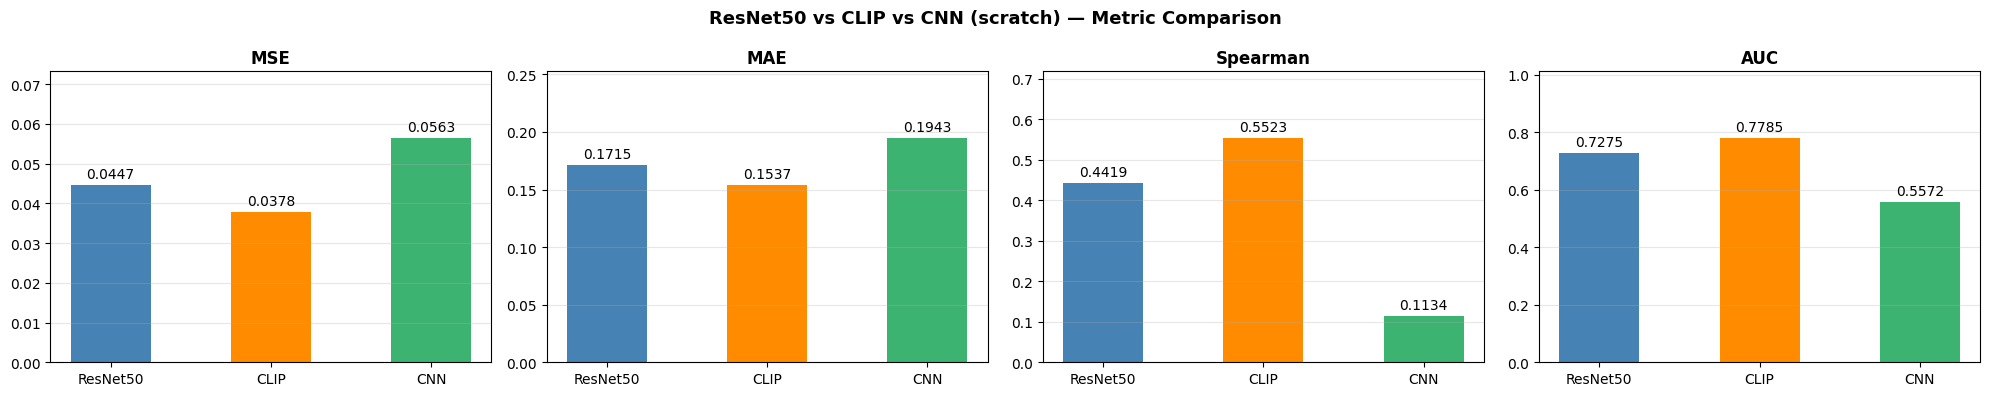

In [ ]:
comparison_df = pd.DataFrame({
    'Metric'        : ['MSE (lower better)', 'MAE (lower better)',
                       'Spearman (higher better)', 'AUC (higher better)'],
    'ResNet50'      : [results_r['mse'], results_r['mae'], results_r['spearman'], results_r['auc']],
    'CLIP'          : [results_c['mse'], results_c['mae'], results_c['spearman'], results_c['auc']],
    'CNN (scratch)' : [results_n['mse'], results_n['mae'], results_n['spearman'], results_n['auc']],
}).set_index('Metric').round(4)

print("\n===== ResNet50 vs CLIP vs CNN (scratch) =====")
print(comparison_df.to_string())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
metrics = ['mse', 'mae', 'spearman', 'auc']
labels  = ['MSE', 'MAE', 'Spearman', 'AUC']
colors  = ['steelblue', 'darkorange', 'mediumseagreen']

for ax, metric, label in zip(axes, metrics, labels):
    vals = [results_r[metric], results_c[metric], results_n[metric]]
    bars = ax.bar(['ResNet50', 'CLIP', 'CNN'], vals, color=colors, width=0.5)
    ax.set_title(label, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('ResNet50 vs CLIP vs CNN (scratch) — Metric Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'metric_comparison_all_three.png'), dpi=150)
plt.show()

## Step 14: Side-by-Side Inference Comparison — All Three Branches

Side-by-side comparison for 10 videos


uGu_10sucQo — A Year of Beekeeping
  MAE  ResNet50 : 0.1024  (335 frames)
  MAE  CLIP     : 0.1343  (335 frames)
  MAE  CNN      : 0.1795  (96 frames)


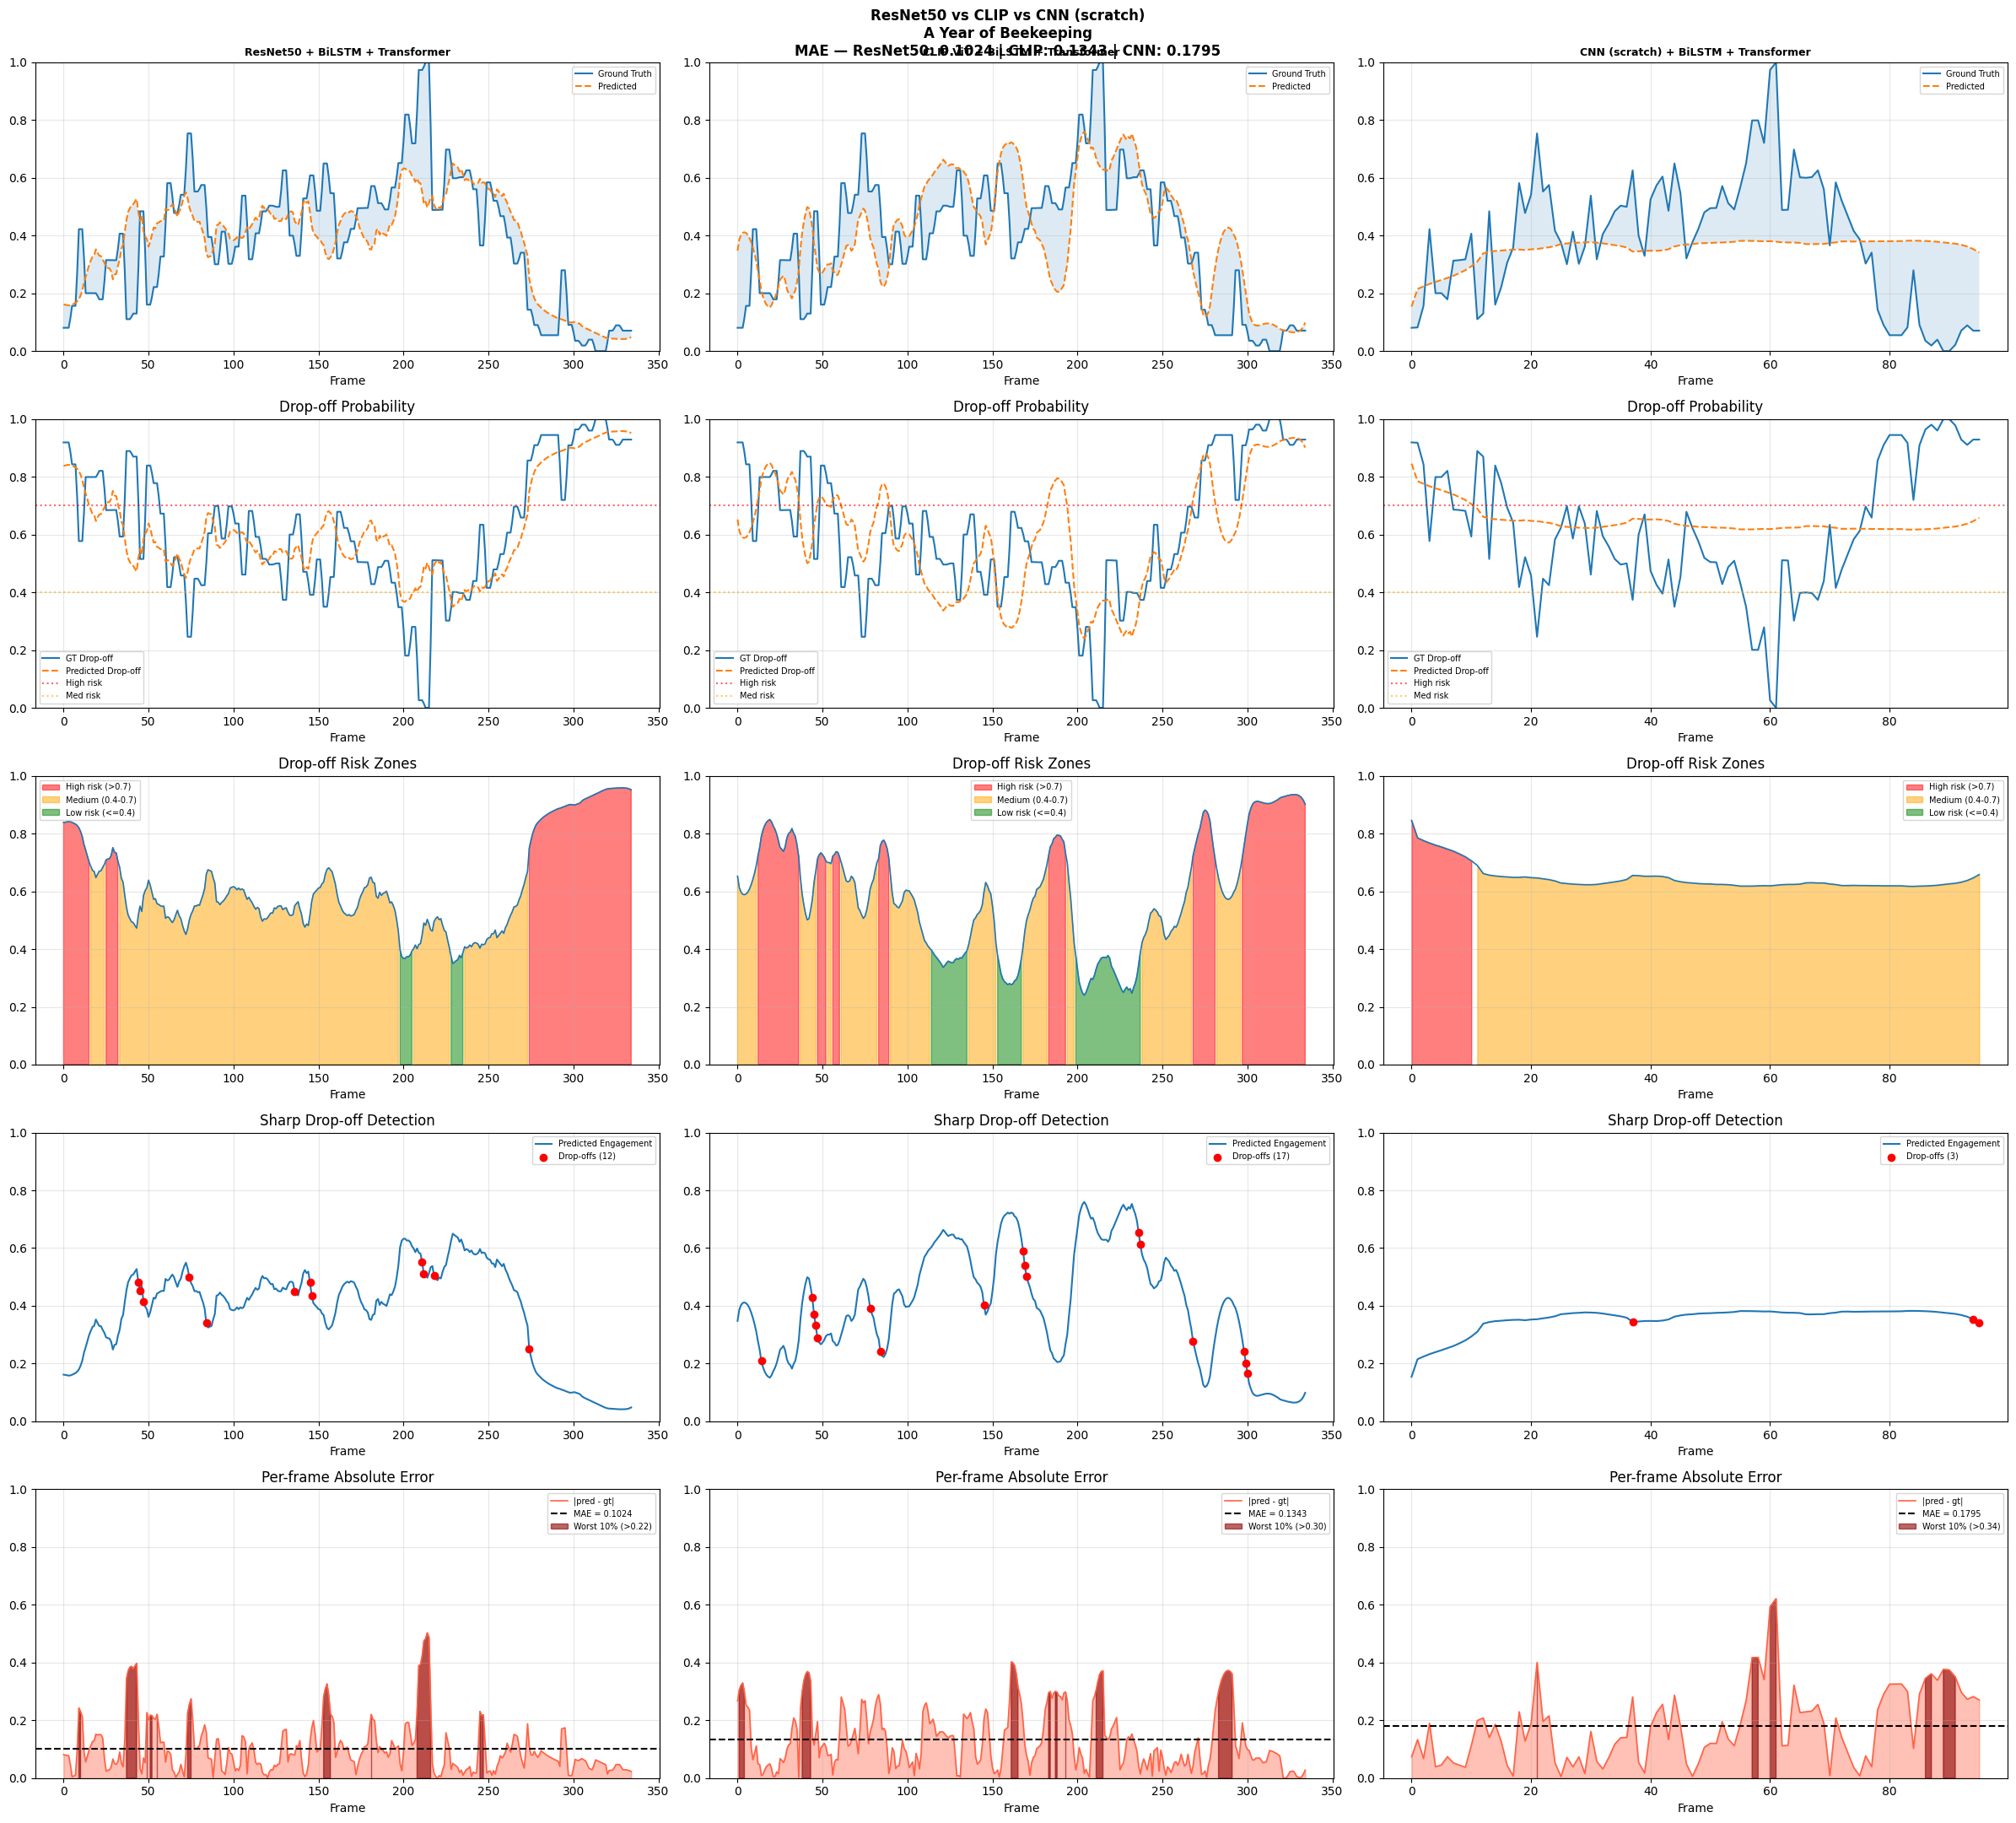

Saved: /content/VideoInsight_local/plots/uGu_10sucQo_three_branch_comparison.png

GsAD1KT1xo8 — Parkour Camp Leipzig
  MAE  ResNet50 : 0.1819  (312 frames)
  MAE  CLIP     : 0.1893  (312 frames)
  MAE  CNN      : 0.1830  (96 frames)


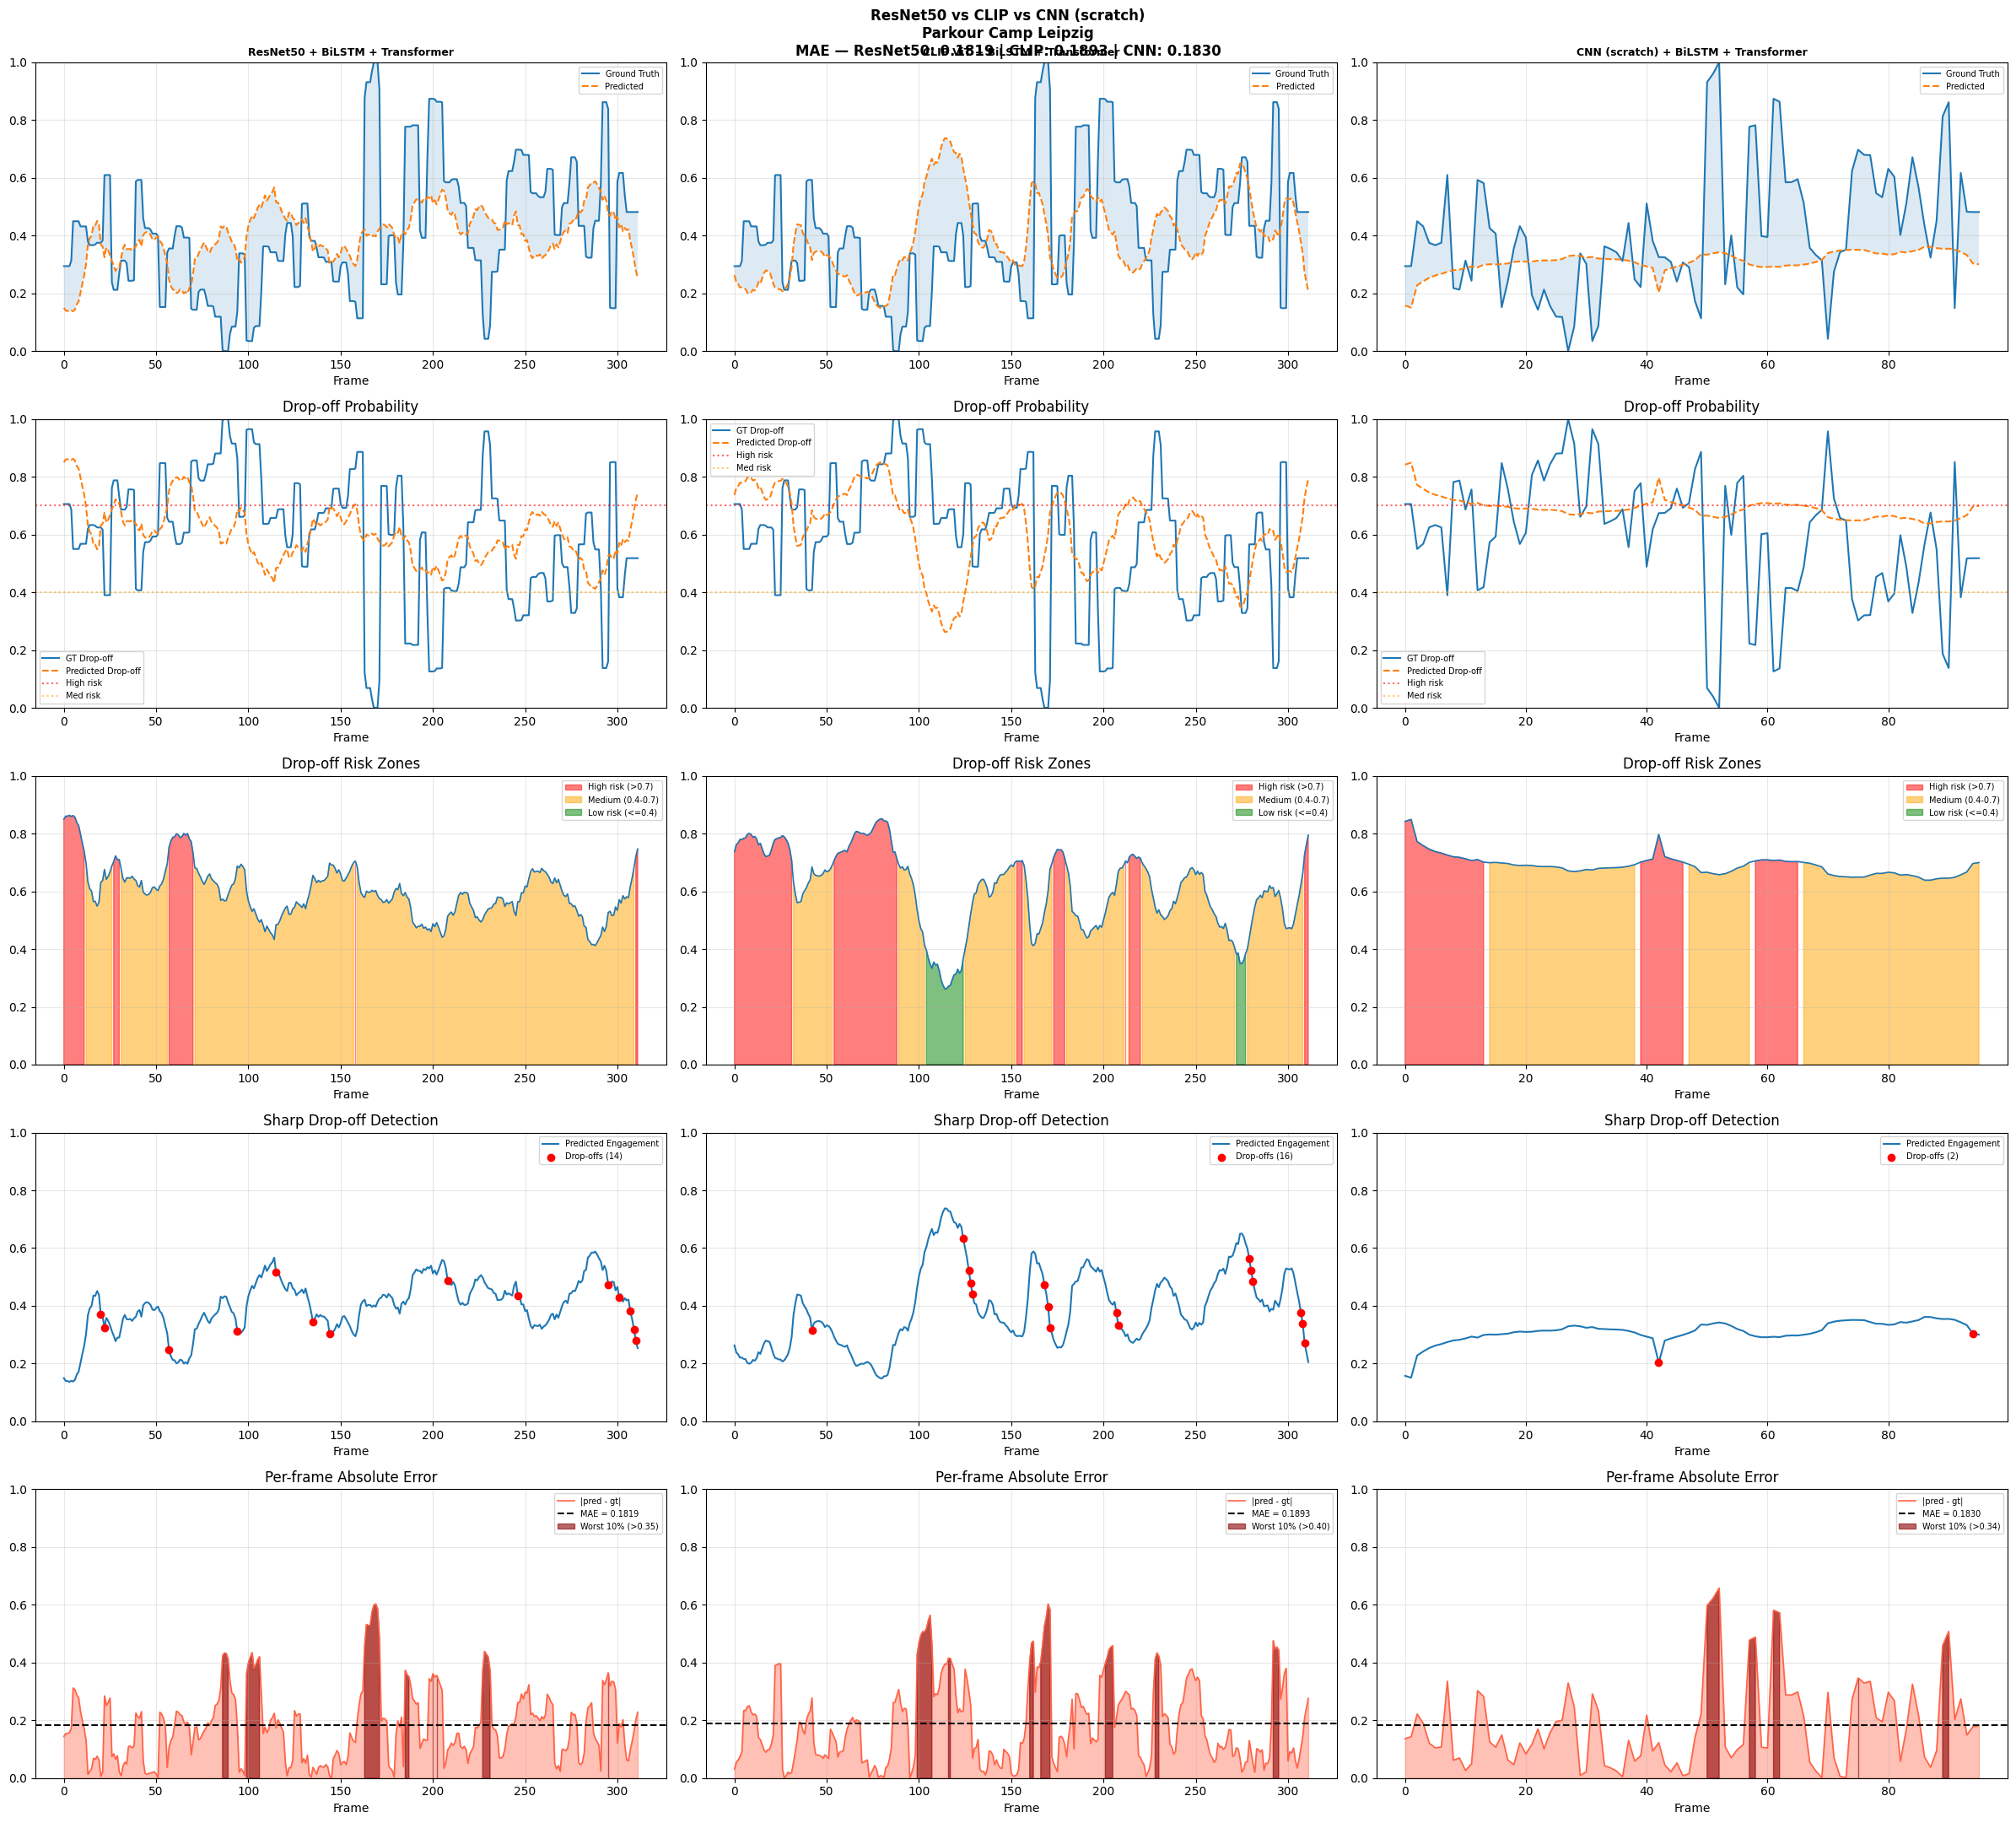

Saved: /content/VideoInsight_local/plots/GsAD1KT1xo8_three_branch_comparison.png

iVt07TCkFM0 — Pure Fix TV: How to Wheelie
  MAE  ResNet50 : 0.1989  (228 frames)
  MAE  CLIP     : 0.1581  (228 frames)
  MAE  CNN      : 0.2493  (96 frames)


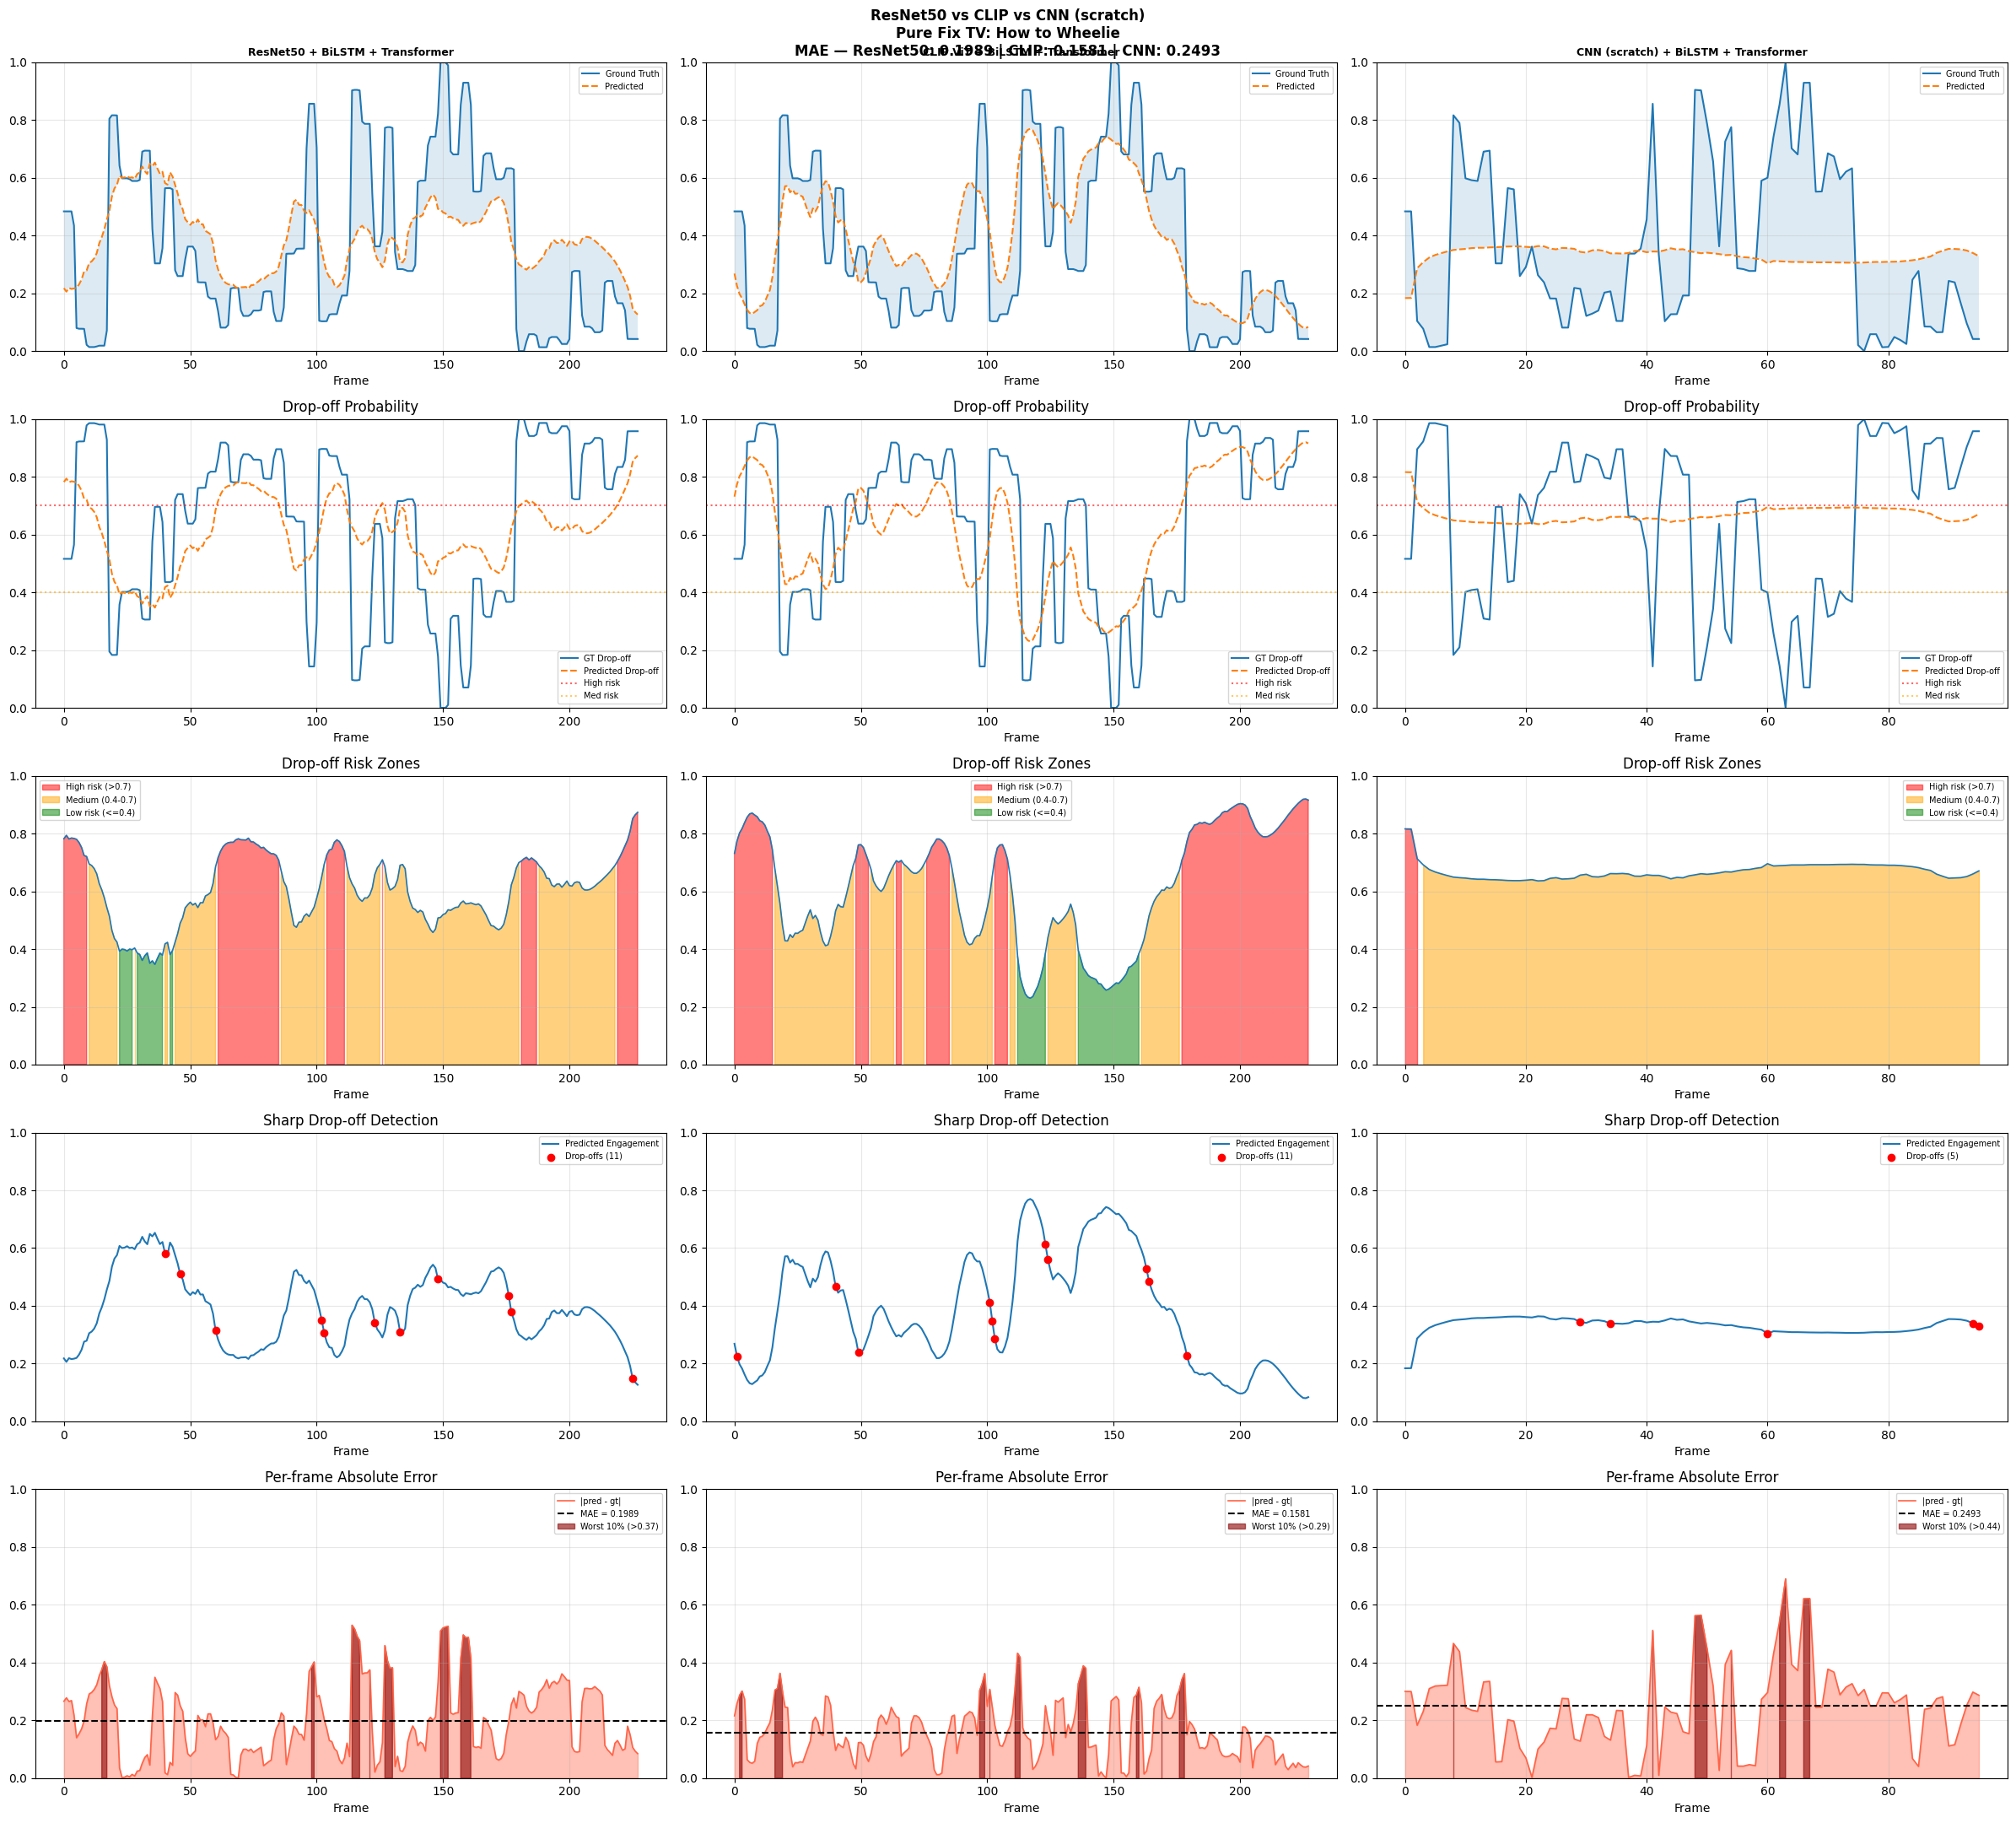

Saved: /content/VideoInsight_local/plots/iVt07TCkFM0_three_branch_comparison.png

Yi4Ij2NM7U4 — Poor Man's Meals: Spicy Sausage Sandwich
  MAE  ResNet50 : 0.1418  (668 frames)
  MAE  CLIP     : 0.1245  (668 frames)
  MAE  CNN      : 0.2208  (96 frames)


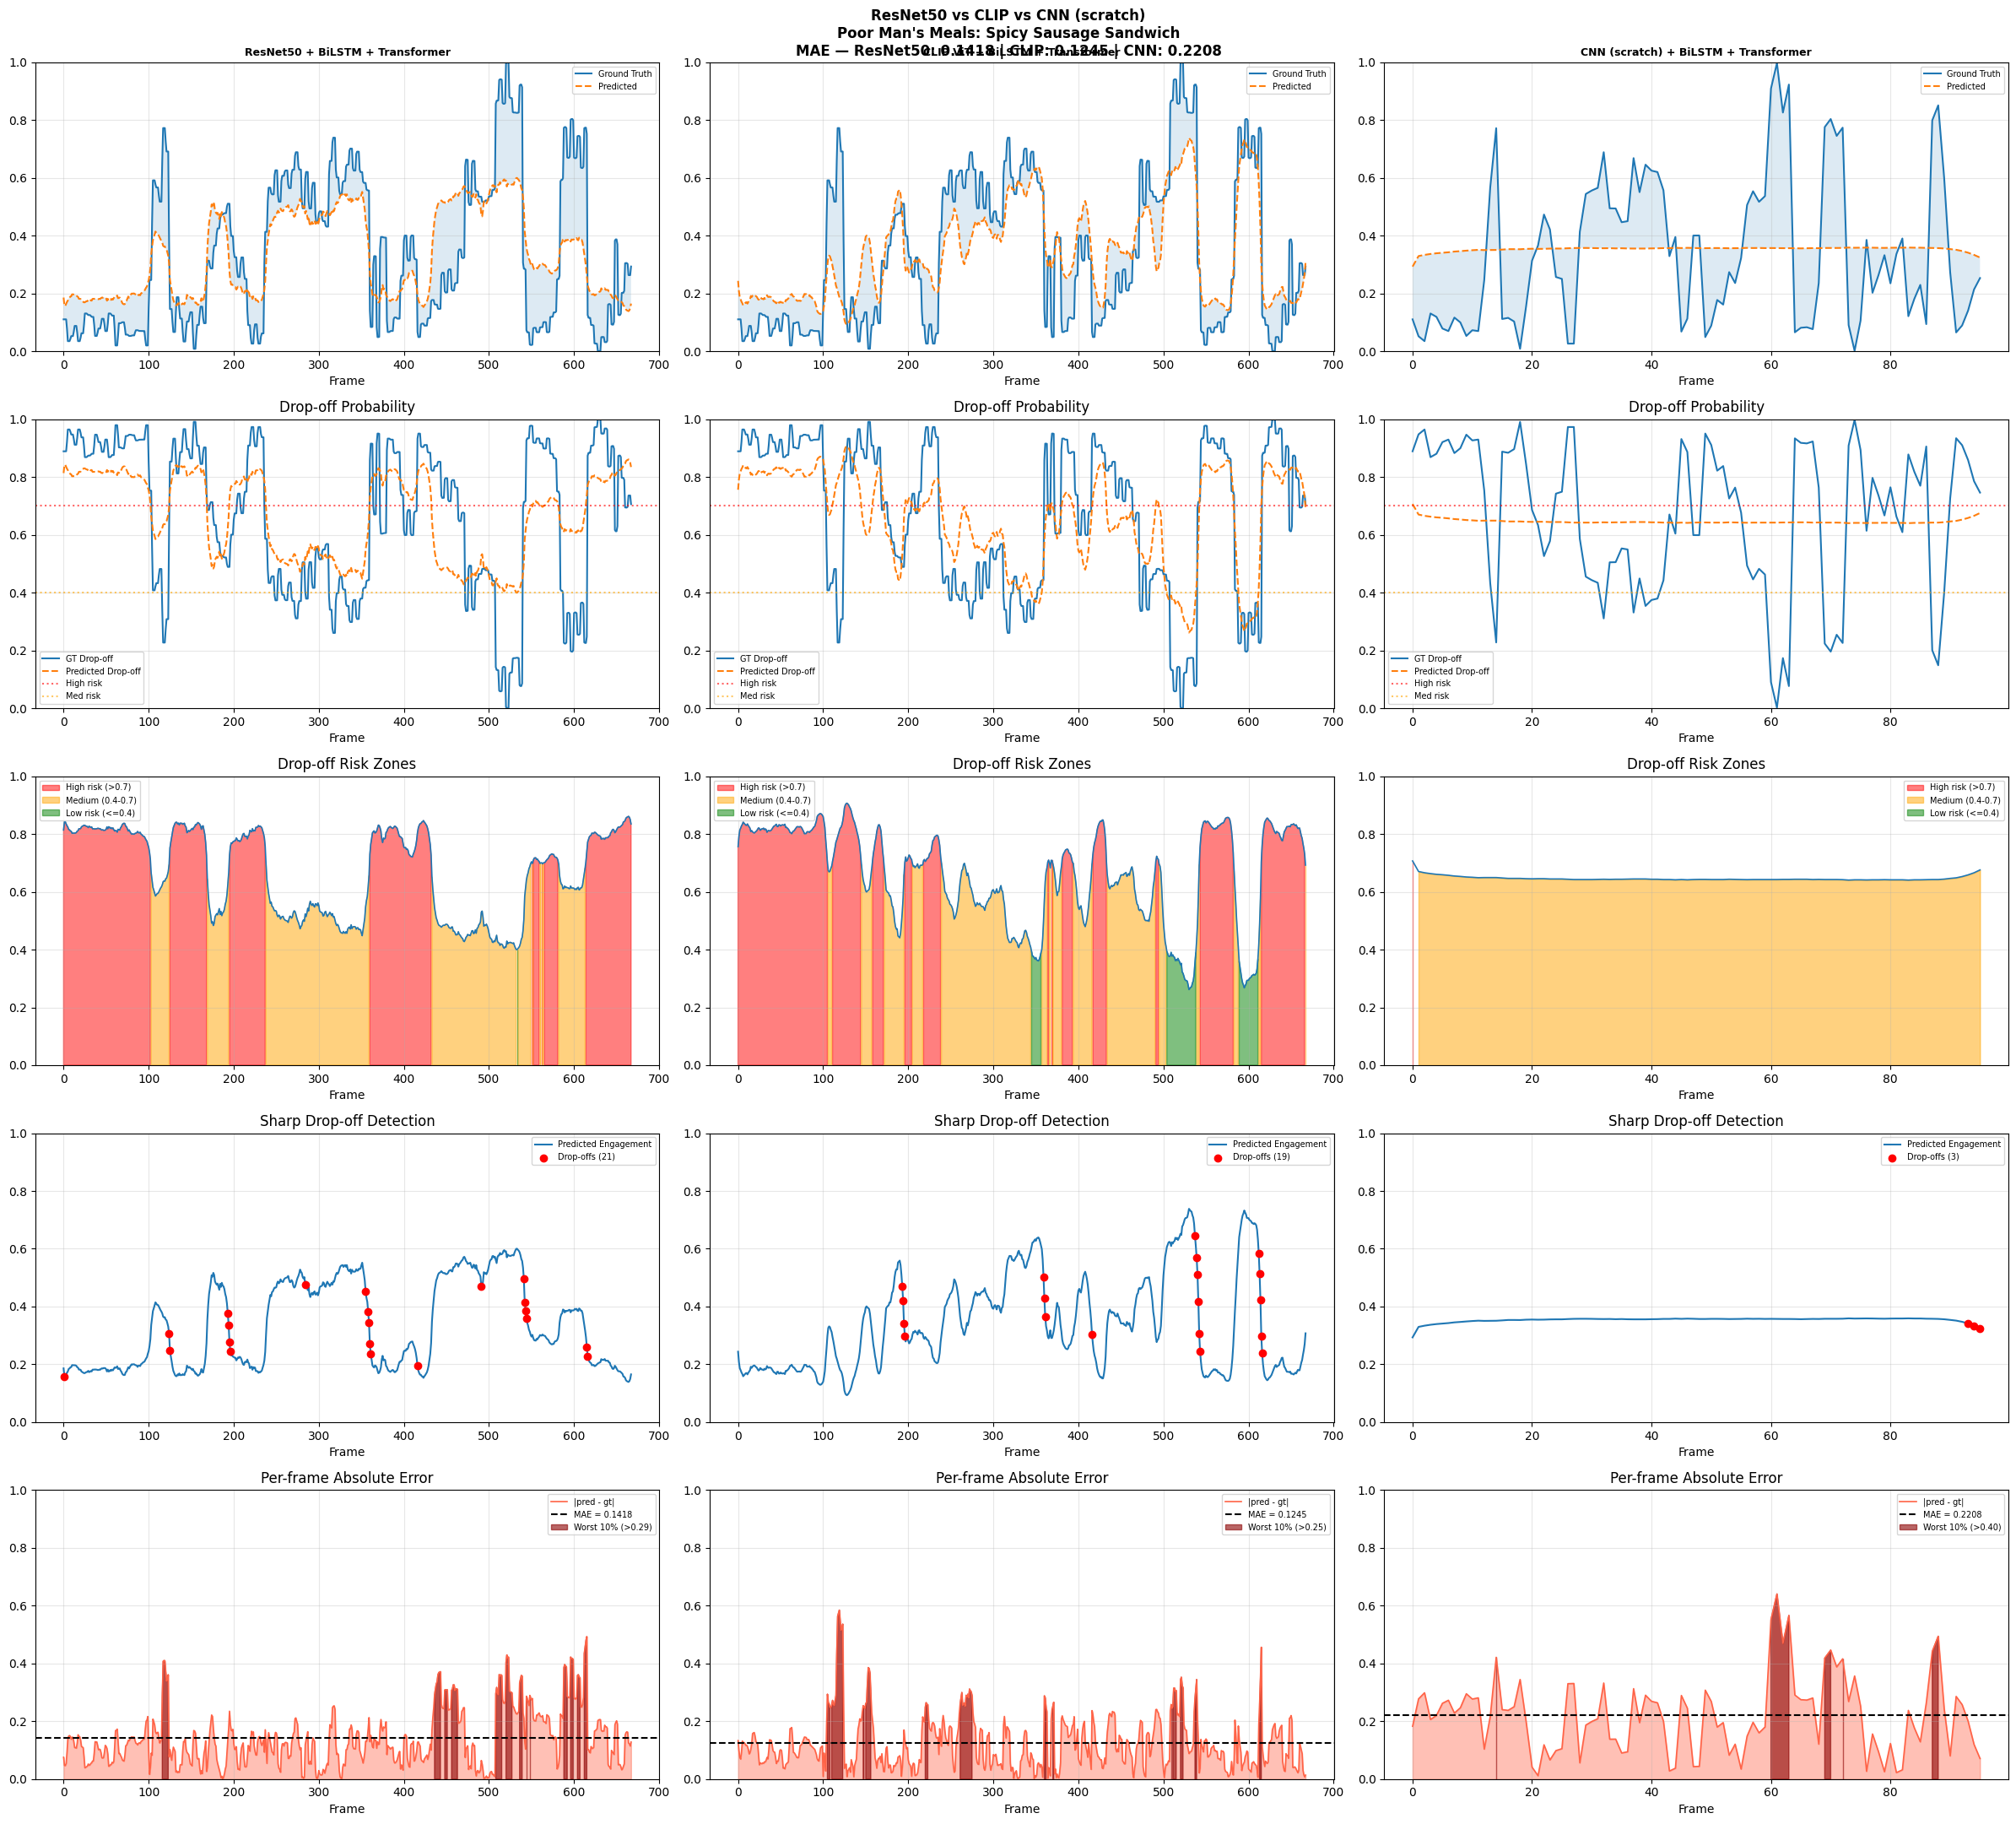

Saved: /content/VideoInsight_local/plots/Yi4Ij2NM7U4_three_branch_comparison.png

NyBmCxDoHJU — The Dog Show HD 720p
  MAE  ResNet50 : 0.1785  (395 frames)
  MAE  CLIP     : 0.1509  (395 frames)
  MAE  CNN      : 0.2216  (96 frames)


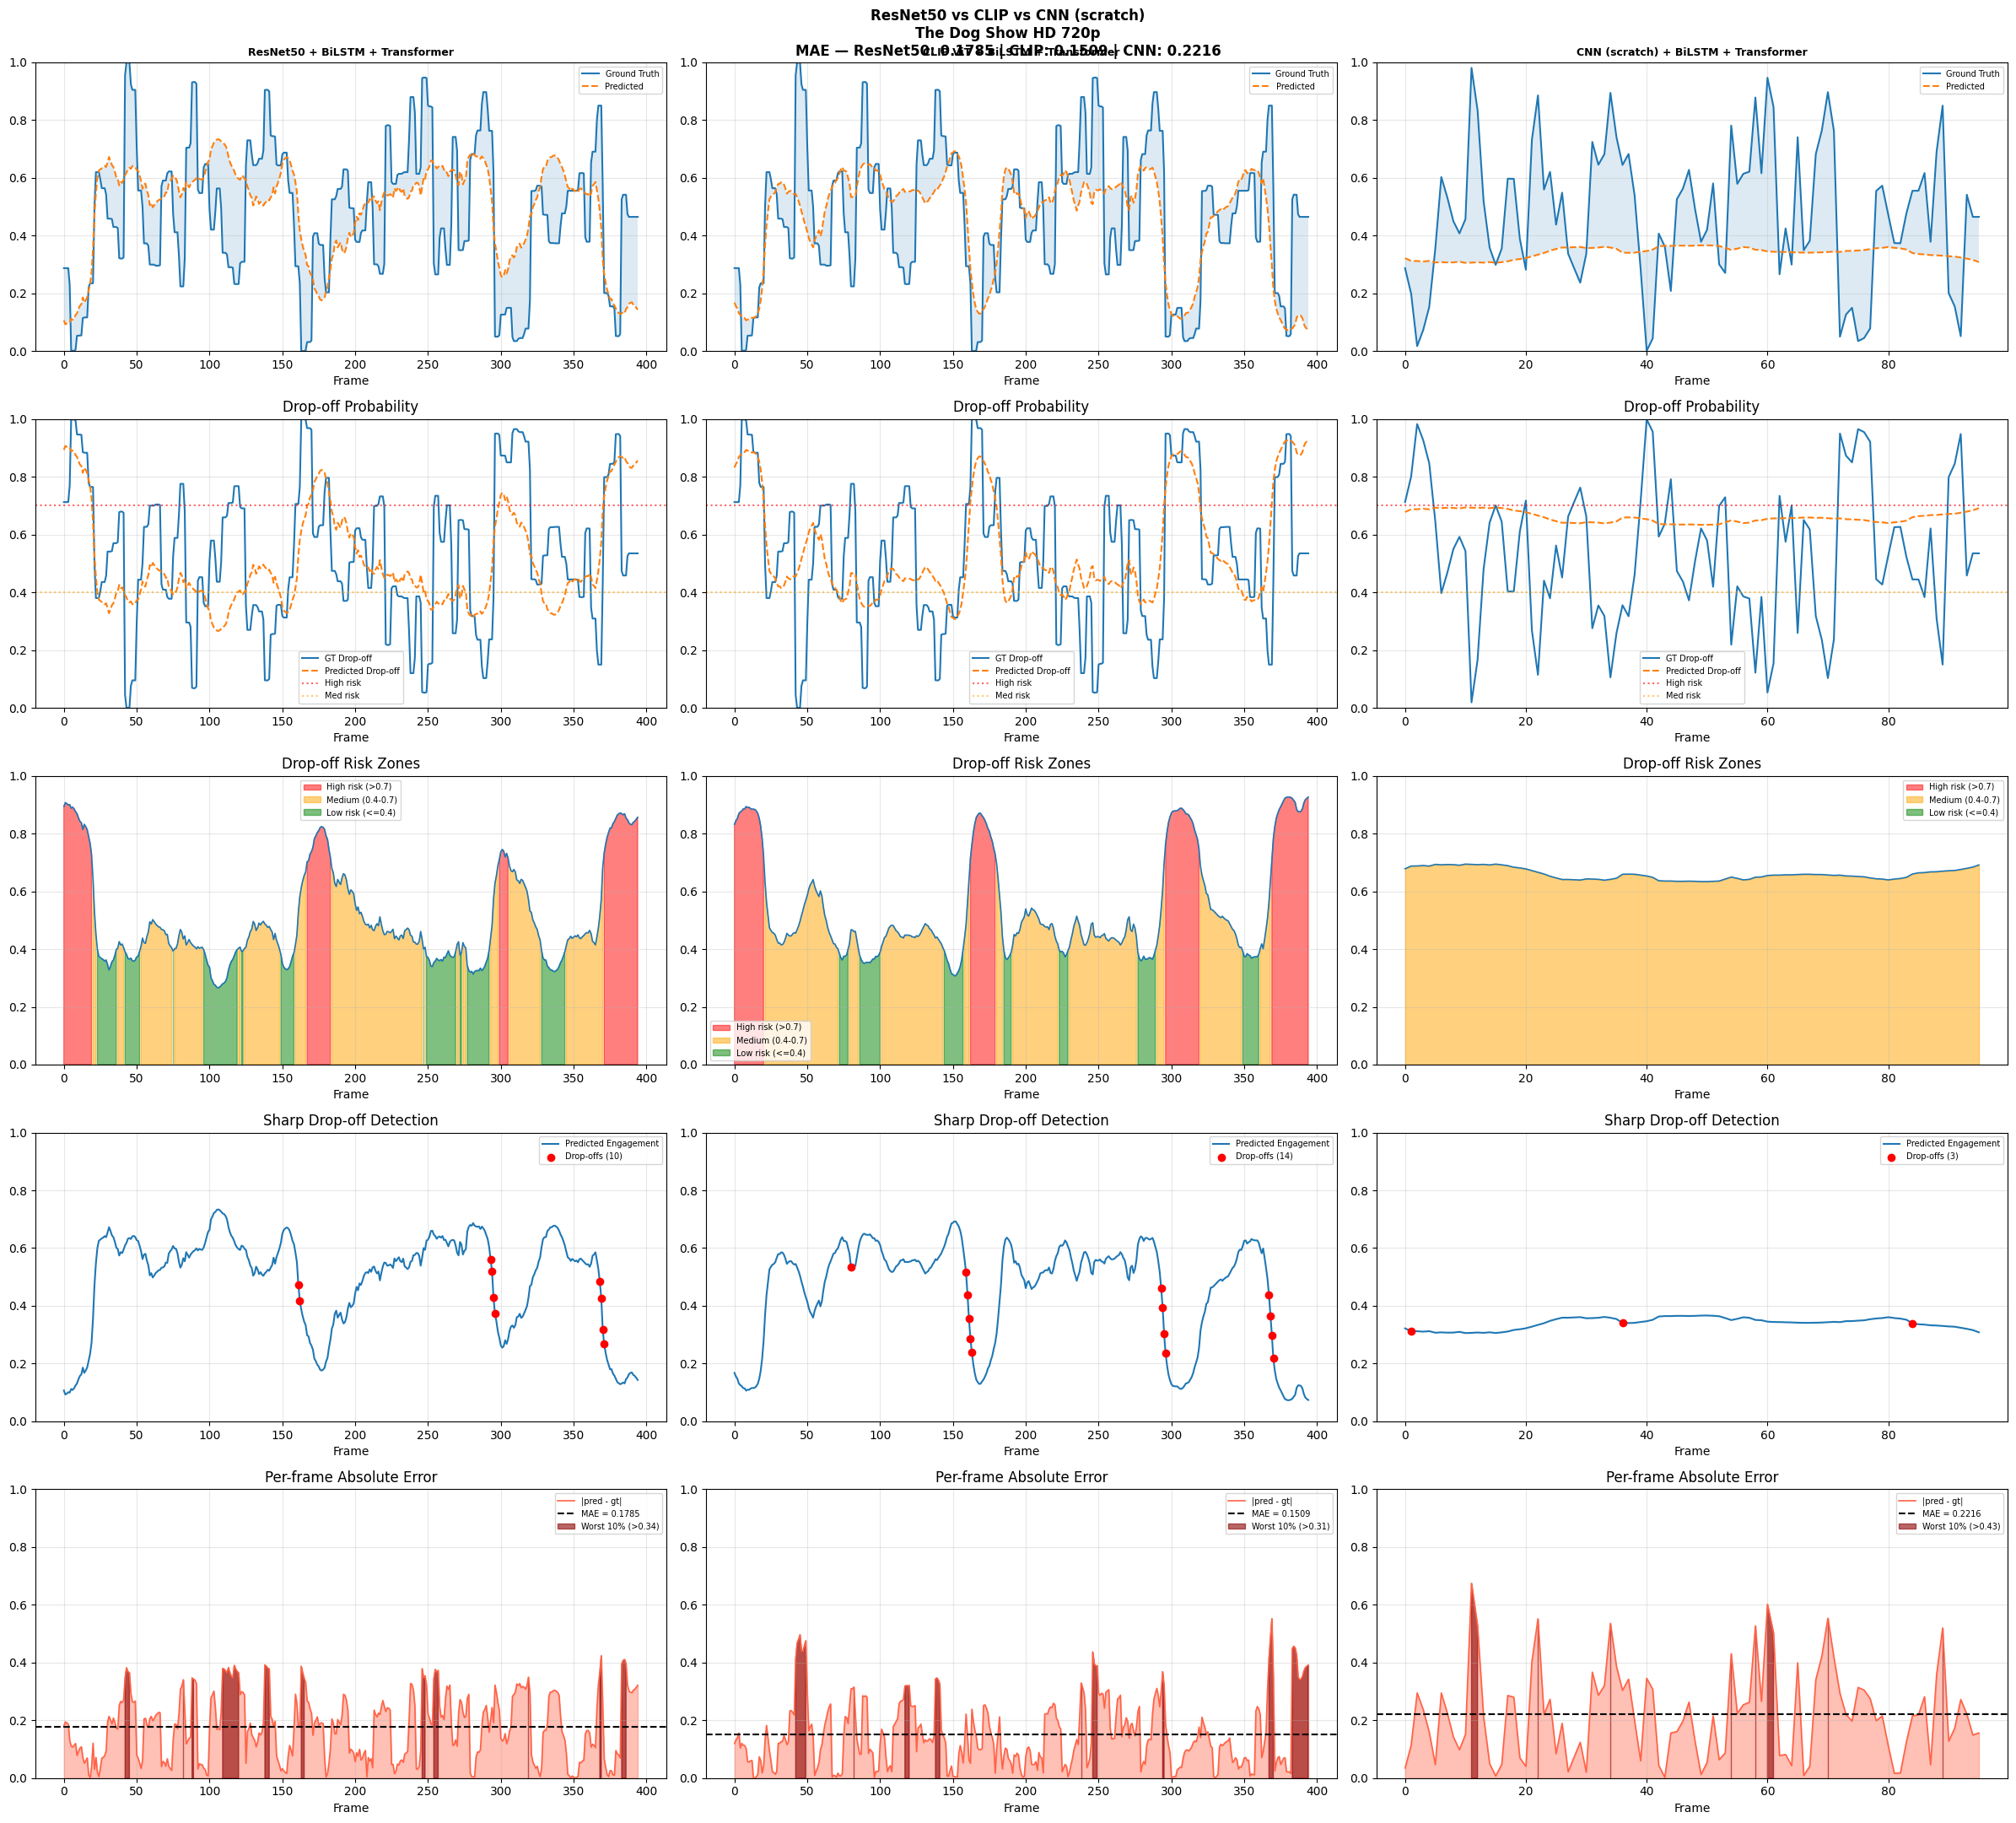

Saved: /content/VideoInsight_local/plots/NyBmCxDoHJU_three_branch_comparison.png

AwmHb44_ouw — #1306 How to change tires for off road vehicles [Davidsfarm]
  MAE  ResNet50 : 0.1706  (668 frames)
  MAE  CLIP     : 0.1457  (668 frames)
  MAE  CNN      : 0.1995  (96 frames)


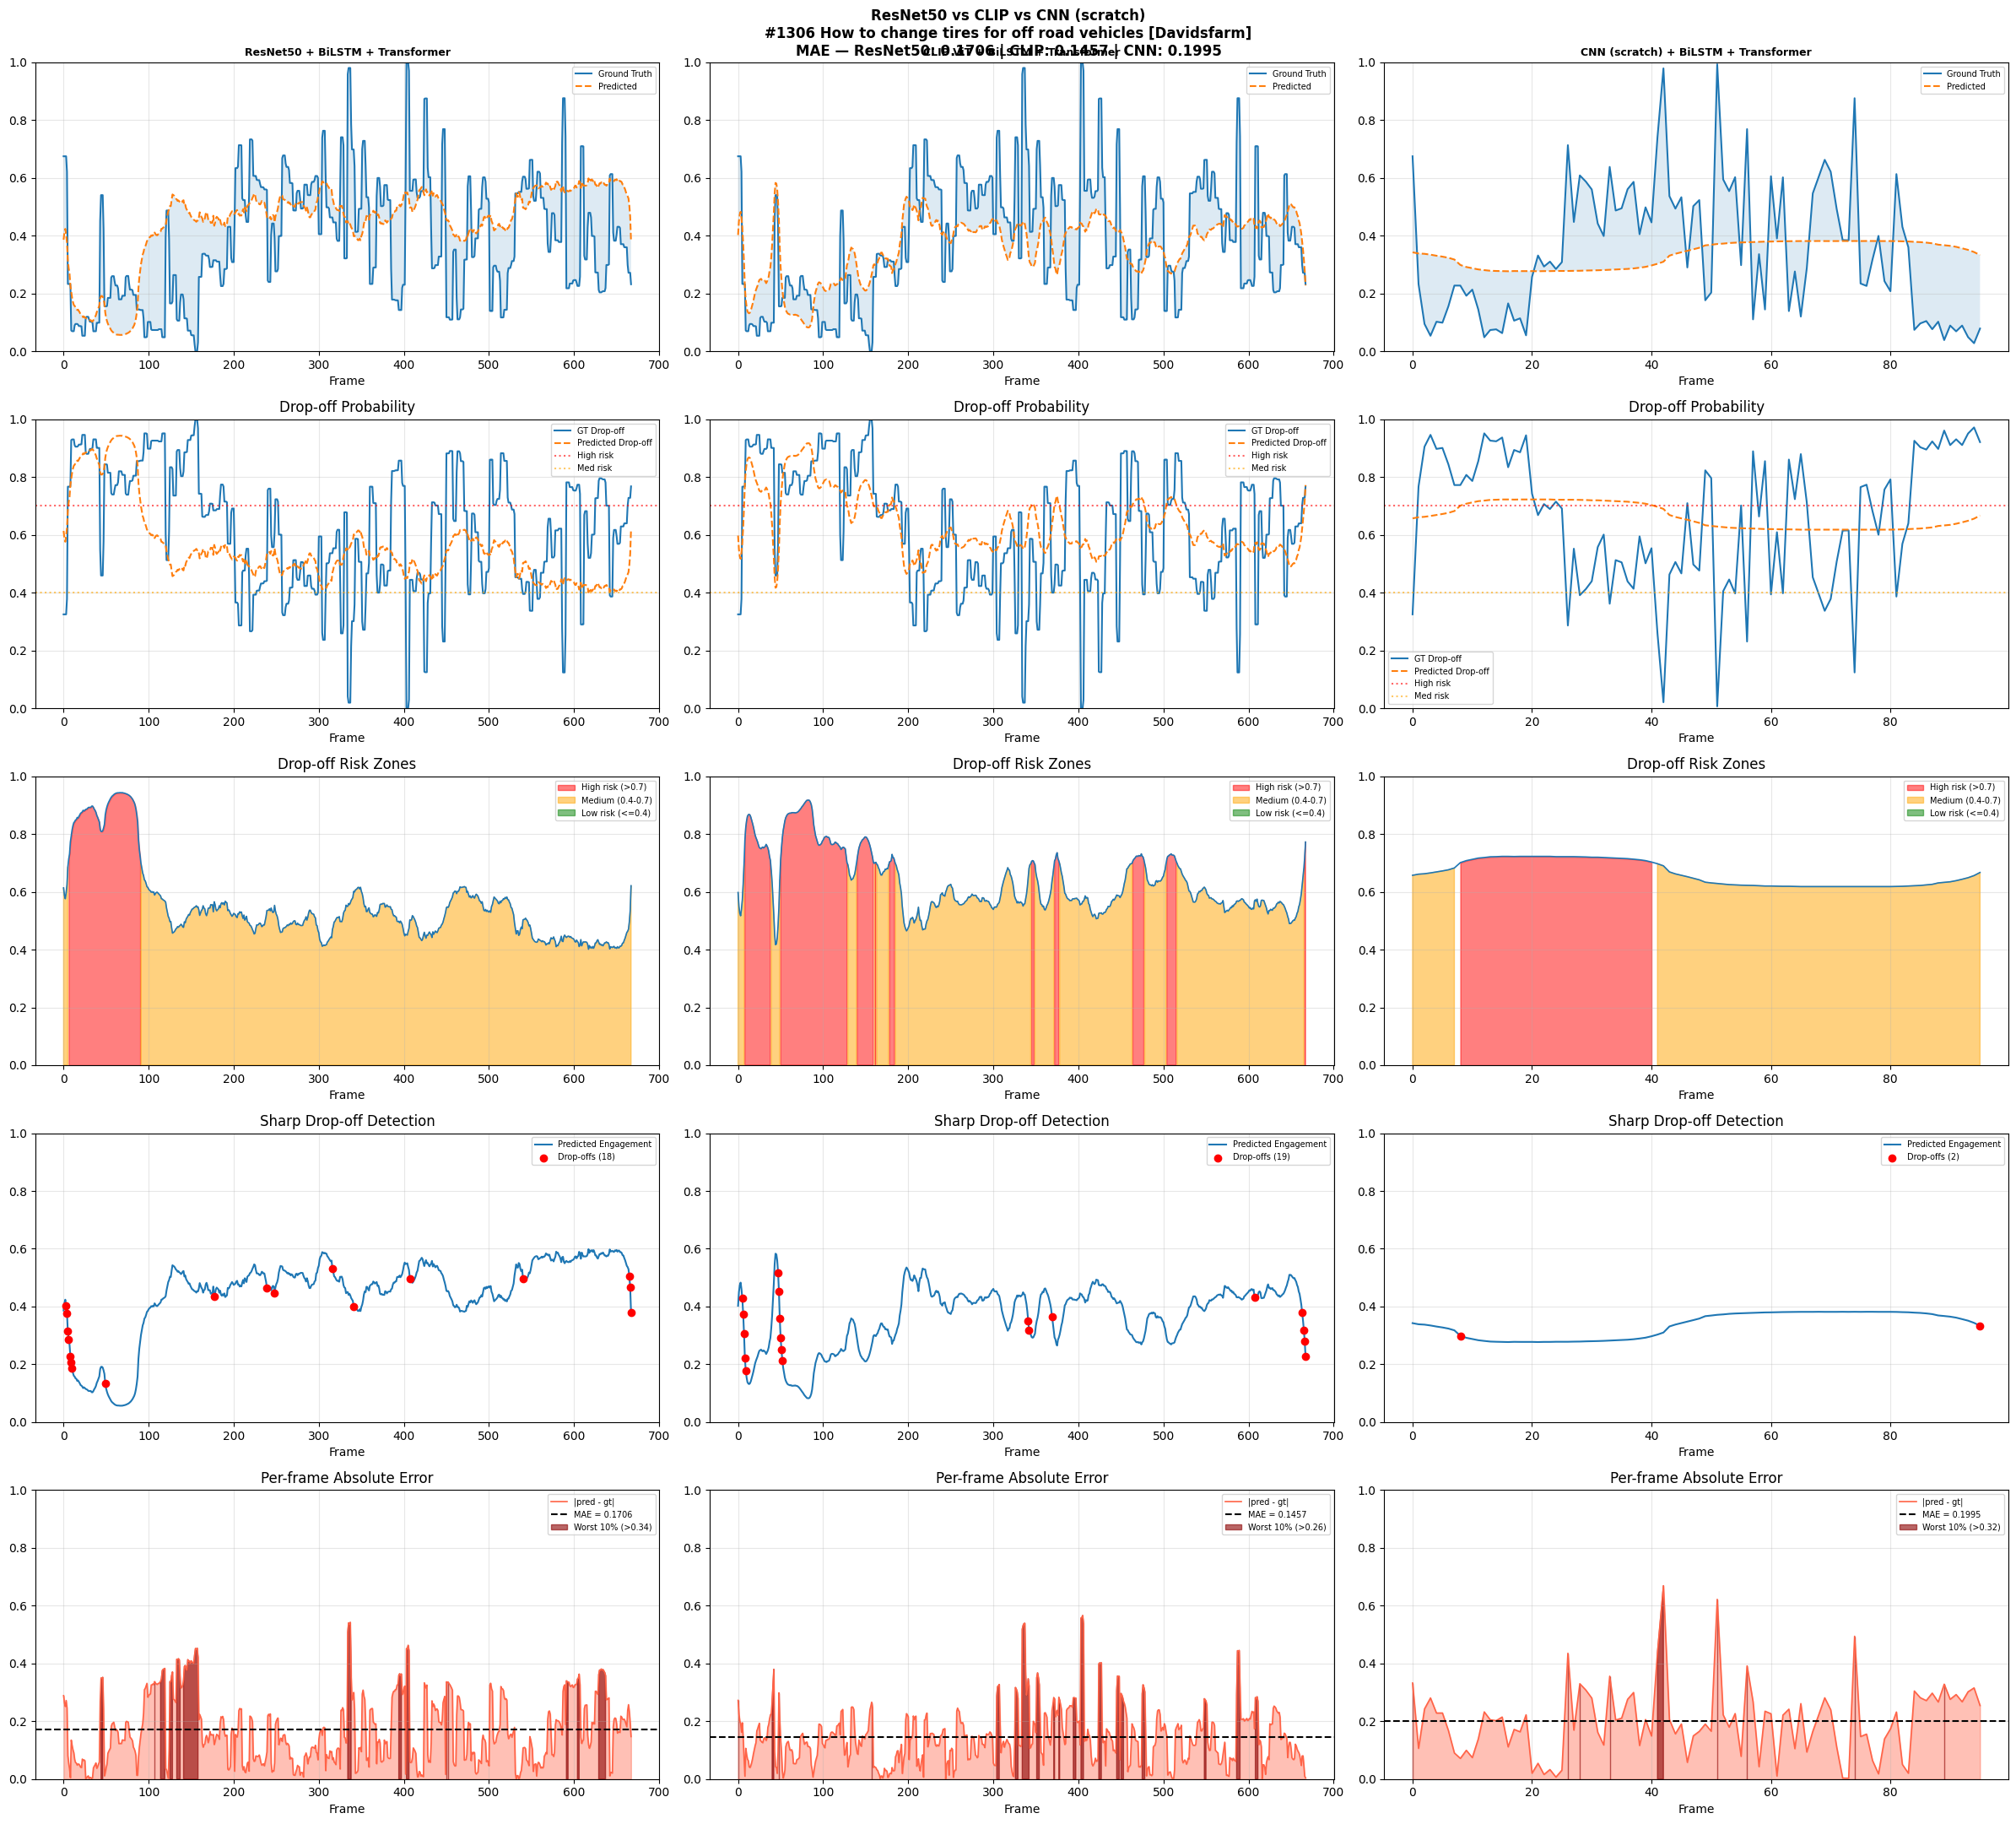

Saved: /content/VideoInsight_local/plots/AwmHb44_ouw_three_branch_comparison.png

vdmoEJ5YbrQ — #453 girl gets van stuck in the back fourty [Davidsfarm]
  MAE  ResNet50 : 0.1591  (668 frames)
  MAE  CLIP     : 0.1350  (668 frames)
  MAE  CNN      : 0.1499  (96 frames)


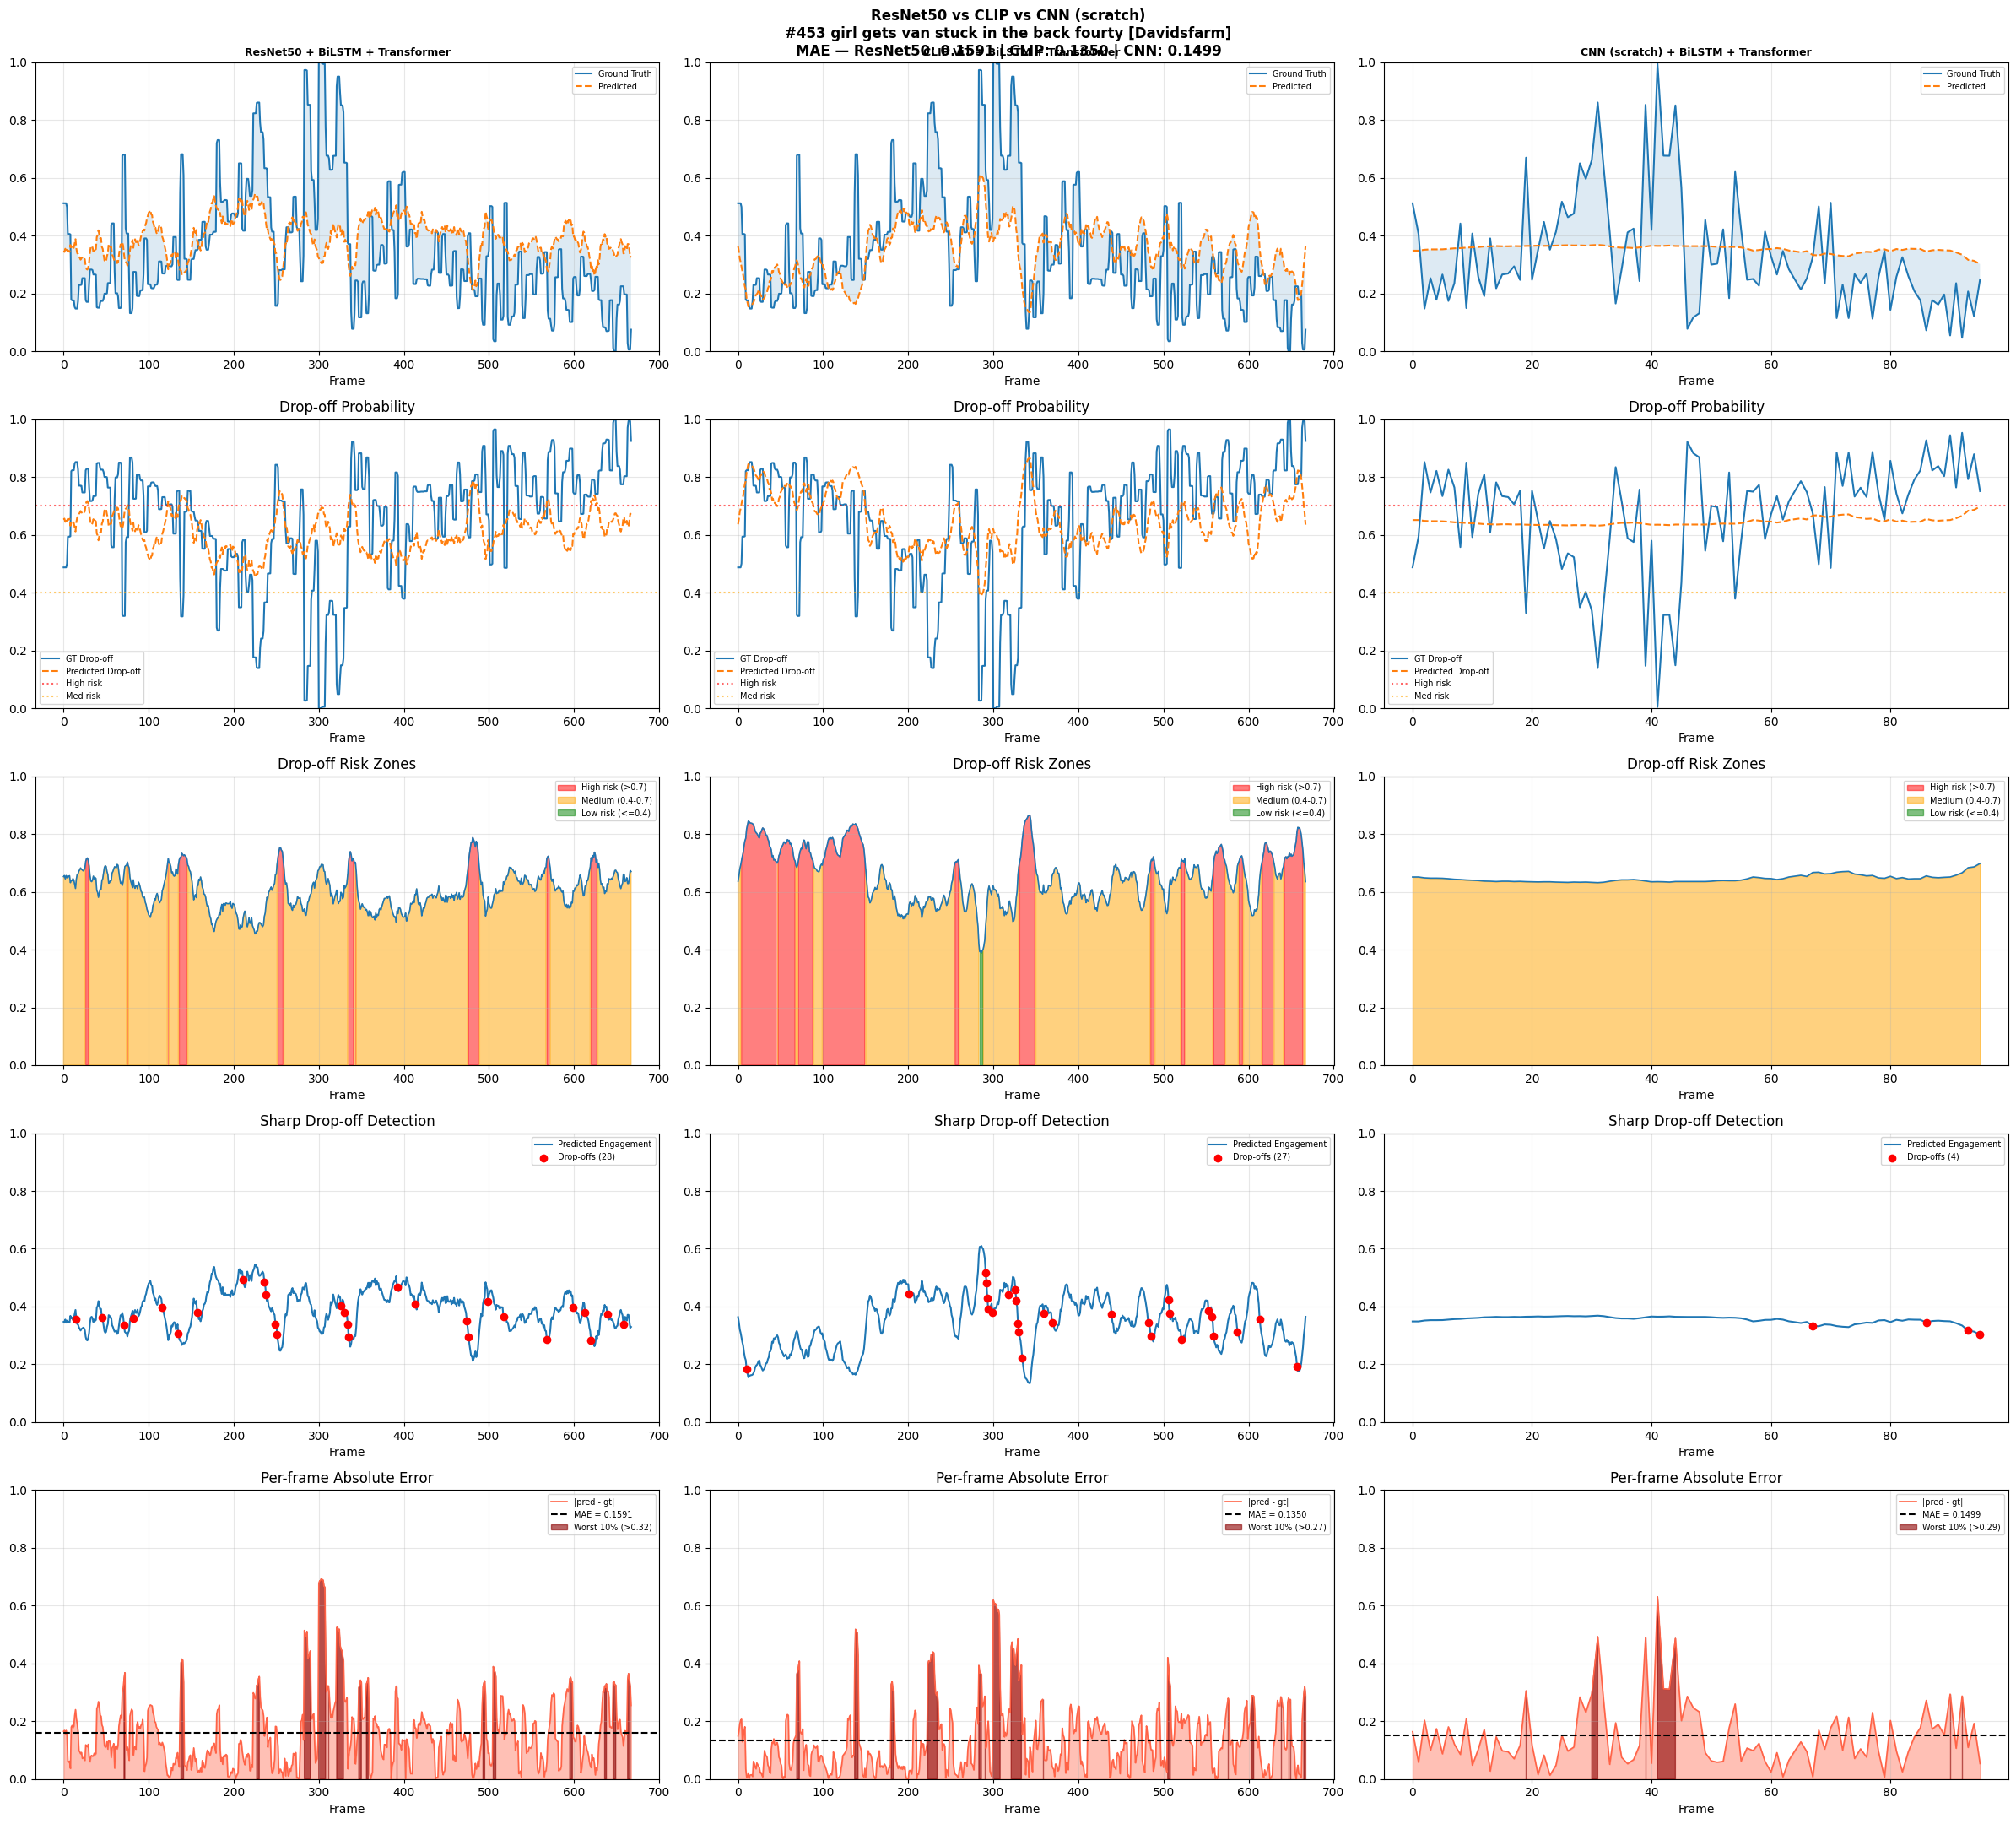

Saved: /content/VideoInsight_local/plots/vdmoEJ5YbrQ_three_branch_comparison.png

_xMr-HKMfVA — CASACL - Flashmob in Copenhagen underground - Peer Gynt
  MAE  ResNet50 : 0.1951  (319 frames)
  MAE  CLIP     : 0.1917  (319 frames)
  MAE  CNN      : 0.1688  (96 frames)


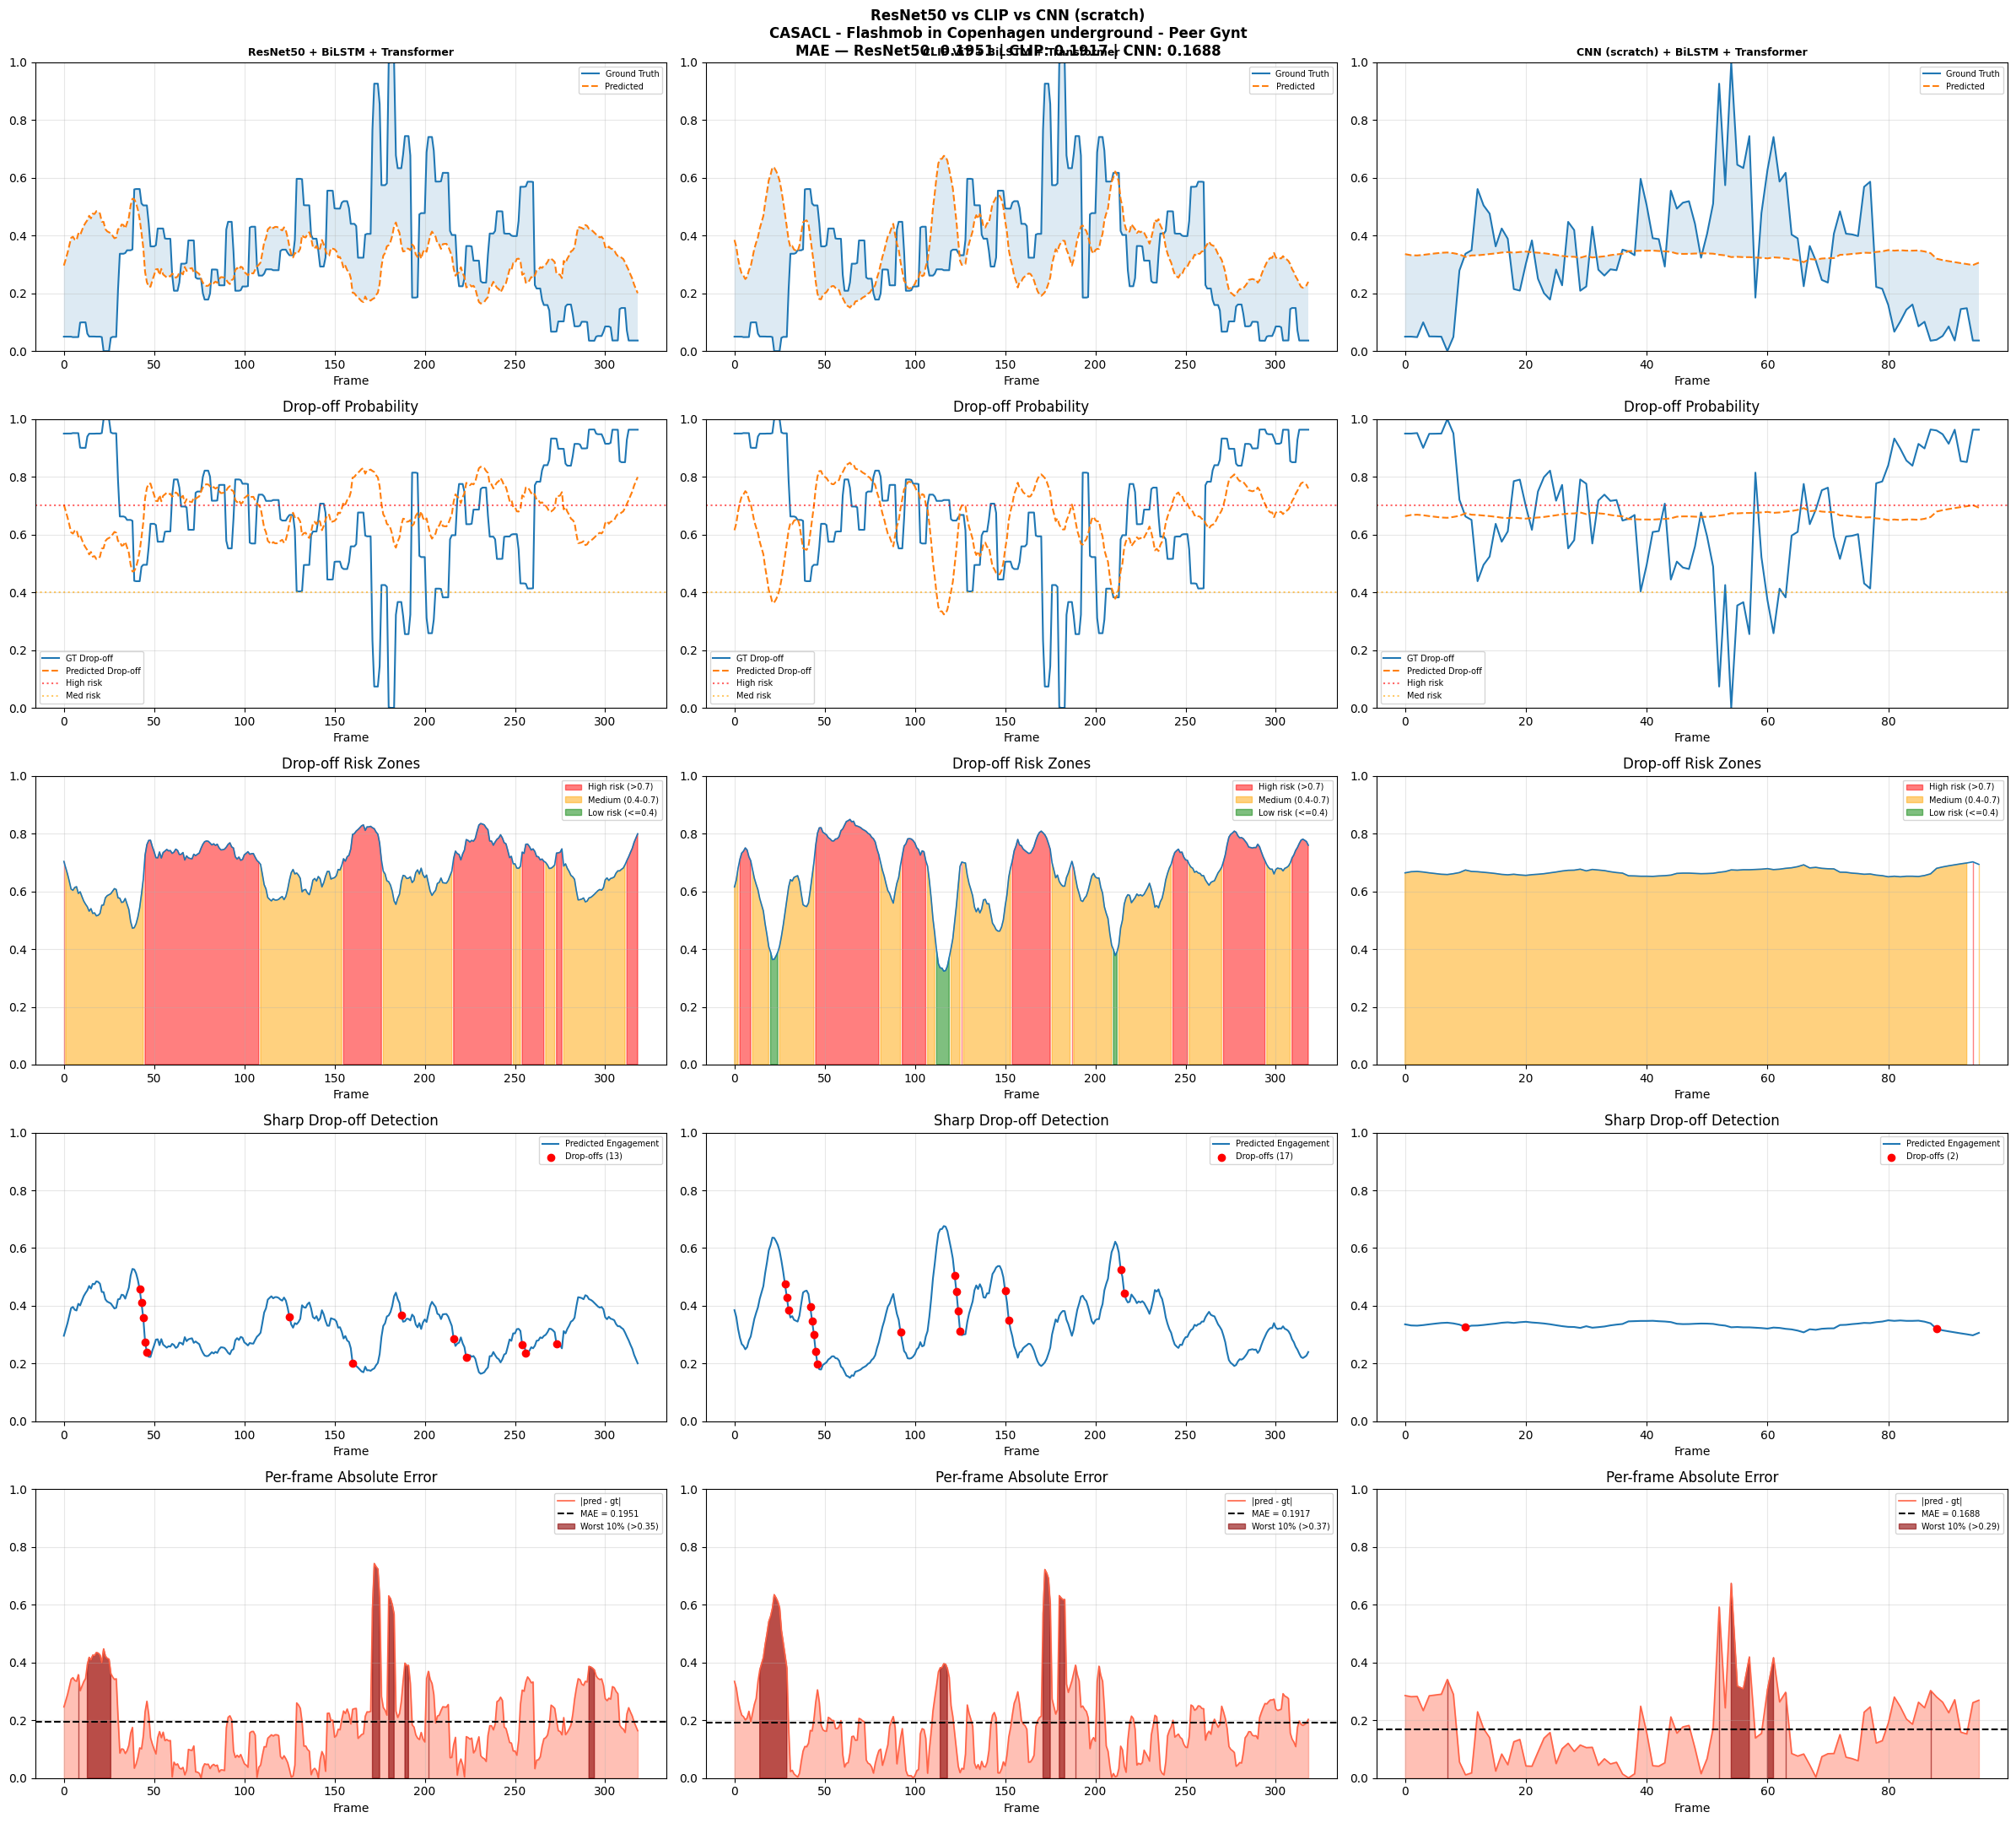

Saved: /content/VideoInsight_local/plots/_xMr-HKMfVA_three_branch_comparison.png

91IHQYk1IQM — Chinese New Year Parade 2012 New York City Chinatown
  MAE  ResNet50 : 0.1741  (237 frames)
  MAE  CLIP     : 0.1458  (237 frames)
  MAE  CNN      : 0.1655  (96 frames)


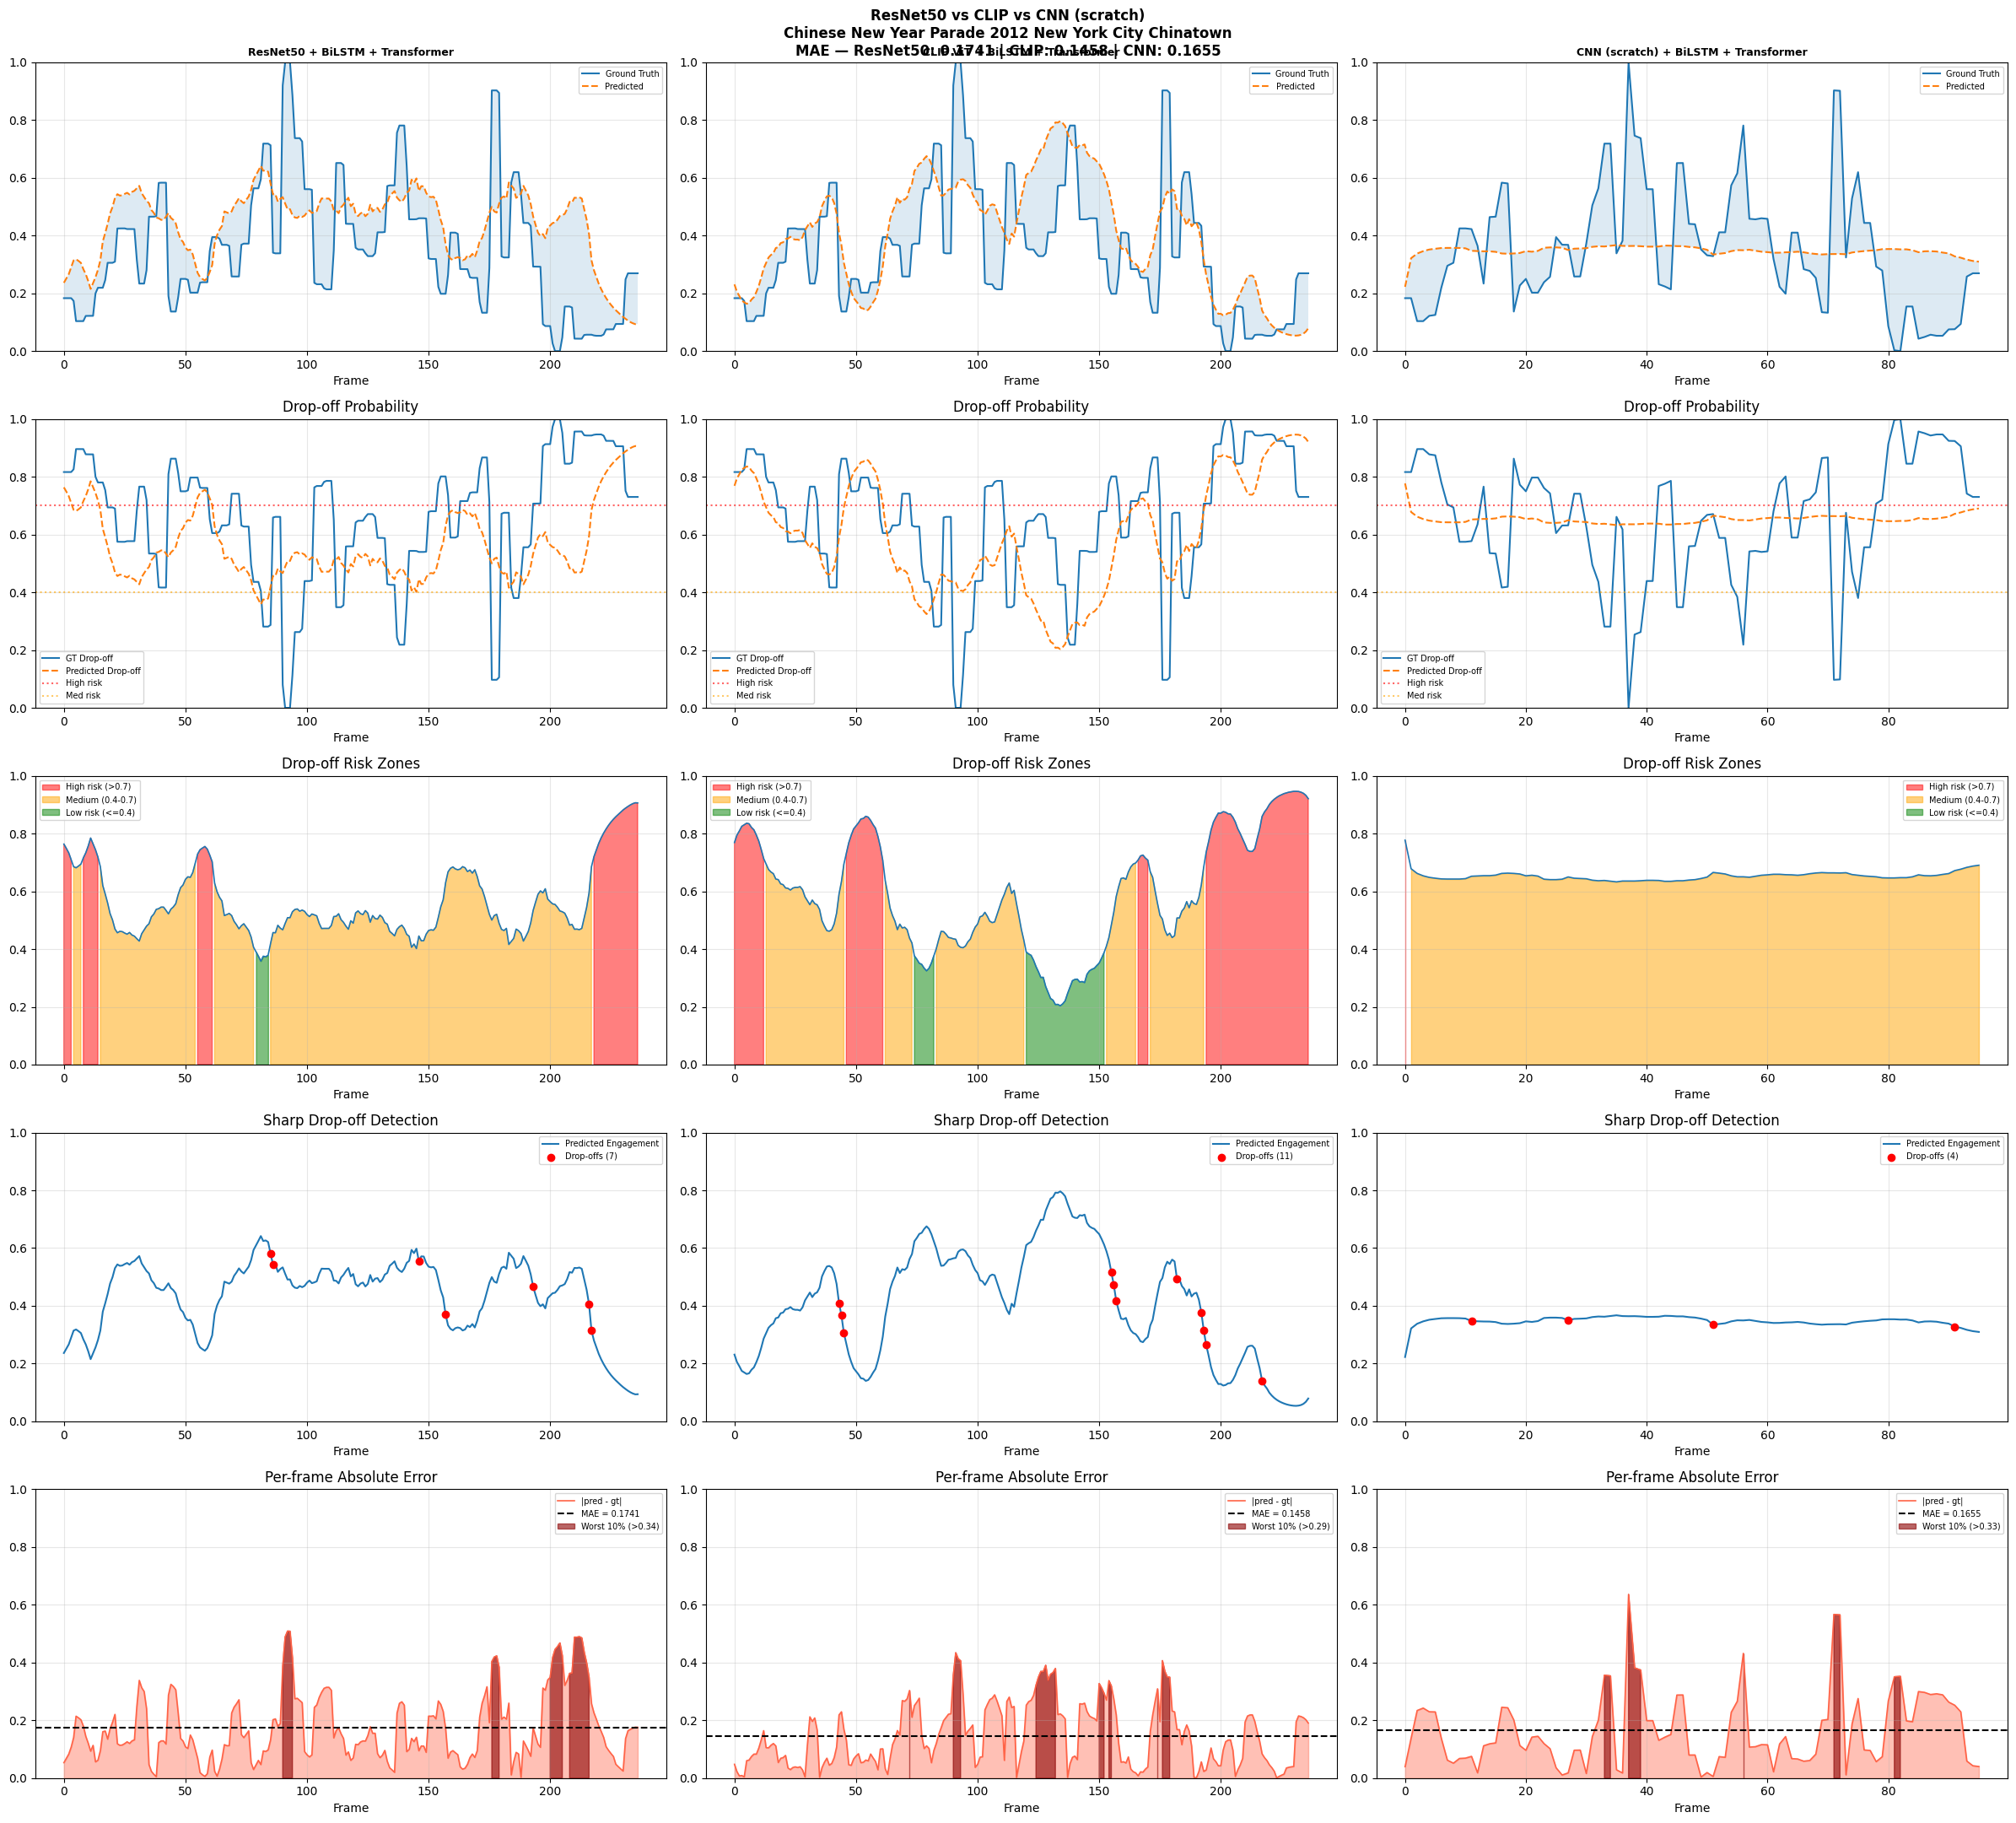

Saved: /content/VideoInsight_local/plots/91IHQYk1IQM_three_branch_comparison.png

0tmA_C6XwfM — Nail clipper Gloria Pets professional grooming
  MAE  ResNet50 : 0.2123  (295 frames)
  MAE  CLIP     : 0.1614  (295 frames)
  MAE  CNN      : 0.2052  (96 frames)


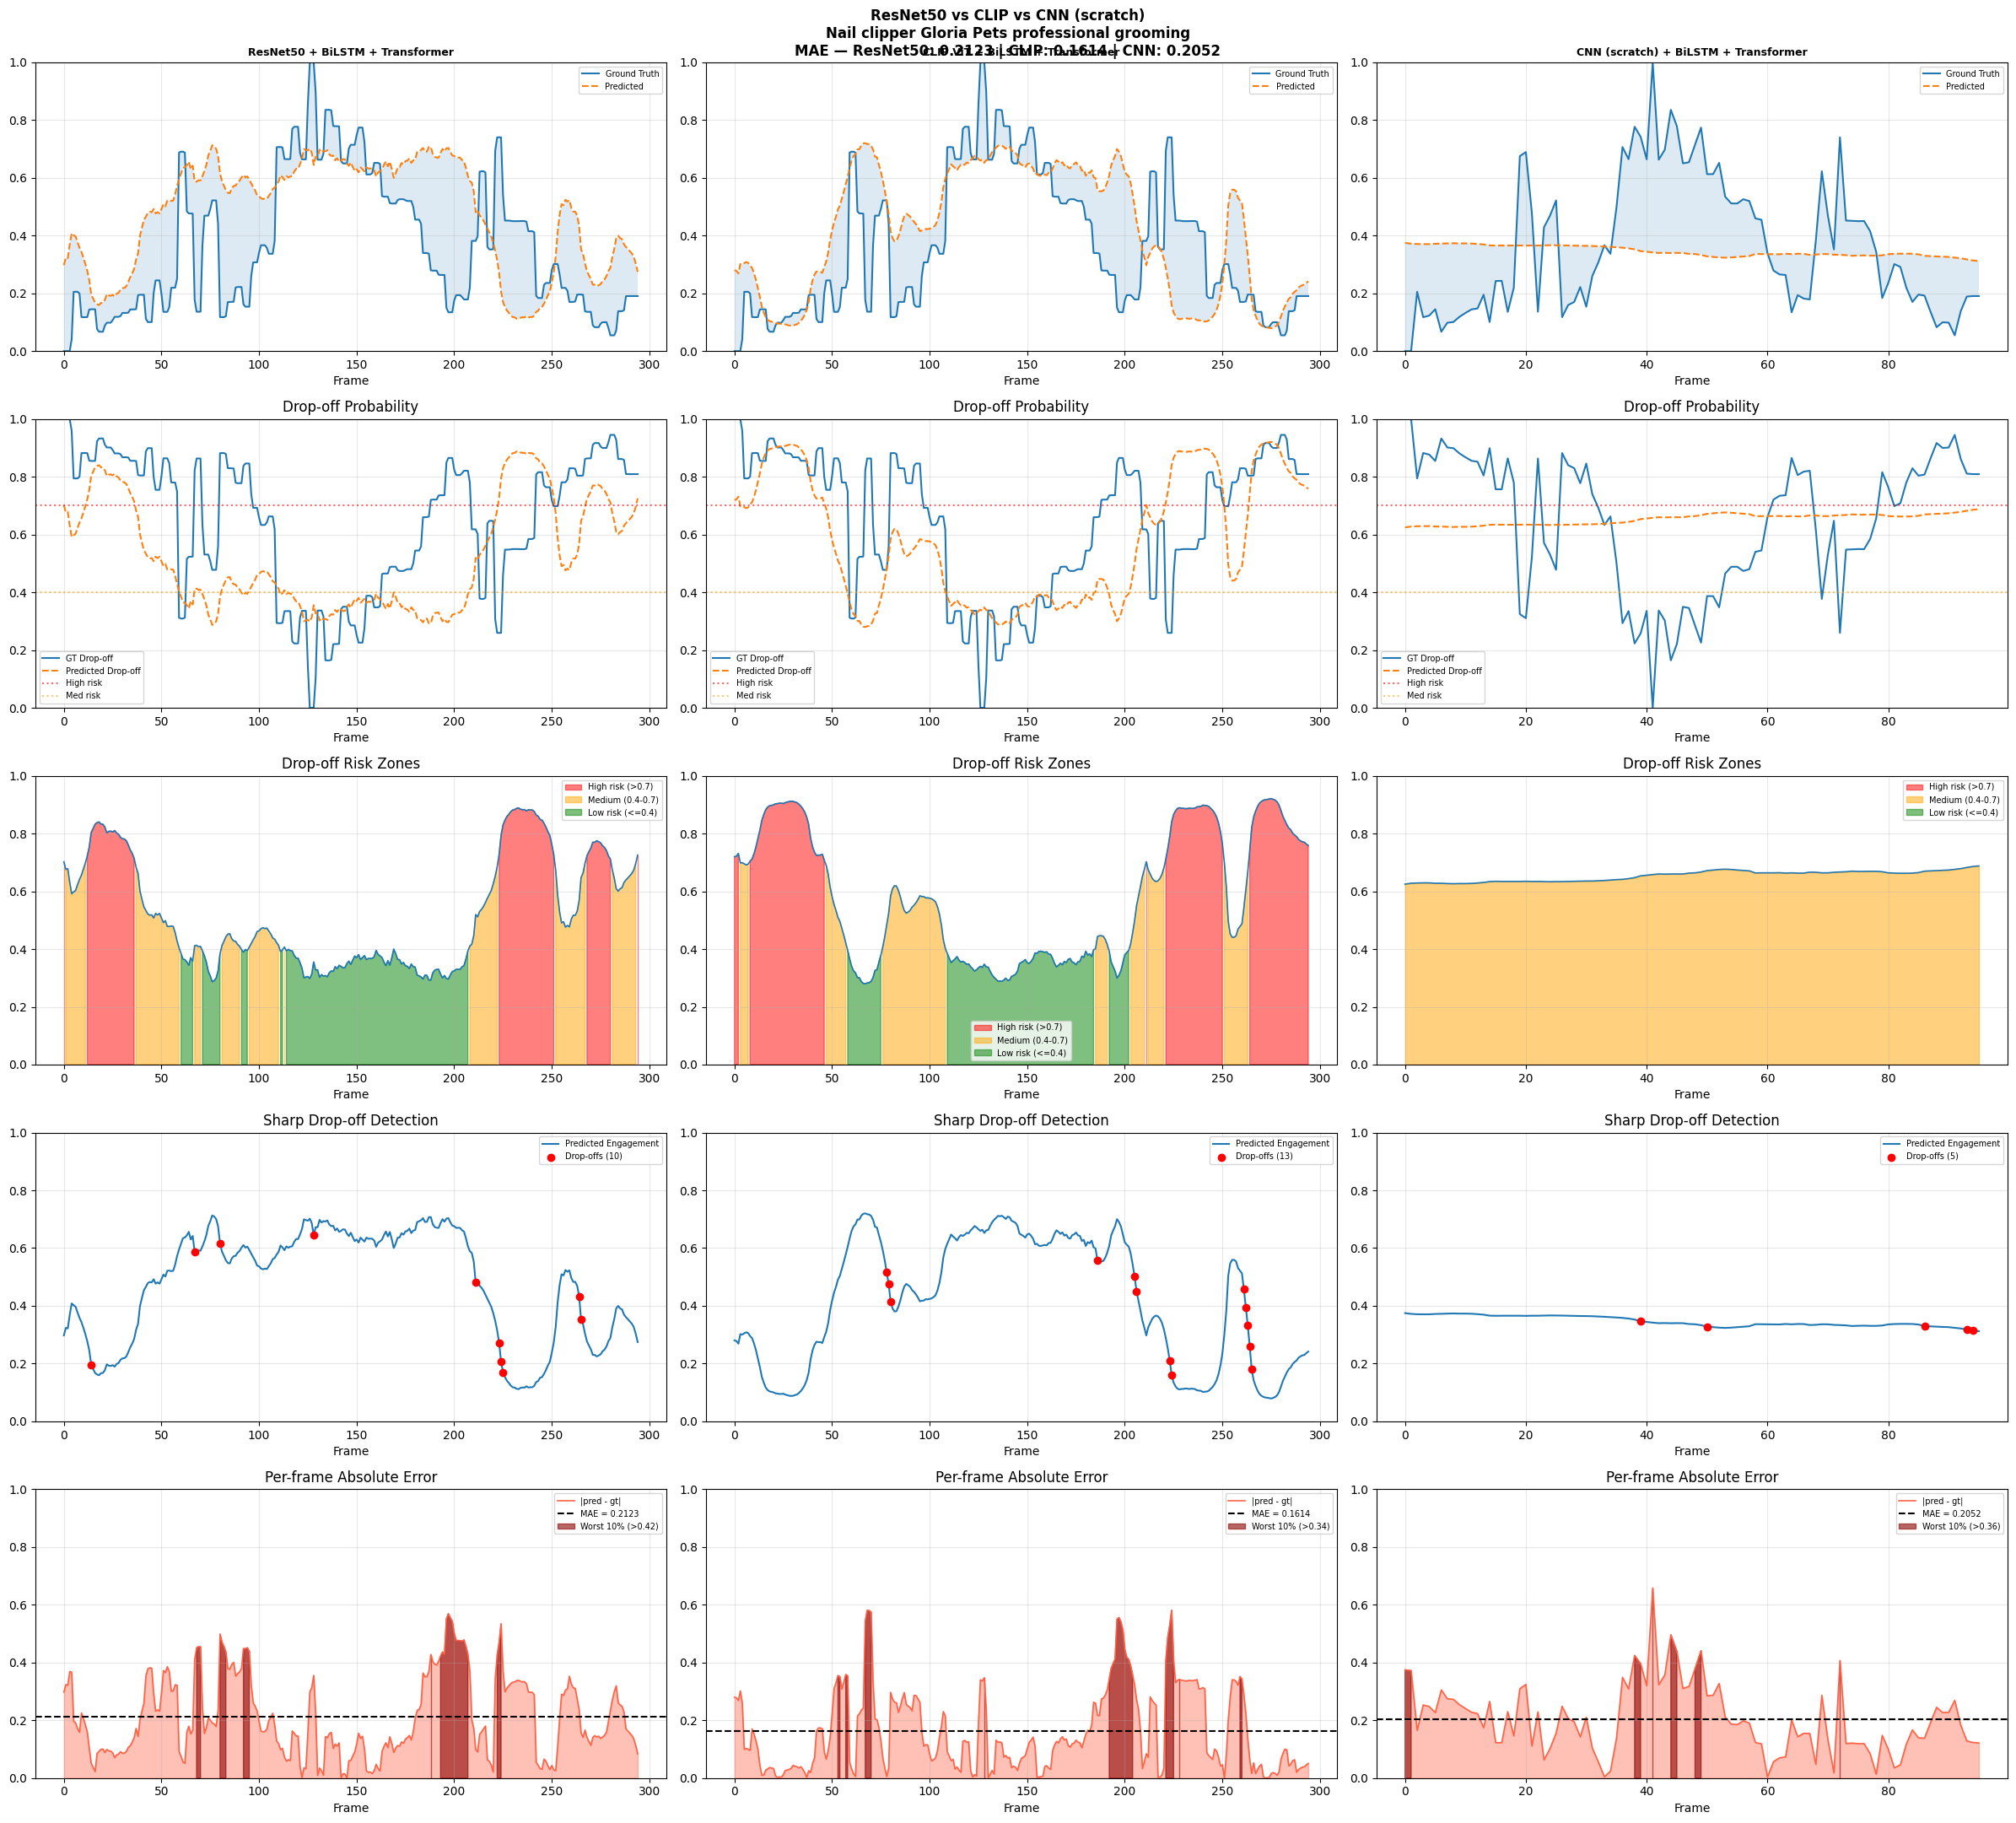

Saved: /content/VideoInsight_local/plots/0tmA_C6XwfM_three_branch_comparison.png

===== Per-Video MAE Summary =====
                                                                    title  mae_resnet  mae_clip  mae_cnn best_branch
video_id                                                                                                            
uGu_10sucQo                                          A Year of Beekeeping      0.1024    0.1343   0.1795  mae_resnet
GsAD1KT1xo8                                          Parkour Camp Leipzig      0.1819    0.1893   0.1830  mae_resnet
iVt07TCkFM0                                   Pure Fix TV: How to Wheelie      0.1989    0.1581   0.2493    mae_clip
Yi4Ij2NM7U4                      Poor Man's Meals: Spicy Sausage Sandwich      0.1418    0.1245   0.2208    mae_clip
NyBmCxDoHJU                                          The Dog Show HD 720p      0.1785    0.1509   0.2216    mae_clip
AwmHb44_ouw  #1306 How to change tires for off road vehicles [Dav

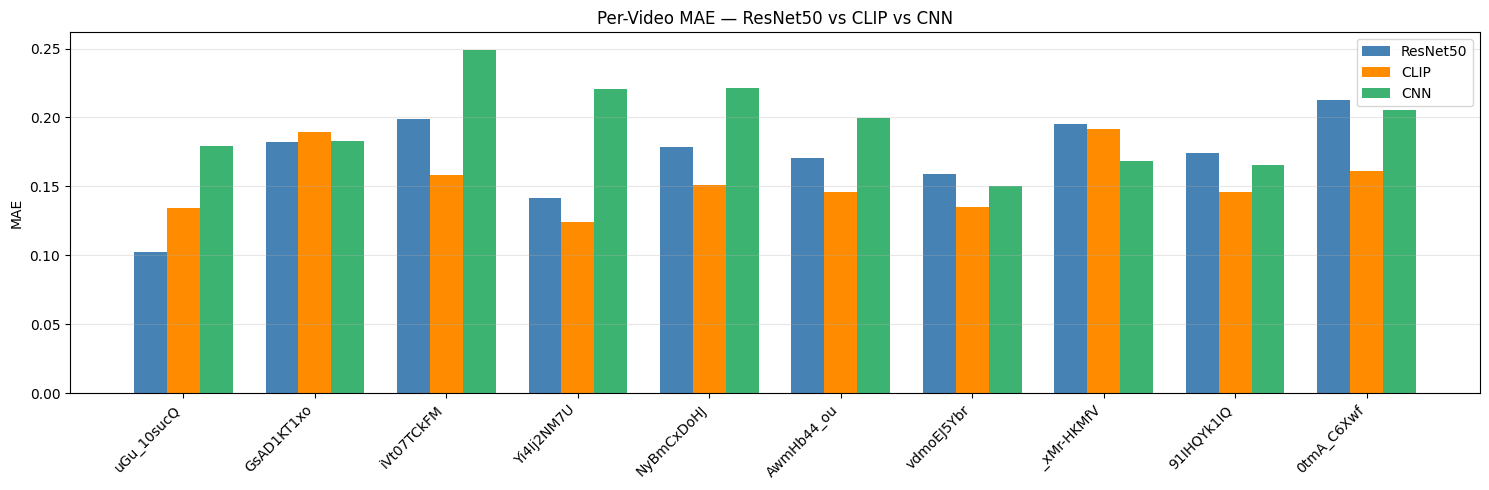

In [ ]:
def plot_side_by_side_three(video_id, info_df, save_dir):
    pred_r, labels_r = predict_for_video_features(best_model_r, video_id,
                        LOCAL_FEATURES_RESNET, MAX_SEQ_LEN_R, FEAT_DIM_R)
    pred_c, labels_c = predict_for_video_features(best_model_c, video_id,
                        LOCAL_FEATURES_CLIP, MAX_SEQ_LEN_C, FEAT_DIM_C)
    pred_n, labels_n = predict_for_video_frames(best_model_n, video_id, WINDOW_SIZE)

    if pred_r is None or pred_c is None or pred_n is None:
        print(f"Skipping {video_id} — features missing"); return None

    title_row = info_df[info_df['video_id'] == video_id]
    title     = title_row['title'].values[0][:60] if len(title_row) > 0 else video_id

    err_r = np.abs(pred_r - labels_r)
    err_c = np.abs(pred_c - labels_c)
    err_n = np.abs(pred_n - labels_n)

    mae_r = float(np.mean(err_r))
    mae_c = float(np.mean(err_c))
    mae_n = float(np.mean(err_n))

    print(f"\n{video_id} — {title}")
    print(f"  MAE  ResNet50 : {mae_r:.4f}  ({len(pred_r)} frames)")
    print(f"  MAE  CLIP     : {mae_c:.4f}  ({len(pred_c)} frames)")
    print(f"  MAE  CNN      : {mae_n:.4f}  ({len(pred_n)} frames)")

    fig, axes = plt.subplots(5, 3, figsize=(24, 22))
    fig.suptitle(
        f'ResNet50 vs CLIP vs CNN (scratch)\n{title}\n'
        f'MAE — ResNet50: {mae_r:.4f} | CLIP: {mae_c:.4f} | CNN: {mae_n:.4f}',
        fontsize=12, fontweight='bold'
    )

    branch_data = [
        ('ResNet50 + BiLSTM + Transformer',      pred_r, labels_r, err_r, mae_r),
        ('CLIP ViT + BiLSTM + Transformer',       pred_c, labels_c, err_c, mae_c),
        ('CNN (scratch) + BiLSTM + Transformer',  pred_n, labels_n, err_n, mae_n),
    ]

    for col, (branch_name, pred, labels, err, mae) in enumerate(branch_data):
        frames    = np.arange(len(pred))
        pred_drop = 1 - pred
        gt_drop   = 1 - labels
        drop_pts  = detect_dropoff_points(pred, sensitivity=1.5)
        # FIX 3: guard against out-of-bounds index when timestamps is shorter
        drop_pts  = [d for d in drop_pts if d < len(frames)]

        ax = axes[0][col]
        ax.plot(frames, labels, lw=1.5, label='Ground Truth')
        ax.plot(frames, pred,   lw=1.5, linestyle='--', label='Predicted')
        ax.fill_between(frames, labels, pred, alpha=0.15)
        ax.set_title(branch_name, fontweight='bold', fontsize=9)
        ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

        ax = axes[1][col]
        ax.plot(frames, gt_drop,   lw=1.5, label='GT Drop-off')
        ax.plot(frames, pred_drop, lw=1.5, linestyle='--', label='Predicted Drop-off')
        ax.axhline(0.7, color='red',    linestyle=':', alpha=0.6, label='High risk')
        ax.axhline(0.4, color='orange', linestyle=':', alpha=0.6, label='Med risk')
        ax.set_title('Drop-off Probability')
        ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

        ax = axes[2][col]
        ax.fill_between(frames, pred_drop, where=pred_drop>0.7,
                         alpha=0.5, color='red',    label='High risk (>0.7)')
        ax.fill_between(frames, pred_drop,
                         where=(pred_drop>0.4)&(pred_drop<=0.7),
                         alpha=0.5, color='orange', label='Medium (0.4-0.7)')
        ax.fill_between(frames, pred_drop, where=pred_drop<=0.4,
                         alpha=0.5, color='green',  label='Low risk (<=0.4)')
        ax.plot(frames, pred_drop, lw=1.2)
        ax.set_title('Drop-off Risk Zones')
        ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

        ax = axes[3][col]
        ax.plot(frames, pred, lw=1.5, label='Predicted Engagement')
        if drop_pts:
            ax.scatter(drop_pts, pred[drop_pts], color='red', zorder=5,
                        label=f'Drop-offs ({len(drop_pts)})')
        ax.set_title('Sharp Drop-off Detection')
        ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

        ax = axes[4][col]
        ax.fill_between(frames, err, alpha=0.4, color='tomato')
        ax.plot(frames, err, lw=1.2, color='tomato', label='|pred - gt|')
        ax.axhline(mae, color='black', linestyle='--', lw=1.5, label=f'MAE = {mae:.4f}')
        threshold = np.percentile(err, 90)
        ax.fill_between(frames, err, where=err>=threshold,
                         alpha=0.6, color='darkred', label=f'Worst 10% (>{threshold:.2f})')
        ax.set_title('Per-frame Absolute Error')
        ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    for ax in axes.flat:
        ax.set_xlabel('Frame')

    plt.tight_layout()
    save_path = os.path.join(save_dir, f'{video_id}_three_branch_comparison.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    return {'video_id': video_id, 'title': title,
            'mae_resnet': mae_r, 'mae_clip': mae_c, 'mae_cnn': mae_n}


common_val = list(set(val_ids_r) & set(val_ids_c) & set(val_ids_n))
print(f"Side-by-side comparison for {len(common_val)} videos\n")

all_results = []
for vid in common_val:
    result = plot_side_by_side_three(vid, info_df, PLOTS_DIR)
    if result:
        all_results.append(result)

if all_results:
    summary_df = pd.DataFrame(all_results).set_index('video_id')
    summary_df['best_branch'] = summary_df[['mae_resnet','mae_clip','mae_cnn']].idxmin(axis=1)
    summary_df.loc['MEAN'] = summary_df[['mae_resnet','mae_clip','mae_cnn']].mean()
    print("\n===== Per-Video MAE Summary =====")
    print(summary_df.round(4).to_string())

    fig, ax = plt.subplots(figsize=(max(8, len(all_results)*1.5), 5))
    x     = np.arange(len(all_results))
    width = 0.25
    ids   = [r['video_id'][:10] for r in all_results]

    ax.bar(x - width, [r['mae_resnet'] for r in all_results], width, label='ResNet50', color='steelblue')
    ax.bar(x,         [r['mae_clip']   for r in all_results], width, label='CLIP',     color='darkorange')
    ax.bar(x + width, [r['mae_cnn']    for r in all_results], width, label='CNN',      color='mediumseagreen')

    ax.set_xticks(x); ax.set_xticklabels(ids, rotation=45, ha='right')
    ax.set_ylabel('MAE'); ax.set_title('Per-Video MAE — ResNet50 vs CLIP vs CNN')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'per_video_mae_summary.png'), dpi=150)
    plt.show()

## Step 15: Inference on New Videos — All Three Branches

Running inference on: How to Clean Your Dog's Ears - Vetoquinol USA

Frames sampled: 289 at 2 FPS


ResNet: 100%|██████████| 289/289 [00:00<00:00, 2032.15it/s]


Frames sampled: 289 at 2 FPS


CLIP: 100%|██████████| 289/289 [00:03<00:00, 95.99it/s] 


Frames sampled: 289 at 2 FPS


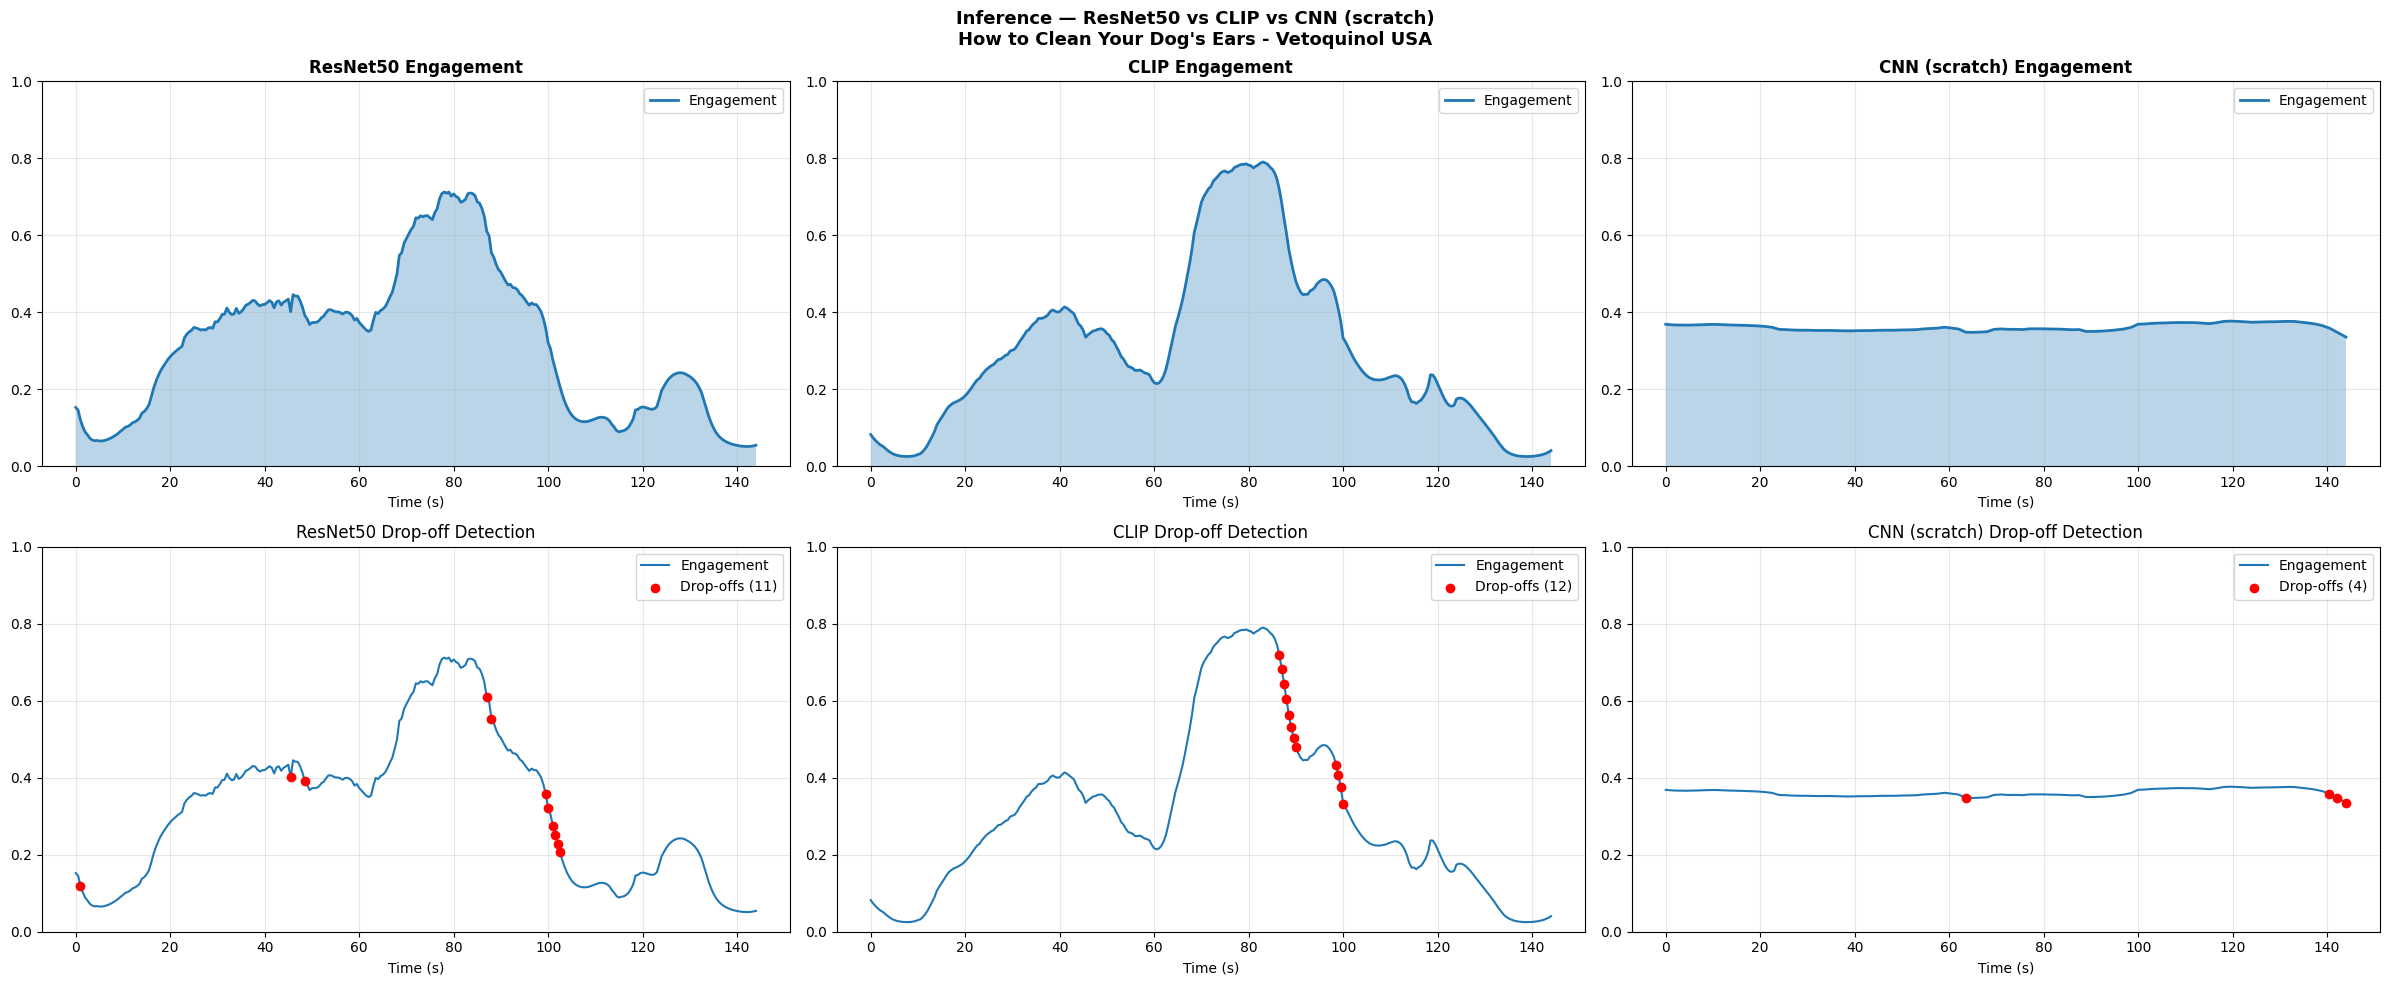

Inference complete!


In [ ]:
def predict_new_video(video_path, model, feature_extractor, fps_target=2,
                      feat_dim=None, max_seq_len=None):

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open: {video_path}")

    video_fps      = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = max(1, int(video_fps / fps_target))

    frames_list, timestamps = [], []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        if frame_idx % frame_interval == 0:
            if feature_extractor == 'cnn':
                frames_list.append(cv2.resize(frame, (64, 64)))  # 64x64 for CNN branch
            else:
                frames_list.append(cv2.resize(frame, (224, 224)))
            timestamps.append(frame_idx / video_fps)
        frame_idx += 1

    cap.release()
    print(f"Frames sampled: {len(frames_list)} at {fps_target} FPS")

    if feature_extractor == 'resnet':
        batch = np.stack([preprocess_resnet(f) for f in tqdm(frames_list, desc='ResNet')])
        raw_feats = base_resnet.predict(batch, verbose=0)
        diff_feats = np.zeros_like(raw_feats)
        diff_feats[1:] = raw_feats[1:] - raw_feats[:-1]
        features = np.concatenate([raw_feats, diff_feats], axis=1).astype(np.float32)

    elif feature_extractor == 'clip':
        raw_feats = []
        for f in tqdm(frames_list, desc='CLIP'):
            img = Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
            inp = clip_preprocess(img).unsqueeze(0).to(torch_device)
            with torch.no_grad():
                raw_feats.append(clip_model.encode_image(inp).cpu().numpy().squeeze(0))
        raw_feats = np.array(raw_feats, dtype=np.float32)
        diff_feats = np.zeros_like(raw_feats)
        diff_feats[1:] = raw_feats[1:] - raw_feats[:-1]
        features = np.concatenate([raw_feats, diff_feats], axis=1).astype(np.float32)

    else:  # CNN
        features = np.stack([
            cv2.cvtColor(f, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            for f in frames_list
        ])  # (T, 64, 64, 3)

    T = len(features)
    timestamps = np.array(timestamps)

    if feature_extractor == 'cnn':
        if T >= max_seq_len:
            idx = np.linspace(0, T - 1, max_seq_len, dtype=int)
            features   = features[idx]
            timestamps = timestamps[idx]
        else:
            pad = max_seq_len - T
            features = np.concatenate([
                features, np.zeros((pad, 64, 64, 3), np.float32)
            ], axis=0)
    else:
        if T >= max_seq_len:
            features   = features[:max_seq_len]
            timestamps = timestamps[:max_seq_len]
        else:
            pad = max_seq_len - T
            features = np.vstack([features, np.zeros((pad, feat_dim), np.float32)])
            timestamps = timestamps[:T]

    engagement = model(
        tf.expand_dims(features, 0), training=False
    ).numpy().squeeze(0)

    valid_len  = min(len(engagement), len(timestamps))
    engagement = engagement[:valid_len]
    timestamps = timestamps[:valid_len]

    drop_pts = detect_dropoff_points(engagement, sensitivity=1.5)
    # FIX 3: guard against out-of-bounds when indexing timestamps with drop_pts
    drop_pts = [d for d in drop_pts if d < valid_len]

    return {
        'timestamps': timestamps,
        'engagement': engagement,
        'dropoff': 1 - engagement,
        'drop_points': drop_pts
    }

def plot_inference_three(result_r, result_c, result_n, video_title, save_dir):
    fig, axes = plt.subplots(2, 3, figsize=(24, 10))
    fig.suptitle(f'Inference — ResNet50 vs CLIP vs CNN (scratch)\n{video_title}',
                  fontsize=13, fontweight='bold')

    for col, (result, branch) in enumerate([
        (result_r, 'ResNet50'),
        (result_c, 'CLIP'),
        (result_n, 'CNN (scratch)'),
    ]):
        ts, eng = result['timestamps'], result['engagement']
        drops   = result['drop_points']  # already bounds-checked in predict_new_video

        ax = axes[0][col]
        ax.plot(ts, eng, lw=2, label='Engagement')
        ax.fill_between(ts, eng, alpha=0.3)
        ax.set_title(f'{branch} Engagement', fontweight='bold')
        ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[1][col]
        ax.plot(ts, eng, lw=1.5, label='Engagement')
        if drops:
            ax.scatter(ts[drops], eng[drops], color='red', zorder=5,
                        label=f'Drop-offs ({len(drops)})')
        ax.set_title(f'{branch} Drop-off Detection')
        ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)

    for ax in axes.flat:
        ax.set_xlabel('Time (s)')

    plt.tight_layout()
    plt.savefig(os.path.join(INFERENCE_DIR, f'inference_three_{video_title[:30]}.png'), dpi=150)
    plt.show()

# Run inference on last video
test_video_id   = video_ids[-1]
test_video_path = os.path.join(VIDEO_PATH, f"{test_video_id}.mp4")

title_row  = info_df[info_df['video_id'] == test_video_id]
test_title = title_row['title'].values[0] if len(title_row) > 0 else test_video_id

print(f"Running inference on: {test_title}\n")

result_r = predict_new_video(test_video_path, best_model_r, 'resnet',
    feat_dim=FEAT_DIM_R, max_seq_len=MAX_SEQ_LEN_R)
result_c = predict_new_video(test_video_path, best_model_c, 'clip',
    feat_dim=FEAT_DIM_C, max_seq_len=MAX_SEQ_LEN_C)
result_n = predict_new_video(test_video_path, best_model_n, 'cnn',
    max_seq_len=WINDOW_SIZE)

plot_inference_three(result_r, result_c, result_n, test_title, INFERENCE_DIR)
print("Inference complete!")

## Step 16: Save Results Back to Drive

Run before disconnecting. Copies trained models, plots, and inference results
from local SSD back to Drive so nothing is lost when the runtime resets.

In [ ]:
import shutil

print("=" * 60)
print("Saving results from local SSD → Drive")
print("=" * 60)

# Save models
DRIVE_MODELS_DIR = os.path.join(DRIVE_PATH, 'models')
os.makedirs(DRIVE_MODELS_DIR, exist_ok=True)
print("\nModels:")
for fname in ['resnet_best.keras', 'clip_best.keras',
              'cnn_e2e_best.keras', 'training_histories.json']:
    src = os.path.join(LOCAL_MODELS_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(DRIVE_MODELS_DIR, fname))
        print(f"  Saved: {fname}")
    else:
        print(f"  Not found (skipped): {fname}")

# Save plots
DRIVE_PLOTS_DIR = os.path.join(DRIVE_PATH, 'plots')
os.makedirs(DRIVE_PLOTS_DIR, exist_ok=True)
print("\nPlots:")
for fname in os.listdir(PLOTS_DIR):
    src = os.path.join(PLOTS_DIR, fname)
    shutil.copy2(src, os.path.join(DRIVE_PLOTS_DIR, fname))
    print(f"  Saved: {fname}")

# Save inference results
DRIVE_INFERENCE_DIR = os.path.join(DRIVE_PATH, 'inference_results')
os.makedirs(DRIVE_INFERENCE_DIR, exist_ok=True)
print("\nInference results:")
for fname in os.listdir(INFERENCE_DIR):
    src = os.path.join(INFERENCE_DIR, fname)
    shutil.copy2(src, os.path.join(DRIVE_INFERENCE_DIR, fname))
    print(f"  Saved: {fname}")

print("\n" + "=" * 60)
print("All results saved to Drive. Safe to disconnect.")
print("=" * 60)

Saving results from local SSD → Drive

Models:
  Saved: resnet_best.keras
  Saved: clip_best.keras
  Saved: cnn_e2e_best.keras
  Saved: training_histories.json

Plots:
  Saved: training_curves_all_three.png
  Saved: uGu_10sucQo_three_branch_comparison.png
  Saved: 0tmA_C6XwfM_three_branch_comparison.png
  Saved: iVt07TCkFM0_three_branch_comparison.png
  Saved: per_video_mae_summary.png
  Saved: vdmoEJ5YbrQ_three_branch_comparison.png
  Saved: _xMr-HKMfVA_three_branch_comparison.png
  Saved: Yi4Ij2NM7U4_three_branch_comparison.png
  Saved: label_smoothing_comparison.png
  Saved: 91IHQYk1IQM_three_branch_comparison.png
  Saved: GsAD1KT1xo8_three_branch_comparison.png
  Saved: NyBmCxDoHJU_three_branch_comparison.png
  Saved: AwmHb44_ouw_three_branch_comparison.png
  Saved: metric_comparison_all_three.png

Inference results:
  Saved: inference_three_How to Clean Your Dog's Ears -.png

All results saved to Drive. Safe to disconnect.
